# Instructions

To run any cell, make sure to run the globals cells first. You must import the pip package from github at least once and runthe globals cell before any other cells.

Exploratory Data Analysis, Data Preparation, and Data Cleaning Pipeline import the csv data, exlore the feature, and run through initial cleaning and the process of feature engineering.

The **Modeling Runs** section contains the model testing pipeline for 8 different models. More details about the process are in that section.

Many of these sections take a long time to run. They all run a 5-fold CV and running 150 fits on a hyperparameter search takes a long time. The cells have all been run at least once and the runtime for each is printed with its output. Some cells take over 30 minutes.

# Globals

In [ ]:
# # import project code from github
# !pip uninstall -y shared_util
# %pip -q install 'git+https://github.com/meaton96/Eaton_633_Project.git'

Found existing installation: shared_util 0.1.0
Uninstalling shared_util-0.1.0:
  Successfully uninstalled shared_util-0.1.0
Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: "'git+https://github.com/meaton96/Eaton_633_Project.git'"

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [50]:
# Globals
import numpy as np
import pandas as pd
from shared_util.pipelines import ModelPipeline
import warnings
warnings.filterwarnings('ignore')

METRICS_DB_ID = 19
METRICS_NOTES = "Remove dummy ref drop"
PCA = False
scaler = 'standard' # 'standard' for StandardScaler or 'power' for PowerTransformer (yeo-johnson)

R = 16_300 # Average cost of readmission (Jiang and Hensche, 2023)
e = 0.33 # estimated program effectiveness - estimate 33% for target cohort, studies show >50%, unknown readmission cause, no study on target cohort, so lowered
m_cost_list = [150, 220, 330, 440, 660, 1000] # program costs 30-60 days, $150-$220 per patient per month
COST_PREF = 330 # 1 month monitoring cost


UPDATE_DATABASE = True # keep false in collab, will crash, this controls if the runs try to log to the database, which will not work witout the db uri
GET_BASELINE = False    # controls if a baseline smote vs undersample is done for this run
SHOW_FEAT_IMPORTANCE = False # controls if feature importance is shown for this run
USE_PRE_COMPUTED_HYPERPARAMS = True # controls if hyperparam sweep is run or to use hyperparams from previous runs

LOG_TRANSFORM_COLS = np.array(
    ['num_medications', 'num_procedures', 'time_in_hospital', 'number_inpatient'
     ])

# Exploratory Data Analysis

In [4]:
import pandas as pd
from shared_util.dataio import load_csv

df = load_csv('diabetic_data')

df = df.reset_index().rename(columns={'index': 'encounter_id'})


display(df.head())

X = df.drop(columns=['readmitted'])
y = df['readmitted']

y = pd.DataFrame(y)
y.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


,readmitted
0,NO
1,>30
2,NO
3,NO
4,NO


### Discharge Disposition

Certain row-level exclusions must be applied before splitting the data, because they define the population on which the model would realistically be used. Several discharge disposition codes (e.g., inpatient transfers, hospice care, expired patients) represent encounters that would never be eligible for 30-day readmission intervention. Including them in validation or test sets would result in evaluating model performance on cases that are out-of-scope for the prediction task and would not appear in future deployment.

These exclusions are cohort-definition steps, not statistical preprocessing, and therefore do not introduce information leakage.

In [5]:
# Examine the discharge disposition data
# From accompanying mapping documentation:
discharge_disposition_map = {
    1: "Discharged to home",
    2: "Discharged/transferred to another short term hospital",
    3: "Discharged/transferred to SNF",
    4: "Discharged/transferred to ICF",
    5: "Discharged/transferred to another type of inpatient care institution",
    6: "Discharged/transferred to home with home health service",
    7: "Left AMA",
    8: "Discharged/transferred to home under care of Home IV provider",
    9: "Admitted as an inpatient to this hospital",
    10: "Neonate discharged to another hospital for neonatal aftercare",
    11: "Expired",
    12: "Still patient or expected to return for outpatient services",
    13: "Hospice / home",
    14: "Hospice / medical facility",
    15: "Discharged/transferred within this institution to Medicare approved swing bed",
    16: "Discharged/transferred/referred another institution for outpatient services",
    17: "Discharged/transferred/referred to this institution for outpatient services",
    18: "NULL",
    19: "Expired at home. Medicaid only, hospice.",
    20: "Expired in a medical facility. Medicaid only, hospice.",
    21: "Expired, place unknown. Medicaid only, hospice.",
    22: "Discharged/transferred to another rehab fac including rehab units of a hospital.",
    23: "Discharged/transferred to a long term care hospital.",
    24: "Discharged/transferred to a nursing facility certified under Medicaid but not certified under Medicare.",
    25: "Not Mapped",
    26: "Unknown/Invalid",
    27: "Discharged/transferred to a federal health care facility.",
    28: "Discharged/transferred/referred to a psychiatric hospital or psychiatric distinct part unit of a hospital",
    29: "Discharged/transferred to a Critical Access Hospital (CAH).",
    30: "Discharged/transferred to another Type of Health Care Institution not Defined Elsewhere"
}

X_discharge = X['discharge_disposition_id'].map(discharge_disposition_map)

X_discharge.value_counts()

discharge_disposition_id
Discharged to home                                                                                           60234
Discharged/transferred to SNF                                                                                13954
Discharged/transferred to home with home health service                                                      12902
NULL                                                                                                          3691
Discharged/transferred to another short term hospital                                                         2128
Discharged/transferred to another rehab fac including rehab units of a hospital.                              1993
Expired                                                                                                       1642
Discharged/transferred to another type of inpatient care institution                                          1184
Not Mapped                                             

Several of these values are problematic.

Some rows note that patients have expired. This would not be known at time of discharge and needs to be removed from our dataset.

Additionaly, there are a large amount of rows that show patients were transfered to another inpatient facility. These patients are not discharged and are therefore not part of our target cohort.

### Statistical EDA

In [6]:
# split off training data, training is 70%, validation 15%, test 15% but we just look at training data
# full stratified-group split code
import math
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

def group_split(
    df: pd.DataFrame,
    *,
    target_col: str = "target",
    group_col: str = "patient_nbr",
    train_size: float = 0.70,
    val_size: float = 0.15,
    test_size: float = 0.15,
    random_state: int = 42,
    balance_tolerance: float = 0.01,
    max_tries: int = 50,
):
    """
    Group-aware split (no patient leakage) into train/val/test.
    Uses two GroupShuffleSplits: (train vs rest), then (val vs test) on the rest.
    Attempts to keep class prevalence close to overall within 'balance_tolerance'.
    """
    rng = np.random.RandomState(random_state)
    overall_rate = df[target_col].mean()

    def _ok_rate(d: pd.DataFrame) -> bool:
        if d.empty:
            return False
        return abs(d[target_col].mean() - overall_rate) <= balance_tolerance

    # 1) Train vs rest
    tries = 0
    while True:
        gss = GroupShuffleSplit(n_splits=1, train_size=train_size, random_state=rng.randint(0, 10**9))
        tr_idx, rest_idx = next(gss.split(df, df[target_col], groups=df[group_col]))
        train_df = df.iloc[tr_idx].copy()
        rest_df  = df.iloc[rest_idx].copy()
        if _ok_rate(train_df) and _ok_rate(rest_df):
            break
        tries += 1
        if tries >= max_tries:
            break

    # 2) Val vs Test on the remaining groups
    rel_val = val_size / (val_size + test_size)
    tries = 0
    while True:
        gss2 = GroupShuffleSplit(n_splits=1, train_size=rel_val, random_state=rng.randint(0, 10**9))
        val_idx_rel, test_idx_rel = next(gss2.split(rest_df, rest_df[target_col], groups=rest_df[group_col]))
        val_df  = rest_df.iloc[val_idx_rel].copy()
        test_df = rest_df.iloc[test_idx_rel].copy()
        if _ok_rate(val_df) and _ok_rate(test_df):
            break
        tries += 1
        if tries >= max_tries:
            break

    # leak test: no patient overlap
    tr_pat, va_pat, te_pat = set(train_df[group_col]), set(val_df[group_col]), set(test_df[group_col])
    assert tr_pat.isdisjoint(va_pat) and tr_pat.isdisjoint(te_pat) and va_pat.isdisjoint(te_pat), \
        "Patient overlap detected across splits."

    # return X/y splits
    def _xy(d: pd.DataFrame):
        X = d.drop(columns=[target_col])
        y = d[target_col].copy()
        return X, y

    X_train, y_train = _xy(train_df)
    X_val,   y_val   = _xy(val_df)
    X_test,  y_test  = _xy(test_df)

    return X_train, X_val, X_test, y_train, y_val, y_test

In [7]:
# the group split function expects a somewhat cleaned up data set, at least with the target variable setup (binary stratification)

df['target'] = (df['readmitted'] == '<30').astype(int)


X_train, X_validate, X_test, y_train, y_validate, y_test = group_split(df)

In [8]:
# statistical summary of continuous columns

cont_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

num_df = X_train[cont_cols].dropna()

num_df.describe()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,71242.000000,71242.000000,71242.000000,71242.000000,71242.000000,71242.000000,71242.000000,71242.000000
mean,4.388661,43.047991,1.341414,16.005446,0.362567,0.196724,0.640675,7.416875
std,2.977042,19.681216,1.708255,8.121455,1.239948,0.852492,1.271679,1.936508
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,14.000000,132.000000,6.000000,81.000000,40.000000,37.000000,19.000000,16.000000


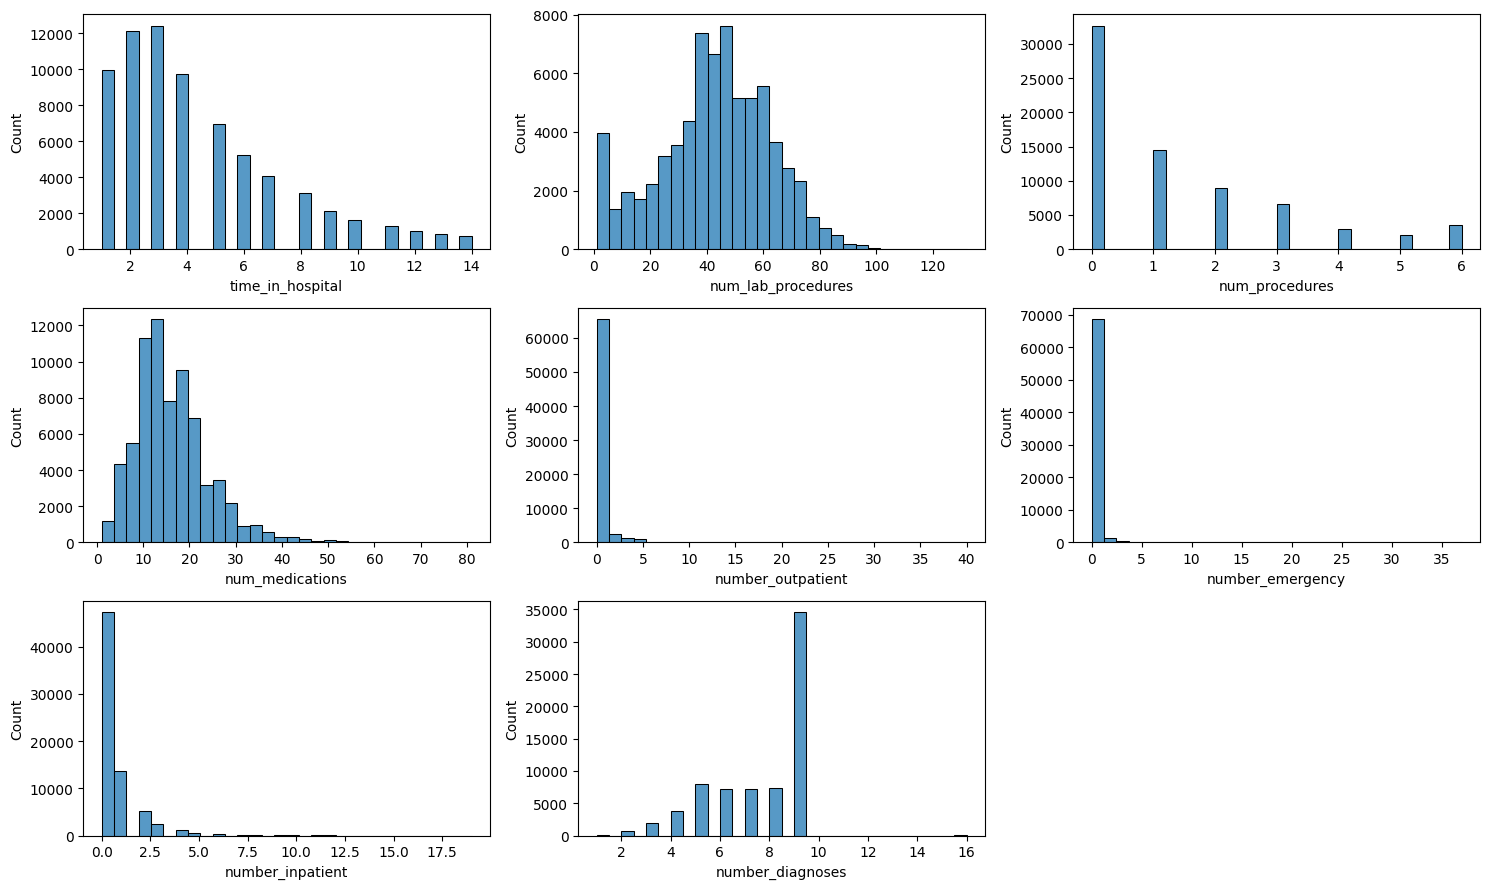

In [9]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

def cont_hist_plots(num_feats_df):
    cols = num_feats_df.columns.tolist()
    n = len(cols)
    ncols = 3
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 3))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]
        data = num_feats_df[col].dropna()
        bins = 30
        sns.histplot(data, bins=bins, kde=False, ax=ax, color="C0", stat="count") # type: ignore

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

cont_hist_plots(num_df)

Many right very right-skewed features

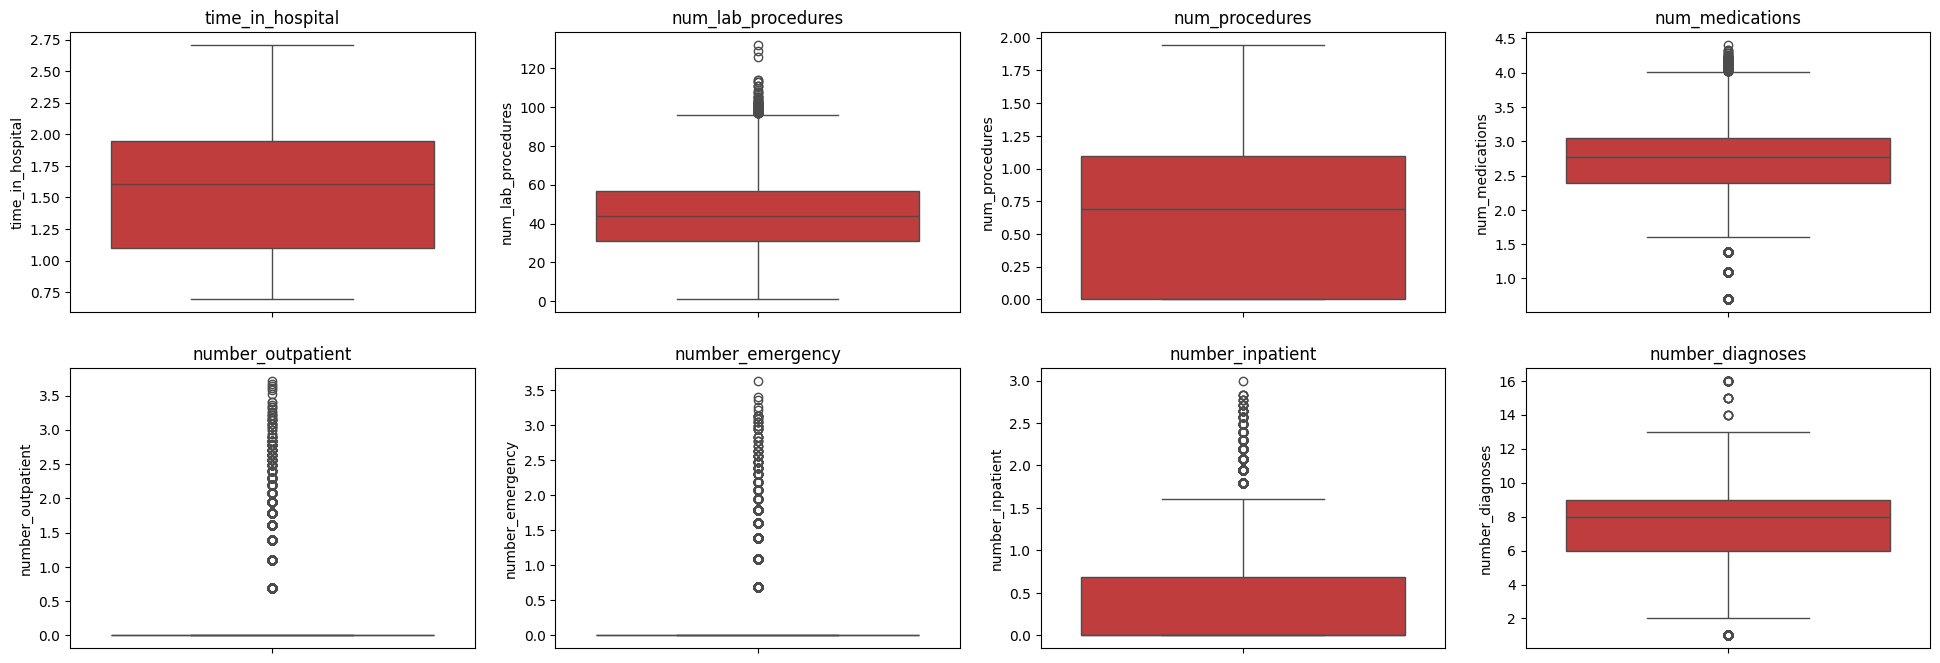

In [10]:
# box plots, looking for outliers

num_df_log = num_df.copy()

# linear models will transform these columns in pre processing pipeline
cont_cols = np.array(
    ['number_outpatient', 'number_inpatient', 'number_emergency',
     'num_medications', 'num_procedures', 'time_in_hospital'
     ])



num_df_log[cont_cols] = np.log1p(num_df_log[cont_cols].dropna())

cols = num_df_log.columns.to_list()


fig, axes = plt.subplots(2,4, figsize=(len(cols)*3, 8))
axes = axes.flatten()
if len(cols) == 1:
    axes = [axes]
for ax, col in zip(axes, cols):
    sns.boxplot(y=num_df_log[col], ax=ax, color='C3')
    ax.set_title(col)
    ax.set_xlabel('')

plt.show()

In [11]:
# transform cols
#df['readmitted'] = (df['readmitted'] == '<30').astype(int)
df[cont_cols] = np.log1p(df[cont_cols])
df_train = pd.concat([X_train, y_train], axis=1)

Examine continous feature variance between classes.

Some features show a large amount of outliers, a vast majority of 0s and are very skewed.

Checking if this distribution is varied between classes.

ex. Do none of the readmitted patients have 0 outpatient procedures?

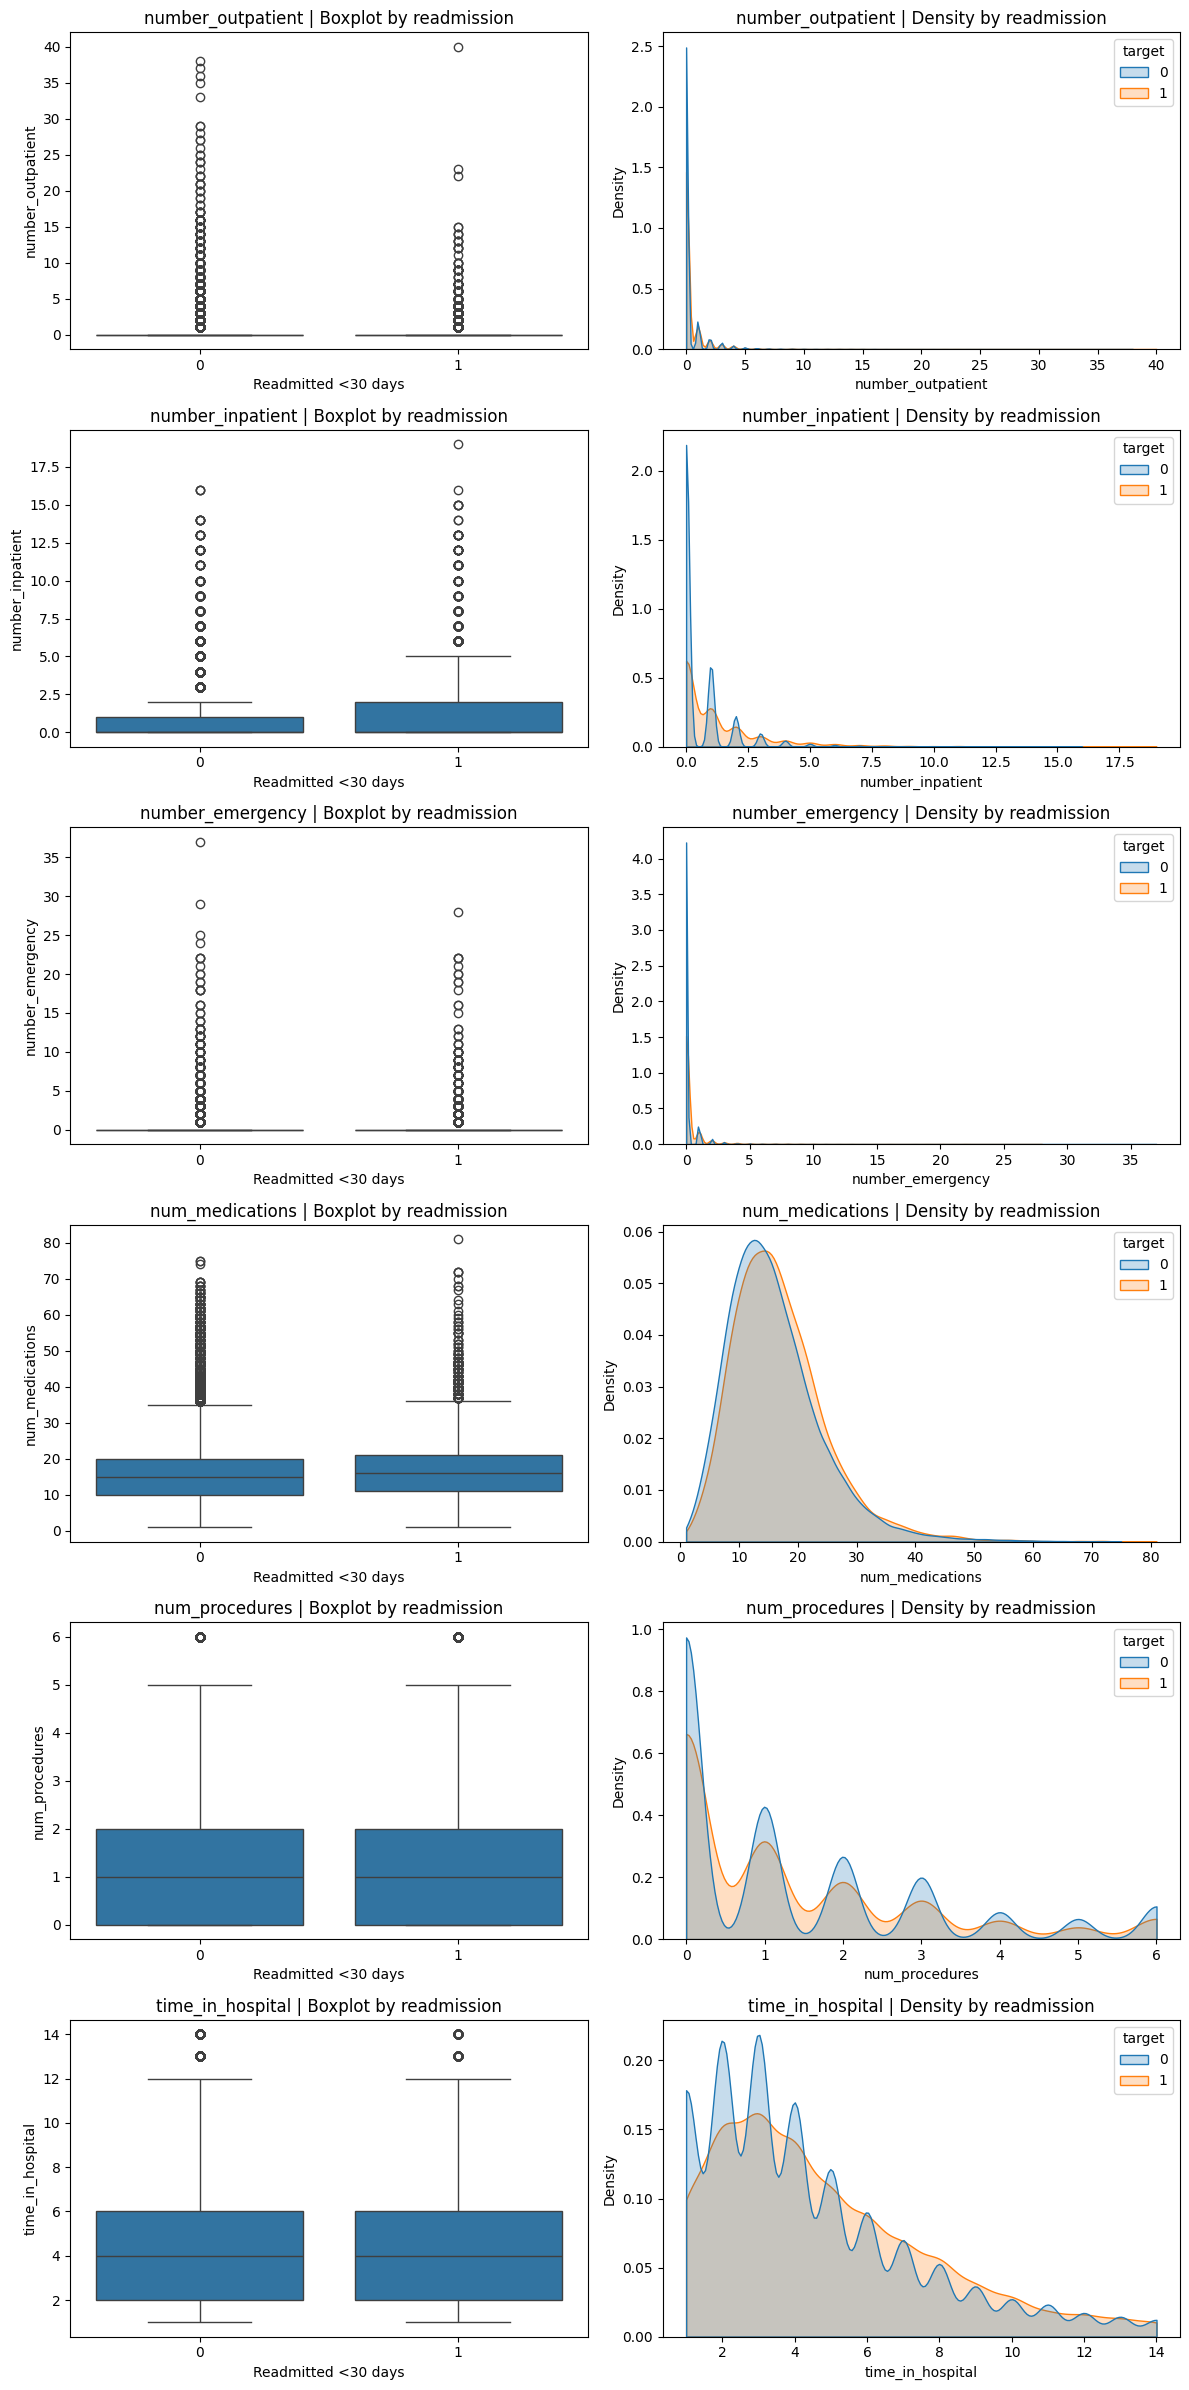

In [12]:
fig, axes = plt.subplots(len(cont_cols), 2, figsize=(12, 4 * len(cont_cols)))
for i, col in enumerate(cont_cols):
    sns.boxplot(
        data=df_train,
        x="target",
        y=col,
        ax=axes[i, 0],
        showfliers=True
    )
    axes[i, 0].set_title(f"{col} | Boxplot by readmission")
    axes[i, 0].set_xlabel("Readmitted <30 days")
    axes[i, 0].set_ylabel(col)

    sns.kdeplot(
        data=df_train,
        x=col,
        hue="target",
        common_norm=False,
        fill=True,
        ax=axes[i, 1],
        cut=0,
    )
    axes[i, 1].set_title(f"{col} | Density by readmission")
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_ylabel("Density")

plt.tight_layout()
plt.show()

The only feature that may show some variance difference between classes is num_inpatient which makes sense given its powerful predicitive value.

The density plot in particular shows a much larger grouping around 0 for number_inpatient for the negative class.

The boxplots show that the non-readmitted class has a decently lower upper quartile compared with the readmitted patients

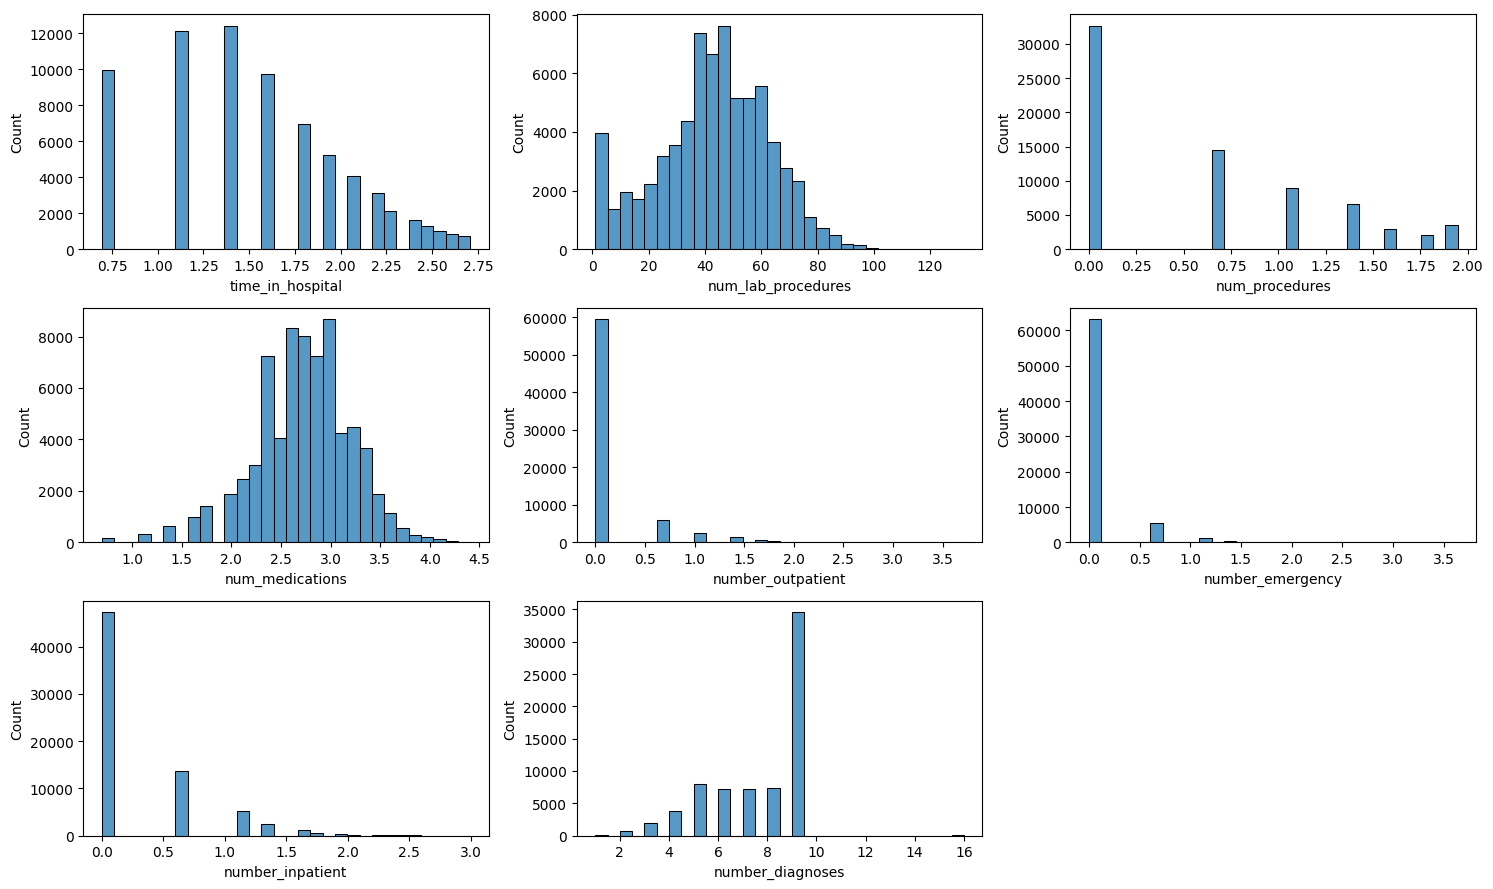

In [13]:
# check hist plots again after transform
cont_hist_plots(num_df_log)

some columns show improvement in psuedonormalization after log transform

time_in_hospotal, num_lab_procedures, num_medications all seem approximately bell shaped

Other columns still show poor statistical distribution and may need further transformation

### Pip Data

In [14]:
from ucimlrepo import fetch_ucirepo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# fetch dataset
diabetes_130_us_hospitals_for_years_1999_2008 = fetch_ucirepo(id=296)

# data (as pandas dataframes)
X_pip: pd.DataFrame = diabetes_130_us_hospitals_for_years_1999_2008.data.features  # type: ignore
y_pip :pd.DataFrame = diabetes_130_us_hospitals_for_years_1999_2008.data.targets.copy()  # type: ignore

In [16]:
_df = X_train.copy()

In [17]:
print(f'csv: feature num={len(_df.columns)}')
print(f'python import: feature num={len(X_pip.columns)}')

csv: feature num=50
python import: feature num=47


data imported from the pip package is missing patient_nbr and encounter_id
<hr>

### Examine feature names

In [18]:
_df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

### Repeat Patients

In [19]:
_df['patient_nbr'].value_counts()

patient_nbr
88785891     40
88227540     23
1660293      23
23199021     23
84428613     22
             ..
184875899     1
183087545     1
188574944     1
140199494     1
86383710      1
Name: count, Length: 50062, dtype: int64

Multiple repeated patient encounters, one patient number shows up 40 times
<hr>

### Examine class balance

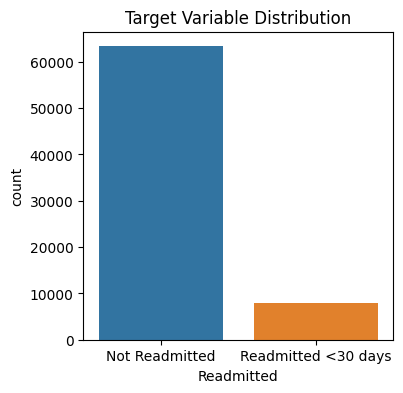

Percent Readmitted In under 30 days (Training Set): 11.11%


In [20]:
# target distribution

plt.figure(figsize=(4,4))

label_map = {0: 'Not Readmitted', 1: 'Readmitted <30 days'}


y_plt = y_train.map(label_map)


sns.countplot(x=y_plt, hue=y_plt)


plt.title('Target Variable Distribution')
plt.xlabel('Readmitted')
plt.ylabel('count')

plt.show()
print(f'Percent Readmitted In under 30 days (Training Set): {y_train.mean()*100:.2f}%')

The target class is extremely imbalanced. This will be addressed later on with an over or under sampling technique.

<HR>

### Missing Data

In [21]:
# to address nans we need to convert to proper dtypes first
# fix diag column types
X_train['diag_1'] = X_train['diag_1'].astype('string')
X_train['diag_2'] = X_train['diag_2'].astype('string')
X_train['diag_3'] = X_train['diag_3'].astype('string')

# fix specialty column type
X_train['medical_specialty'] = X_train['medical_specialty'].astype('string').replace("?", np.nan)

X_train['weight'] = X_train['weight'].replace("?", np.nan)


# fix race
X_train['race'] = X_train['race'].astype('string')

# fix age
X_train['age'] = X_train['age'].astype('string')

X_train['change'] = X_train['change'].astype('string')


,n_missing,pct_missing
weight,69018,96.88
max_glu_serum,67531,94.79
A1Cresult,59309,83.25
medical_specialty,34931,49.03
patient_nbr,0,0.00
encounter_id,0,0.00
admission_type_id,0,0.00
discharge_disposition_id,0,0.00
gender,0,0.00
race,0,0.00


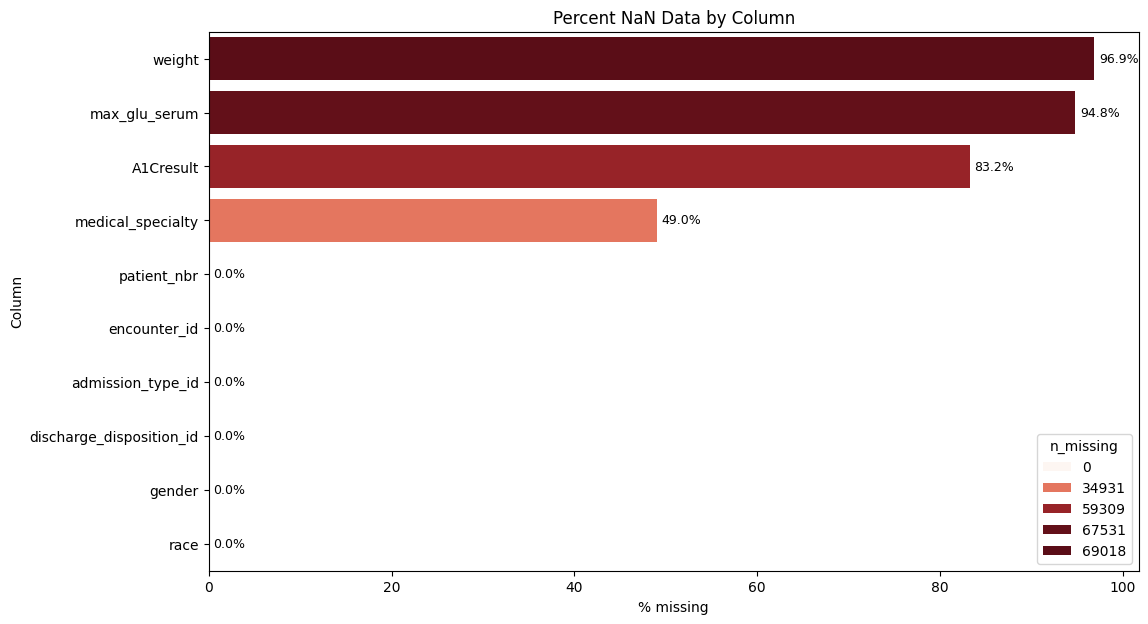

In [22]:
missing = X_train.isna().sum().to_frame(name='n_missing')
missing['pct_missing'] = (missing['n_missing'] / len(X_train) * 100).round(2)
missing = missing.sort_values('pct_missing', ascending=False)
display(missing.head(10))

top_missing = missing.head(10).reset_index().rename(columns={'index':'column'})

plt.figure(figsize=(12,7))


sns.barplot(data=top_missing, x='pct_missing', y='column', palette='Reds', hue='n_missing' )
plt.title('Percent NaN Data by Column')
plt.xlabel('% missing')
plt.ylabel('Column')

for i, pct in enumerate(top_missing['pct_missing']):
    plt.text(pct + 0.5, i, f'{pct:.1f}%', va='center', fontsize=9)

plt.show()

Weight, as we knew, is extremely sparse. As stated in Strack et al. we can also see that A1CResult has ~83% missing, the focus of their study.

Payer Code shows almost 40% missing, and will be dropped later on as not being useful in prediction.

Medical specialy is ~50% missing but is kept as a decent indicator of readmission.

# Data Preparation

### Read In Data

In [23]:
import pandas as pd
import numpy as np
# read in data
from shared_util.dataio import load_csv

df = load_csv('diabetic_data')

df = df.reset_index().rename(columns={'index': 'encounter_id'})


display(df.head())

X = df.drop(columns=['readmitted'])
y = df['readmitted']

y = pd.DataFrame(y)
y.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


,readmitted
0,NO
1,>30
2,NO
3,NO
4,NO


### Fix DTypes

In [24]:
# to address nans we need to convert to proper dtypes first
# fix diag column types
X['diag_1'] = X['diag_1'].astype('string')
X['diag_2'] = X['diag_2'].astype('string')
X['diag_3'] = X['diag_3'].astype('string')

# fix specialty column type
X['medical_specialty'] = X['medical_specialty'].astype('string').replace("?", np.nan)




# fix race
X['race'] = X['race'].astype('string')

# fix age
X['age'] = X['age'].astype('string')

X['change'] = X['change'].astype('string')


### Derive Target

In [25]:
y['readmitted'] = y['readmitted'].astype('string')

y['target'] = (y['readmitted'] == '<30').astype(int)

### Drop Payer_Code

In [26]:
# drop payer_code missing and un informative
X_0 = X.drop(columns=['payer_code'])

### Row-wise Cleaning

Class balance before row cleaning

In [27]:
print(f'Percent Readmitted In under 30 days: {y['target'].mean()*100:.2f}%')

Percent Readmitted In under 30 days: 11.16%


Address encounters that are not part of our target cohort.

As stated above, these drops are here to define our target cohort. In deployment, we would never be looking at patients who are transferred inpatient, we are only interested in patients at time of **discharge from the hospital**.

More specifically, we are looking to predict, at time of discharge, if an **adult** will be readmitted to the hospital wihin 90 days.

Several rows break the rules of our target study and need to be dropped.

Splitting before dropping these rows, would leave patients who would never, in practice, be predicted on, in our test and validation sets and would skew metrics.

Furthermore, there is a small subset of *discharge_disposition_id* values that leak future information that would not be known at discharge time.

In [28]:
# drop the newborn rows
#The dataset contains newborn encounters
# despite the original Diabetes 130-US study being restricted to adult patients (≥18 years).
non_adult = (X_0['admission_type_id'] == 4) | (X_0['discharge_disposition_id'] == 10) | (X_0['age'] == '[0-10)') | (X_0['age'] == '[10-20)')

_pre = len(X_0)


X_1 = X_0.loc[~non_adult].reset_index(drop=True)
y   = y.loc[~non_adult].reset_index(drop=True)
print(f'dropped: {_pre - len(X_1)}')

dropped: 867


In [29]:
# drop rows that show a patient expired

# from mapping info
_c = 'discharge_disposition_id'

expired_ids = [11, 19, 20]
X_2 = X_1.copy()

exp_mask = X_2[_c].isin(expired_ids)

_pre = len(X_2)
X_3 = X_2.loc[~exp_mask].reset_index(drop=True)
y   = y.loc[~exp_mask].reset_index(drop=True)
print(f'dropped: {_pre - len(X_3)}')

dropped: 1650


In [30]:
# drop rows of patients who were transferred (not discharged)
transferred_ids = [2, 3, 4, 5, 15, 22, 23, 24, 27, 28, 29, 30]
trans_mask = X_3[_c].isin(transferred_ids)
_pre = len(X_3)
X_3 = X_3.loc[~trans_mask].reset_index(drop=True)
y = y.loc[~trans_mask].reset_index(drop=True)
print(f'dropped {_pre - len(X_3)}')

dropped 20728


Export cleaned up data to csv

In [31]:
print(f'{len(X_3)} rows after cleaning')
print(f'len y={len(y['target'])}')
X_3_w = pd.concat([X_3, y['target']], axis=1)
#X_3_w.to_csv('cleaned')

78521 rows after cleaning
len y=78521


Class balance post cleaning

In [32]:
print(f'Percent Readmitted In under 30 days: {y['target'].mean()*100:.2f}%')

Percent Readmitted In under 30 days: 10.07%


A reduction here makes sense since patients who were transferred to an inpatient facility and not discharged in this data set would be the sickest patients of the set since they were not discharged. It would make sense these patients would have the highest readmission rate.

# Data Cleaning Pipeline

After initial row wise drops of bad data, the data was exported to csv. This data is the data read in to each cleaning pipeline.

This pipeline runs inside an sklearn (imblearn) pipeline to transform data across train/validate/test splits and cross validation folds without leaking global data beween splits or folds

The below code is illustrative of this process.

In [33]:
# Read data in and split
from shared_util.dataio import load_csv
from shared_util.split import group_split

df = load_csv('cleaned') # initial data starting point saved from above preparation process used to define the target cohort
display(len(df))
X_train, X_validate, X_test, y_train, y_validate, y_test = group_split(df)

78521

## Feature Transformation

Bin, organize, impute missing data, drop some un-needed columns.

The strategy that follows is based off of the strategy performed by Strack et al. in their study:

*Impact of HbA1c Measurement on Hospital Readmission Rates:
Analysis of 70,000 Clinical Database Patient Records*

### Addressing the Weight Problem

The weight feature contains 97% missing values and the remaining entries are categorical ranges. Because imputing numeric estimates would require strong assumptions about within-range weight distributions and would inject artificial structure into the data, the column was retained as a nominal categorical variable.

Missing values were encoded as an explicit “missing” category to preserve information without introducing bias from synthetic imputation.

In [34]:
# encode missing
X_train['weight'] = X_train['weight'].replace("?", 'missing')

display(X_train['weight'].value_counts())

# weight will be one-hot encoded, we need to fix the value names so they dont break xgboost

weight_map = {
   'missing': 'missing',
   '[75-100)' : '75-100',
   '[50-75)' : '50-75',
   '[100-125)' : '100-125',
   '[125-150)' : '125-150',
   '[25-50)' : '25-50',
   '[0-25)' : '0-25',
   '[150-175)' : '150-175',
   '[175-200)' : '175-200',
   '>200' : 'greater_200'
}

X_train['weight'] = X_train['weight'].map(weight_map)

X_train['weight'].value_counts()

weight
missing      53167
[75-100)       790
[50-75)        452
[100-125)      401
[125-150)       94
[25-50)         41
[0-25)          24
[150-175)       19
[175-200)        8
>200             1
Name: count, dtype: int64

weight
missing        53167
75-100           790
50-75            452
100-125          401
125-150           94
25-50             41
0-25              24
150-175           19
175-200            8
greater_200        1
Name: count, dtype: int64

### Binning Categorical Columns

In [35]:
def bin_categories(X):
        import re
        # bin diagnoses into groups
        _icd_num_re = re.compile(r'^(\d{3})(?:\.\d+)?$')   # e.g., '250.13' -> '250'

        def _parse_icd9(code):
            """
            Returns (prefix, num) where:
            - prefix is 'E', 'V', or '' for numeric codes
            - num is an integer 3-digit number if numeric; else None
            """
            if code is None or (isinstance(code, float) and np.isnan(code)):
                return '', None
            s = str(code).strip()
            if not s:
                return '', None
            first = s[0].upper()
            if first in ('E', 'V'):
                return first, None
            m = _icd_num_re.match(s)
            if m:
                return '', int(m.group(1))
            # Try float -> int of floor integer part
            try:
                return '', int(float(s))
            except Exception:
                return '', None

        def icd9_to_group(code):
            """
            Map a single ICD-9 code to the study's diagnosis group.
            """
            prefix, num = _parse_icd9(code)

            # External causes (E or V)
            if prefix in ('E', 'V'):
                return 'other'

            if num is None:
                return 'other'

            # Special case: Diabetes 250.xx
            if 250 <= num <= 250:
                return 'diabetes'

            # Primary named groups
            if (390 <= num <= 459) or (num == 785):
                return 'circulatory'
            if (460 <= num <= 519) or (num == 786):
                return 'respiratory'
            if (520 <= num <= 579) or (num == 787):
                return 'digestive'
            if 800 <= num <= 999:
                return 'injury'
            if 710 <= num <= 739:
                return 'musculoskeletal'
            if (580 <= num <= 629) or (num == 788):
                return 'genitourinary'
            if 140 <= num <= 239:
                return 'neoplasms'

            return 'other'

        # Admission source -> 3 bins
        def bin_admit_source(id: int) -> str:
            if id == 7:
                return 'emergency'
            if id == 1 or id == 2:
                return 'refer'
            return 'other'

        # Medical Specialty of admitting physician -> 6 bins including missing
        def bin_medical_specialty(value: str) -> str:
            if pd.isna(value) or value in ("Missing", "Unknown", "PhysicianNotFound", "OutreachServices", "DCPTEAM"):
                return "missing"

            val = str(value).strip().lower()

            if "internal" in val:
                return "internal_medicine"

            if "cardio" in val:
                return "cardiology"

            if "surg" in val or "orthopedic" in val or "urology" in val or "gyneco" in val or "neuro" in val or "vascular" in val or "thoracic" in val:
                return "surgery"

            if "family" in val or "general" in val or "gp" in val or "obstetric" in val or "pediatr" in val:
                return "pcp"

            # Everything else
            return "other"
        # Discharge Dispostion ->

        def bin_discharge(id: int) -> str:
            if id in [1, 6, 8, 13]:
                return 'home'
            if id in [2, 3, 4, 5, 15, 22, 23, 24, 27, 28, 29, 30]:
                raise ValueError(f'Inpatient-transferred patient detected: {id}')
            if id in [16, 17, 12]:
                return 'outpatient_followup'
            if id == 7:
                return 'left_ama'
            if id in [18, 25, 26]:
                return 'unknown'
            return 'unknown'

        # bin race -> Hispanic/Asian -> other since they have few values
        def bin_race(race: str) -> str:
            if (pd.isna(race)):
                return "other"
            race = race.strip().lower()
            if race == "caucasian":
                return "caucasian"
            if race == "africanamerican":
                return "african_american"
            return "other"


        # bin age -> 3 groups
        def bin_age(age: str) -> str:
            if ('10' in age or '20' in age):
                return 'under_30'
            if ('40' in age or '50' in age):
                return '30-60'
            return 'over_60'
        # bin a1c results
        def bin_a1c(val: str) -> str:
            if pd.isna(val):
                return 'no_test'
            if val in ('>7', '>8'):
                return 'high'
            if val.lower().startswith('norm'):
                return 'normal'
            return 'no_test'
        def bin_glucose(val: str) -> str:
            if pd.isna(val):
                return 'no_test'
            if val in ('>200', '>300'):
                return 'high'
            if val.lower().startswith('norm'):
                return 'normal'
            return 'no_test'

        # bin admission type id
        def bin_admit_type(id: int) -> str:
            if id in [5, 6, 8]: # Not Available, NULL, Not mapped
                return 'na'
            if id in [1,7]: # Emergency, Trauma Center
                return 'emergency'
            if id == 2:
                return 'urgent'
            if id == 3:
                return 'elective'
            return 'other'

        # bin number outpatient
        def bin_procedure_cols(num: int) -> str:
            if num == 0:
                return 'none'
            if num == 1:
                return 'one'
            if num in [2,3]:
                return 'few'
            if num < 8:
                return 'several'
            return 'frequent'

        # handle unknown/missing gender
        def bin_gender(gender: str) -> str:
            if gender.lower() == 'female':
              return 'female'
            if gender.lower() == 'male':
              return 'male'
            return 'unknown'



        _X = X.copy()


        _X['diag1_group'] =_X['diag_1'].apply(icd9_to_group)
        _X['diag2_group'] =_X['diag_2'].apply(icd9_to_group)
        _X['diag3_group'] =_X['diag_3'].apply(icd9_to_group)
        _X['admission_source'] =_X['admission_source_id'].apply(bin_admit_source)
        _X['discharge_loc'] =_X['discharge_disposition_id'].apply(bin_discharge)
        _X['specialty_cat'] =_X['medical_specialty'].apply(bin_medical_specialty)
        _X['race_cat'] =_X['race'].apply(bin_race)
        _X['age_group'] =_X['age'].apply(bin_age)
        _X['a1c_group'] =_X['A1Cresult'].apply(bin_a1c)
        _X['glucose_group'] =_X['max_glu_serum'].apply(bin_glucose)
        _X['admit_type_group'] =_X['admission_type_id'].apply(bin_admit_type)
        _X['v_outpatient_group'] =_X['number_outpatient'].apply(bin_procedure_cols)
        _X['v_emergency_group'] =_X['number_emergency'].apply(bin_procedure_cols)
        _X['gender'] = _X['gender'].apply(bin_gender)

        return _X

Apply the categorical transformations

In [36]:
X_0 = bin_categories(X_train)

X_0.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'medical_specialty', 'num_lab_procedures',
       'num_procedures', 'num_medications', 'number_outpatient',
       'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3',
       'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin',
       'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
       'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'diag1_group',
       'diag2_group', 'diag3_group', 'admission_source', 'discharge_loc',
       'specialty_cat', 'race_c

Drop previous category columns

In [37]:
X_1 = X_0.drop(
    columns=['diag_1',
             'diag_2',
             'diag_3',
             'admission_source_id',
             'discharge_disposition_id',
             'medical_specialty',
             'race',
             'age',
             'A1Cresult',
             'max_glu_serum',
             'admission_type_id'
             ])

### One hot encode the new categories



The first columns are one hot encoded for every model

In [38]:
columns = [ 'diag1_group',
                    'diag2_group',
                    'diag3_group',
                    'admission_source',
                    'discharge_loc',
                    'specialty_cat',
                    'race_cat',
                    'age_group',
                    'gender',
                    'a1c_group',
                    'glucose_group',
                    'admit_type_group',
                    'weight'
                ]

For linear models, the continous columns that were rencoded to categorical, are one hot encoded. For Tree models, they are left categorical, but transformed to integer

In [39]:
columns.append('v_outpatient_group')
columns.append('v_emergency_group')

In [40]:
X_2 = pd.get_dummies(X_1, columns=columns, dtype=int)
# X_2 = X_2.rename(columns={'gender_Female' : 'gender_female', 'gender_Male' : 'gender_male'})
display(X_2.columns.to_list())

['encounter_id',
 'patient_nbr',
 'time_in_hospital',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'number_diagnoses',
 'metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'acetohexamide',
 'glipizide',
 'glyburide',
 'tolbutamide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'troglitazone',
 'tolazamide',
 'examide',
 'citoglipton',
 'insulin',
 'glyburide-metformin',
 'glipizide-metformin',
 'glimepiride-pioglitazone',
 'metformin-rosiglitazone',
 'metformin-pioglitazone',
 'change',
 'diabetesMed',
 'diag1_group_circulatory',
 'diag1_group_diabetes',
 'diag1_group_digestive',
 'diag1_group_genitourinary',
 'diag1_group_injury',
 'diag1_group_musculoskeletal',
 'diag1_group_neoplasms',
 'diag1_group_other',
 'diag1_group_respiratory',
 'diag2_group_circulatory',
 'diag2_group_diabetes',
 'diag2_group_digestive',
 'diag2_group_genitourinary',
 'diag2_group_i

### Drug Columns

Drug-related columns were simplified to reduce dimensionality and mitigate sparsity issues. Many of these features are highly correlated and contain limited unique information, as most drug indicators share similar change patterns (e.g., “No” or “Steady” across patients). Prior studies on this dataset (e.g., Strack et al., 2014; Weiss & Jiang, 2021) have dropped many drug features entirely for the same reason.

We instead retain some aggregate signal while minimizing redundancy by:

1. Encoding each drug as binary (changed vs. unchanged) to focus on medication adjustments, which are more clinically meaningful for predicting readmission.

2. Summing across drugs to form a num_drugs feature that captures overall medication complexity.

3. Keeping only Insulin and Metformin, the two most clinically relevant medications for diabetes management, while dropping the rest to reduce noise and multicollinearit

In [41]:
X_2['diabetesMed_flag'] = (X_2['diabetesMed'].str.lower() == 'yes').astype(int)
X_2['change_flag'] = (X_2['change'].str.lower() == 'ch').astype(int)

drug_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
    'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
]

for col in drug_cols:
    X_2[f'{col}_flag'] = (X_2[col].str.lower() != 'no').astype(int)

# sum across medicine for amount of medicine prescribed
X_2['num_drugs'] = X_2[[f'{c}_flag' for c in drug_cols]].sum(axis=1)

### Interaction Terms

Baseline will be the interaction terms that were found statistically signifigant in Strack et al.

That is (by P):
- Discharge disposition × Time in hospital (p < 0.001)
- Medical specialty of admitting physician × Age (p < 0.001)
- Primary diagnosis × Time in hospital (p < 0.001)
- Discharge disposition × Race (p < 0.001)
- Discharge disposition × Medical specialty of admitting physician (p = 0.001)
- Medical Specialty x Time in hospitcal (p = 0.001)

I'll leave out for now:
- Discharge disposition x Primary diagnosis (p = 0.005)
- Primary diagnosis x HbA1c (p = 0.004)

In [42]:
# categorical x numerical columns
X_3 = X_2.copy()
for col in X_3.filter(like='diag1_group_'):
    X_3[f'i_hosp_time__{col}'] = X_3[col] * X_3['time_in_hospital']

# medical specialty of admitting physician x time in hospital
for col in X_3.filter(like='specialty_cat_'):
    X_3[f'i_hosp_time__{col}'] = X_3[col] * X_3['time_in_hospital']

# Discharge Disposition x time in hospital
for col in X_3.filter(regex=r'^discharge_loc_'):
    X_3[f'i_hosp_time__{col}'] = X_3[col] * X_3['time_in_hospital']

In [43]:
# categorical x categorical
def add_dummy_interactions(df, left_cols, right_cols, prefix='i_'):
    out = df.copy()
    L = [c for c in left_cols  if c in out.columns]
    R = [c for c in right_cols if c in out.columns]
    count = 0
    for lc in L:
        for rc in R:
            col_name = f'{prefix}{lc}__{rc}'
            out[col_name] = out[lc] * out[rc]
            count += 1



    return out


X_4 = X_3.copy()

# setup column lists
specialty_cols = X_4.filter(regex=r'^specialty_cat_').columns.to_list()
age_cols = X_4.filter(regex=r'^age_group_').columns.to_list()
diag_cols = X_4.filter(regex=r'^diag1_group_').columns.to_list()
race_cols = X_4.filter(regex=r'^race_cat_').columns.to_list()
discharge_cols = X_4.filter(regex=r'^discharge_loc_').columns.to_list()


X_4 = add_dummy_interactions(
    X_4,
    left_cols=specialty_cols,
    right_cols=age_cols
)

# discharge dispo x race
X_4 = add_dummy_interactions(
    X_4,
    left_cols= discharge_cols,
    right_cols=race_cols
)

# discharge x specialty

X_4 = add_dummy_interactions(
    X_4,
    left_cols=discharge_cols,
    right_cols=specialty_cols
)

For distance based models, several continous columns are log transformed

In [44]:
X_5 = X_4.copy()
LOG_TRANSFORM_COLS = np.array(
    ['num_medications', 'num_procedures', 'time_in_hospital', 'number_inpatient'
     ])
X_5[LOG_TRANSFORM_COLS] = np.log1p(X_5[LOG_TRANSFORM_COLS])

The full cleaning pipeline is wrapped inside of a Model Pipeline that handles everything from reading the data in, running the cleaner, running baselines, validation, testing, hyperparameter searches, and feature importance on a spcified model.

This pipeline exposes important variables and settings to the notebook to allow customization of each run

### Feature Dropping

For each split/fold passed through the cleaning pipeline, the most frequent value for each one-hot categorical is recorded. That column is dropped from each set to avoid linearly-dependent columns.

In [45]:
from typing import Dict
def _choose_ref_dummies(X: pd.DataFrame) -> Dict[str, str]:
        one_hot_ordinal = True
        # Map each dummy family to a regex
        families = {
            'diag1_group_':       r'^diag1_group_',
            'diag2_group_':       r'^diag2_group_',
            'diag3_group_':       r'^diag3_group_',
            'admission_source_':  r'^admission_source_',
            'discharge_loc_':     r'^discharge_loc_',
            'specialty_cat_':     r'^specialty_cat_',
            'race_cat_':          r'^race_cat_',
            'age_group_':         r'^age_group_',
            'gender_':            r'^gender_',
            'a1c_group_':         r'^a1c_group_',
            'glucose_group_':     r'^glucose_group_',
            'admit_type_group_':  r'^admit_type_group_',
        }

        if one_hot_ordinal:
            families['v_outpatient_group'] = r'^v_outpatient_group'
            families['v_emergency_group'] = r'^v_emergency_group'

        refs = {}
        for fam, pat in families.items():
            cols = X.filter(regex=pat).columns
            if len(cols) >= 2:
                # Choose the most frequent level as reference (sum of one-hot = count)
                counts = X[cols].sum(axis=0)
                ref_col = counts.idxmax()
                refs[fam] = ref_col
        return refs

After feature creation, several feature are dropped.

drug columns, and diabetesMed, change are dropped since they are replaced with binary flags

drug flags are also dropped after summing to create the num_drug feature, except for Metforming and Insulin flags since these are the two most important diabetes medications.

# Modeling Runs

This section uses the modeling pipeline imported from the pip package from github

The full code for the modeling pipeline can be found in the code reference

The models are presented in no particular order

Every model goes through the same process:

1. Define model pipeline
      - define model level configuration such as interaction term creation, scaler configuration ect...
2. Run a baseline (optional SMOTE vs RandomUnderSampler testing)
      - 5-fold grouped CV tesing
3. Display feature importance plot using permutation importance of features
      - left out svc, knn due to computation time
4. Run Randomized Hyperparameter seach using 5 fold cross validation randomize search grouped by patient number
5. Use the calculated parameters to predict on the held out validation set
6. Calcuate a cost-based threshold to maximize per-patient savings (see results section for further explanation on this)
7. Use the cost-based thrshold to predict on the held out test set, print and plot metrics along the way for each step

## Multilayer Perceptron

MLP was chosen after reading about its strengths and weaknesses in Liu et al. (2024) where it was chosen for its ability to model complex non-linear relationships.

In [43]:
mlp_pipe = ModelPipeline(
    model='mlp',
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    data_path='cleaned',
    plot_y_dist=False,
    random_state=42,
    log_transform_cols=LOG_TRANSFORM_COLS,
    scaler= scaler,
    create_interactions=True,
    one_hot_ordinal=True
)

In [44]:
if GET_BASELINE:
    mlp_pipe.run_baseline(
        run_smote=True,
        show_duration_info=True,
        run_undersampler=True
    )

In [45]:
if SHOW_FEAT_IMPORTANCE:
    mlp_pipe.permute_importance()

In [46]:
if not USE_PRE_COMPUTED_HYPERPARAMS:
    mlp_param_dist = {
        'model__hidden_layer_sizes': [
            (50,), (100,), (50, 50), (100, 50),
            (100, 100), (128, 64, 32)
        ],
        'model__alpha': np.logspace(-5, -1, 10),
        'model__learning_rate': ['constant', 'adaptive'],
        'model__learning_rate_init': np.logspace(-4, -1, 10),
        'model__activation': ['relu', 'tanh'],
        'model__solver': ['adam', 'lbfgs'],
    }

    mlp_pipe.run_hyperparam_search(hyperparam_dist=mlp_param_dist)

In [47]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    mlp_pipe.validate(
        use_local_model=True,
        show_duration_info=True,
        solver='adam',
        learning_rate_init=0.1,
        learning_rate='adaptive',
        hidden_layer_sizes=(100, 50),
        alpha=1e-05,
        activation='tanh'
    )
else:
    mlp_pipe.validate()

Held out validation metrics: mlp
ROC_AUC:     0.6235079523635528
Accuracy:      0.5928097909229985
F1 score:      0.22059541239629088
Precision:     0.13516746411483255
Recall:        0.5994694960212201

Confusion matrix:

TN: 6297, FP: 4338, FN: 453, TP: 678

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.59      0.72     10635
           1       0.14      0.60      0.22      1131

    accuracy                           0.59     11766
   macro avg       0.53      0.60      0.47     11766
weighted avg       0.86      0.59      0.68     11766

Duration: 0 hrs, 0 mins, 3.4 secs


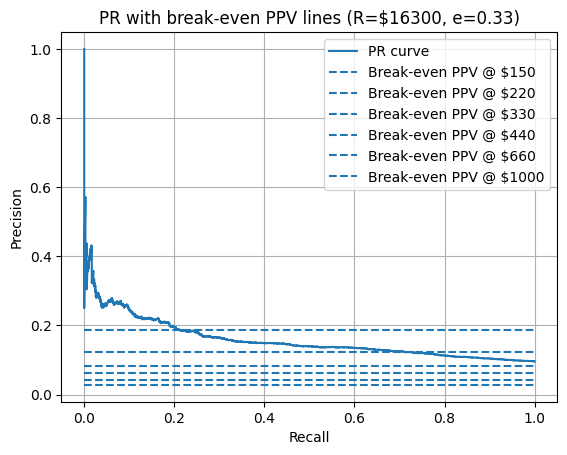

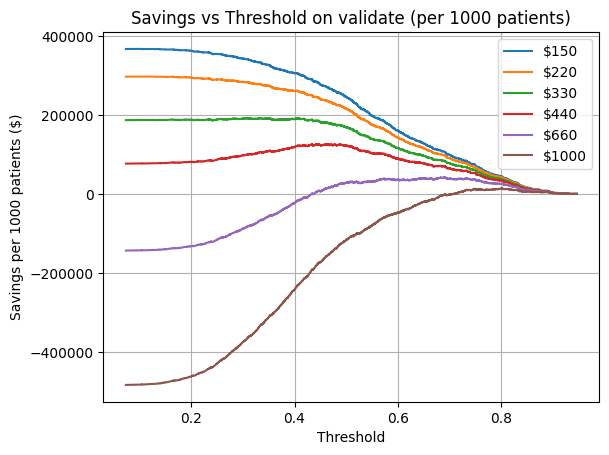

[COST] Chosen threshold: 0.3351 | PPV=0.107  Recall=0.871  FlagRate=0.780  Savings@$330=192.81 per patient
ROC_AUC:     0.5978252756671084
Accuracy:      0.28270113964960025
F1 score:      0.1865354938271605
Precision:     0.1048465792041635
Recall:        0.8445414847161572

Confusion matrix:

TN: 2357, FP: 8256, FN: 178, TP: 967

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.22      0.36     10613
           1       0.10      0.84      0.19      1145

    accuracy                           0.28     11758
   macro avg       0.52      0.53      0.27     11758
weighted avg       0.85      0.28      0.34     11758

Duration: 0 hrs, 0 mins, 0.7 secs


In [48]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    mlp_pipe.test(
        c_m_list=m_cost_list,
        use_local_model=True,
        prefer_c_m=COST_PREF,
        show_duration_info=True,
        solver='adam',
        learning_rate_init=0.1,
        learning_rate='adaptive',
        hidden_layer_sizes=(100, 50),
        alpha=1e-05,
        activation='tanh'
    )
else:
    mlp_pipe.test(prefer_c_m=COST_PREF,c_m_list=m_cost_list)

## Logistic Regression

Logistic Regression was included as a baseline model due to its interpretability and efficiency. It provides a well-understood probabilistic framework for binary classification, making it an ideal benchmark for evaluating more complex models.

In [3]:
lr_pipe = ModelPipeline(
    model='lr',
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    data_path='cleaned',
    plot_y_dist=False,
    random_state=42,
    log_transform_cols=LOG_TRANSFORM_COLS,
    scaler= scaler,
    create_interactions=True,
    one_hot_ordinal=True
)

In [4]:
if GET_BASELINE:
    lr_pipe.run_baseline(
        run_smote=True,
        show_duration_info=True,
        run_undersampler=True
    )

In [5]:
if SHOW_FEAT_IMPORTANCE:
    lr_pipe.permute_importance()

In [6]:
if not USE_PRE_COMPUTED_HYPERPARAMS:
    lr_param_dist = {
        'model__C': np.logspace(-4, 2, 20),
        'model__penalty': ['l1', 'l2', 'elasticnet'],
        'model__solver': ['saga'],
        'model__l1_ratio': np.linspace(0, 1, 5),
    }

    lr_pipe.run_hyperparam_search(hyperparam_dist=lr_param_dist)

In [7]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    lr_pipe.validate(
        use_local_model=True,
        show_duration_info=True,
        solver='saga',
        penalty='elasticnet',
        l1_ratio=0.5,
        C=0.01623776739188721
    )
else:
    lr_pipe.validate()

Held out validation metrics: lr
ROC_AUC:     0.6573121796846324
Accuracy:      0.6757606663267041
F1 score:      0.23958540960733507
Precision:     0.1546577457539887
Recall:        0.5313881520778072

Confusion matrix:

TN: 7350, FP: 3285, FN: 530, TP: 601

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.69      0.79     10635
           1       0.15      0.53      0.24      1131

    accuracy                           0.68     11766
   macro avg       0.54      0.61      0.52     11766
weighted avg       0.86      0.68      0.74     11766

connected to database
Duration: 0 hrs, 0 mins, 44.9 secs


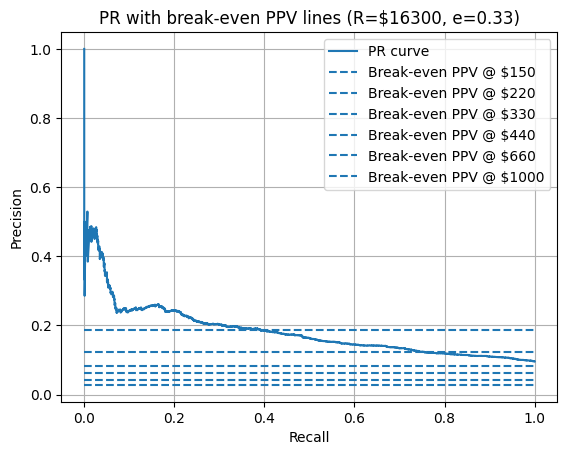

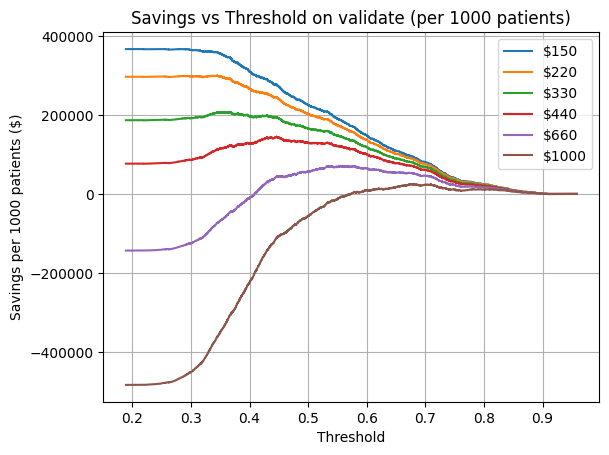

[COST] Chosen threshold: 0.3667 | PPV=0.112  Recall=0.893  FlagRate=0.767  Savings@$330=208.50 per patient
ROC_AUC:     0.6396777948441745
Accuracy:      0.30328287123660486
F1 score:      0.1949685534591195
Precision:     0.10984387111061898
Recall:        0.8663755458515284

Confusion matrix:

TN: 2574, FP: 8039, FN: 153, TP: 992

Classification report:
               precision    recall  f1-score   support

           0       0.94      0.24      0.39     10613
           1       0.11      0.87      0.19      1145

    accuracy                           0.30     11758
   macro avg       0.53      0.55      0.29     11758
weighted avg       0.86      0.30      0.37     11758

Duration: 0 hrs, 0 mins, 0.7 secs


In [8]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    lr_pipe.test(
        use_local_model=True,
        show_duration_info=True,
        solver='saga',
        penalty='elasticnet',
        l1_ratio=0.5,
        C=0.01623776739188721,
        c_m_list=m_cost_list,
        prefer_c_m=COST_PREF
    )
else:
    lr_pipe.test(
        prefer_c_m=COST_PREF,
        c_m_list=m_cost_list
    )

## K-Nearest Neighbors

KNN was included as a baseline non-parametric model to contrast with linear methods.

In [9]:
knn_pipe = ModelPipeline(
    model='knn',
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    data_path='cleaned',
    plot_y_dist=False,
    random_state=42,
    log_transform_cols=LOG_TRANSFORM_COLS,
    scaler= scaler,
    create_interactions=True,
    one_hot_ordinal=True
)

In [10]:
if GET_BASELINE:
    knn_pipe.run_baseline(
        run_smote=True,
        show_duration_info=True,
        run_undersampler=True
    )

In [11]:
if not USE_PRE_COMPUTED_HYPERPARAMS:
    knn_param_dist = {
        "model__n_neighbors": np.arange(3, 31, 2),
        "model__weights": ["uniform", "distance"],
        "model__metric": ["euclidean", "manhattan", "minkowski"],
        "model__p": [1, 2],
        "model__leaf_size": np.arange(10, 50, 5)
        }

    knn_pipe.run_hyperparam_search(hyperparam_dist=knn_param_dist)



In [12]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    knn_pipe.validate(
        use_local_model=True,
        show_duration_info=True,
        weights='distance',
        n_neighbors=29,
        metric='euclidean',
        leaf_size=15,
        p=1
    )
else:
    knn_pipe.validate()

Held out validation metrics: knn
ROC_AUC:     0.581233078806154
Accuracy:      0.6206867244603094
F1 score:      0.19744650242762093
Precision:     0.12392776523702032
Recall:        0.4854111405835544

Confusion matrix:

TN: 6754, FP: 3881, FN: 582, TP: 549

Classification report:
               precision    recall  f1-score   support

           0       0.92      0.64      0.75     10635
           1       0.12      0.49      0.20      1131

    accuracy                           0.62     11766
   macro avg       0.52      0.56      0.47     11766
weighted avg       0.84      0.62      0.70     11766

Duration: 0 hrs, 0 mins, 4.9 secs


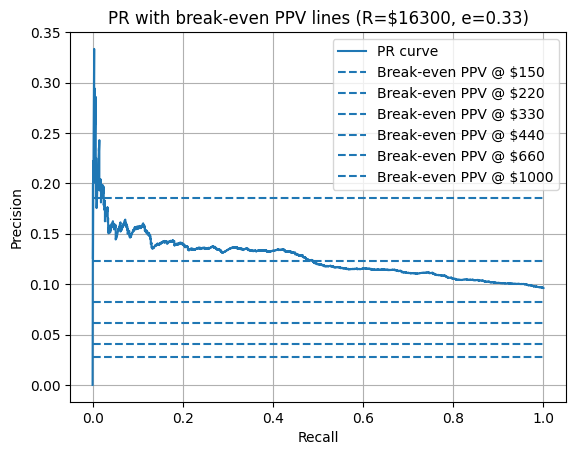

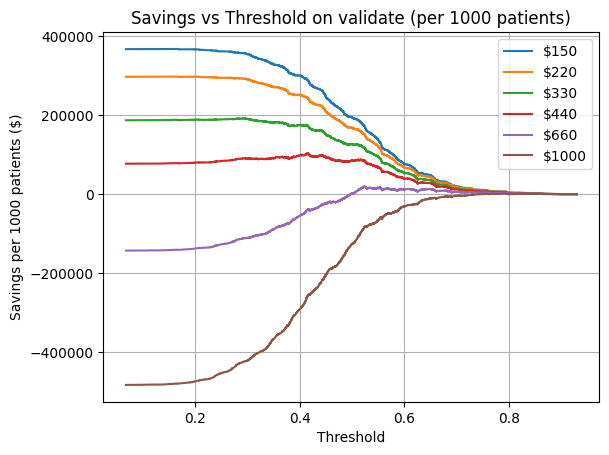

[COST] Chosen threshold: 0.2898 | PPV=0.100  Recall=0.958  FlagRate=0.921  Savings@$330=191.76 per patient
ROC_AUC:     0.5671094649101766
Accuracy:      0.16465385269603675
F1 score:      0.18286189683860232
Precision:     0.10105747126436782
Recall:        0.959825327510917

Confusion matrix:

TN: 837, FP: 9776, FN: 46, TP: 1099

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.08      0.15     10613
           1       0.10      0.96      0.18      1145

    accuracy                           0.16     11758
   macro avg       0.52      0.52      0.16     11758
weighted avg       0.87      0.16      0.15     11758

Duration: 0 hrs, 0 mins, 1.1 secs


In [13]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    knn_pipe.test(
        c_m_list=m_cost_list,
        use_local_model=True,
        prefer_c_m=COST_PREF,
        show_duration_info=True,
        weights='distance',
        n_neighbors=29,
        metric='euclidean',
        leaf_size=15,
        p=1
    )
else:
    knn_pipe.test(prefer_c_m=COST_PREF,c_m_list=m_cost_list)

## Naive-bayes

In [14]:
nb_pipe = ModelPipeline(
    model='nb',
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    data_path='cleaned',
    plot_y_dist=False,
    random_state=42,
    log_transform_cols=LOG_TRANSFORM_COLS,
    scaler= scaler,
    create_interactions=True,
    one_hot_ordinal=True
)

In [15]:
if GET_BASELINE:
    nb_pipe.run_baseline(
        run_smote=True,
        show_duration_info=True,
        run_undersampler=True
    )


In [16]:
if SHOW_FEAT_IMPORTANCE:
    nb_pipe.permute_importance()

In [17]:
if not USE_PRE_COMPUTED_HYPERPARAMS:

    gnb_param_dist = {
        "model__var_smoothing": np.logspace(-12, -6, 20)
    }

    nb_pipe.run_hyperparam_search(hyperparam_dist=gnb_param_dist)



In [18]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    nb_pipe.validate(
        use_local_model=True,
        show_duration_info=True,
        var_smoothing=1e-06,
    )
else:
    nb_pipe.validate()

Held out validation metrics: nb
ROC_AUC:     0.595555480731299
Accuracy:      0.7083970763216046
F1 score:      0.19892598645809012
Precision:     0.1351522842639594
Recall:        0.376657824933687

Confusion matrix:

TN: 7909, FP: 2726, FN: 705, TP: 426

Classification report:
               precision    recall  f1-score   support

           0       0.92      0.74      0.82     10635
           1       0.14      0.38      0.20      1131

    accuracy                           0.71     11766
   macro avg       0.53      0.56      0.51     11766
weighted avg       0.84      0.71      0.76     11766

Duration: 0 hrs, 0 mins, 1.9 secs


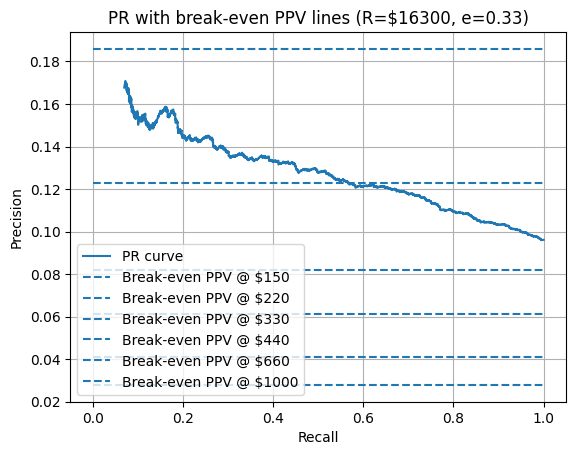

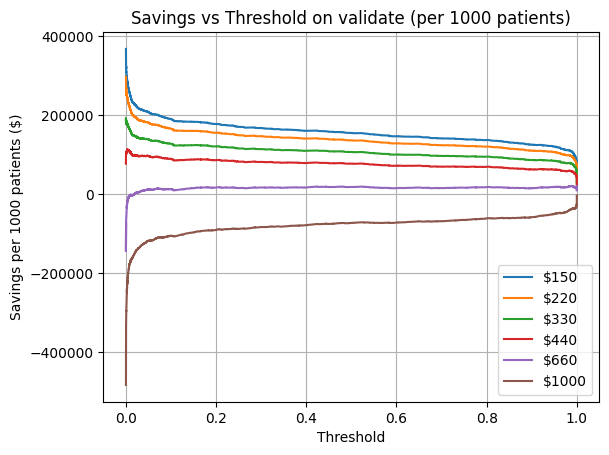

[COST] Chosen threshold: 0.0000 | PPV=0.104  Recall=0.913  FlagRate=0.848  Savings@$330=192.37 per patient
ROC_AUC:     0.5811739495559742
Accuracy:      0.2305664228610308
F1 score:      0.1835574406642
Precision:     0.10235507246376811
Recall:        0.8882096069868995

Confusion matrix:

TN: 1694, FP: 8919, FN: 128, TP: 1017

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.16      0.27     10613
           1       0.10      0.89      0.18      1145

    accuracy                           0.23     11758
   macro avg       0.52      0.52      0.23     11758
weighted avg       0.85      0.23      0.26     11758

Duration: 0 hrs, 0 mins, 0.8 secs


In [19]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    nb_pipe.test(
        use_local_model=True,
        show_duration_info=True,
        c_m_list=m_cost_list,
        prefer_c_m=COST_PREF,
        var_smoothing=1e-06,

    )
else:
    nb_pipe.test(prefer_c_m=COST_PREF,c_m_list=m_cost_list)

## Random Forest

RF was the first model chosen after reading (Liu, V. et al.) and (Mahmoud, M. et al.) which showed it had very good performance among their tested models.

In other studies, random forest models were shown to out perform logsitic regression and support vector models likely due to the mix of tabular, categorical, and numerical features

In [20]:
model_pipe = ModelPipeline(
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    data_path='cleaned',             # csv file name where the data is
    plot_y_dist=False,                # show the target distribution between splits
    random_state=42,
    log_transform_cols=np.array([]), # no need to transform for tree models
    model='rf',
    scaler=None,
    group_by_col='patient_nbr',
    create_interactions=False, # no interaction terms for tree models
    one_hot_ordinal=False, # no one-hot encoding for tree models, use int based grouping
)

In [21]:
if GET_BASELINE:
    model_pipe.run_baseline(
        run_smote=True,
        run_undersampler=True,
        show_duration_info=True,
    )

In [22]:
if SHOW_FEAT_IMPORTANCE:
    model_pipe.permute_importance(
        print_num=15,
        plot=True,
        show_duration_info=True
    )

In [23]:
if not USE_PRE_COMPUTED_HYPERPARAMS:
    param_grid = {
            'model__n_estimators': [100, 200, 500],
            'model__max_depth': [None, 10, 20, 30],
            'model__min_samples_split': [2, 5, 10, 15, 20],
            'model__min_samples_leaf': [1, 2, 4, 6, 10],
            'model__max_features': ['sqrt', 'log2', 0.2, 0.5],
            'model__class_weight': [None, 'balanced'],
            'model__bootstrap': [True, False],
            'model__oob_score': [True, False]
        }

    model_pipe.run_hyperparam_search(
        hyperparam_dist=param_grid,
        param_scoring='roc_auc',
        n_iter=30,
        n_jobs=-1,
        refit=True,
        show_duration_info=True
    )

In [24]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    model_pipe.validate(
        show_duration_info=True,
        use_local_model=True,
        oob_score = True,
        n_estimators = 200,
        min_samples_split = 15,
        min_samples_leaf = 6,
        max_features = 'log2',
        max_depth = 10,
        class_weight = None,
        bootstrap = True
    )

else:
    model_pipe.validate(
        show_duration_info=False,
        use_local_model=False
    )

Held out validation metrics: rf
ROC_AUC:     0.653019636794745
Accuracy:      0.65595784463709
F1 score:      0.23766478342749528
Precision:     0.15099306054079922
Recall:        0.5579133510167993

Confusion matrix:

TN: 7087, FP: 3548, FN: 500, TP: 631

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.67      0.78     10635
           1       0.15      0.56      0.24      1131

    accuracy                           0.66     11766
   macro avg       0.54      0.61      0.51     11766
weighted avg       0.86      0.66      0.73     11766

Duration: 0 hrs, 0 mins, 2.6 secs


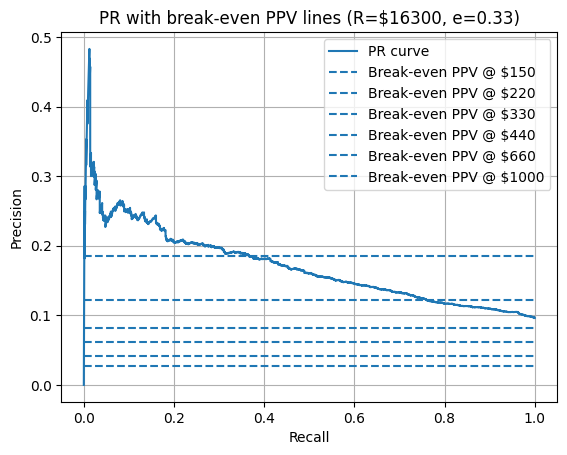

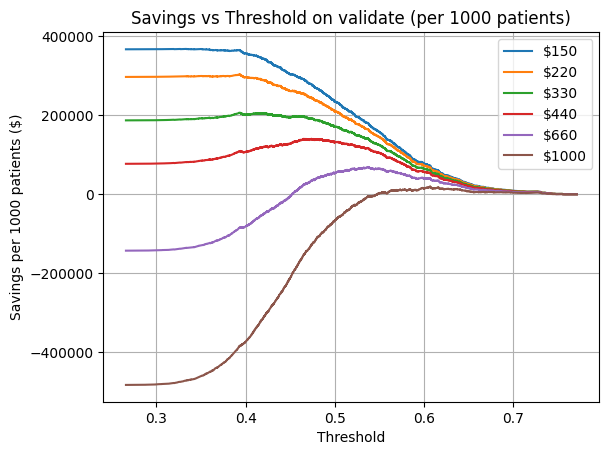

[COST] Chosen threshold: 0.3930 | PPV=0.105  Recall=0.963  FlagRate=0.883  Savings@$330=206.50 per patient
ROC_AUC:     0.641918517168324
Accuracy:      0.20301071610818167
F1 score:      0.18703912553136115
Precision:     0.10383355808129455
Recall:        0.9414847161572052

Confusion matrix:

TN: 1309, FP: 9304, FN: 67, TP: 1078

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.12      0.22     10613
           1       0.10      0.94      0.19      1145

    accuracy                           0.20     11758
   macro avg       0.53      0.53      0.20     11758
weighted avg       0.87      0.20      0.22     11758



In [25]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    model_pipe.test(
        use_f2_threshold=False,
        show_duration_info=False,
        show_plot=True,
        use_local_model=True,
        use_cost_threshold=True,
        R=R,
        e=e,
        c_m_list=m_cost_list,
        prefer_c_m=COST_PREF,
        oob_score = True,
        n_estimators = 200,
        min_samples_split = 15,
        min_samples_leaf = 6,
        max_features = 'log2',
        max_depth = 10,
        class_weight = None,
        bootstrap = True
    )
else:
    model_pipe.test(
        use_f2_threshold=False,
        show_duration_info=False,
        show_plot=True,
        use_local_model=False,
        use_cost_threshold=True,
        R=R,
        e=e,
        c_m_list=m_cost_list,
        prefer_c_m=COST_PREF,
    )

## Stochastic Gradient Descent Classifier

SGDClassifier was included because it scales efficiently to high-dimensional data and provides a fast, linear baseline that incorporates regularization. With hinge or logistic loss, it approximates SVMs or logistic regression while training orders of magnitude faster, which is helpful for rapid iteration and hyperparameter exploration.

In [26]:
sgd_pipe = ModelPipeline(
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    plot_y_dist=False,
    log_transform_cols=LOG_TRANSFORM_COLS,
    model='sgd',
    scaler=scaler,
    use_pca=PCA,
    create_interactions=True,
    one_hot_ordinal=True
)

In [27]:
if SHOW_FEAT_IMPORTANCE:
    sgd_pipe.run_baseline() # all true

----------Running Feature Importance for model: sgd----------


,feature,importance_mean,importance_std
4,number_inpatient,0.051856,0.009778
5,number_diagnoses,0.005318,0.002138
0,time_in_hospital,0.004639,0.002682
85,diabetesMed_flag,0.003766,0.001879
11,diag1_group_musculoskeletal,0.003273,0.003649
14,diag1_group_respiratory,0.002161,0.001752
82,v_emergency_group_none,0.001936,0.000850
21,diag2_group_neoplasms,0.001805,0.001538
81,v_emergency_group_frequent,0.000955,0.000495
6,diag1_group_circulatory,0.000938,0.001398


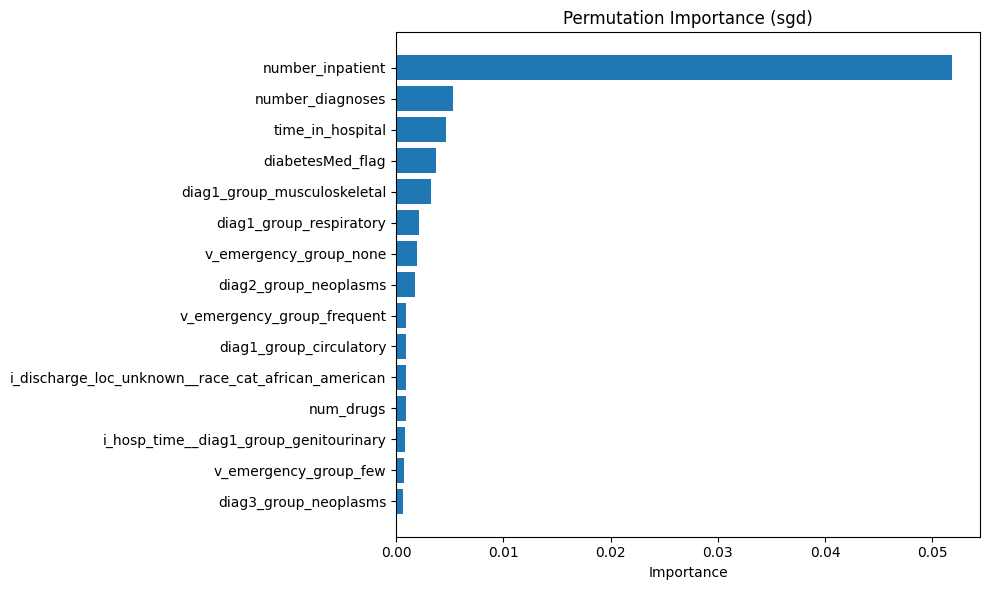

Duration: 0 hrs, 0 mins, 28.6 secs


In [28]:
if not SHOW_FEAT_IMPORTANCE:
    sgd_pipe.permute_importance()

In [29]:
if not USE_PRE_COMPUTED_HYPERPARAMS:
    sgd_param_grid = {
        "model__loss": ["log_loss", "modified_huber", "hinge", "squared_hinge"],
        "model__penalty": ["l2", "l1", "elasticnet"],
        "model__alpha": [1e-6, 1e-5, 1e-4, 1e-3, 1e-2],
        "model__l1_ratio": [0.1, 0.5, 0.9],
        "model__learning_rate": ["constant", "optimal", "invscaling", "adaptive"],
        "model__eta0": [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1],
        "model__max_iter": [100, 500, 1000],
        "model__tol": [1e-3, 1e-4],
        "model__class_weight": [None, "balanced"],
        "model__average": [False, True, 5, 10],
        "model__shuffle": [True],
    }

    sgd_pipe.run_hyperparam_search(hyperparam_dist=sgd_param_grid)

In [30]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    sgd_pipe.validate(
        show_duration_info=True,
        use_local_model=True,
        tol=.0001,
        shuffle=True,
        penalty='l1',
        max_iter=500,
        loss='modified_huber',
        learning_rate='invscaling',
        l1_ratio=0.9,
        eta0=.003,
        class_weight=None,
        average=10,
        alpha=.001
        )
else:
    sgd_pipe.validate(show_duration_info=False)

Held out validation metrics: sgd
ROC_AUC:     0.6575719445618768
Accuracy:      0.6755056943736188
F1 score:      0.23822825219473265
Precision:     0.15382633341922186
Recall:        0.5278514588859416

Confusion matrix:

TN: 7351, FP: 3284, FN: 534, TP: 597

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.69      0.79     10635
           1       0.15      0.53      0.24      1131

    accuracy                           0.68     11766
   macro avg       0.54      0.61      0.52     11766
weighted avg       0.86      0.68      0.74     11766

Duration: 0 hrs, 0 mins, 2.2 secs


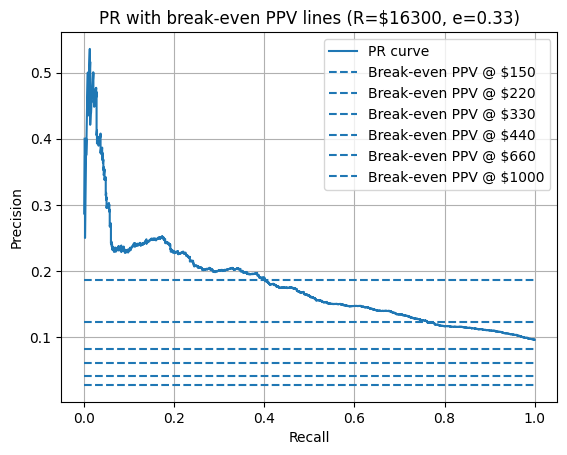

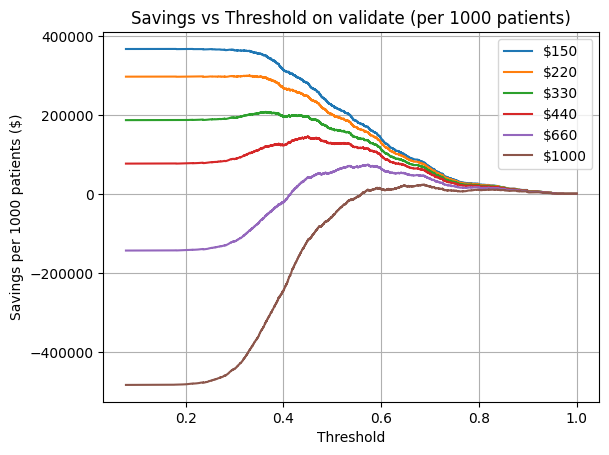

[COST] Chosen threshold: 0.3637 | PPV=0.110  Recall=0.910  FlagRate=0.795  Savings@$330=208.21 per patient
ROC_AUC:     0.639106525448521
Accuracy:      0.2808300731416908
F1 score:      0.19328372448006106
Precision:     0.10849309199957159
Recall:        0.8847161572052402

Confusion matrix:

TN: 2289, FP: 8324, FN: 132, TP: 1013

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.22      0.35     10613
           1       0.11      0.88      0.19      1145

    accuracy                           0.28     11758
   macro avg       0.53      0.55      0.27     11758
weighted avg       0.86      0.28      0.34     11758

Duration: 0 hrs, 0 mins, 0.7 secs


In [31]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    sgd_pipe.test(
        use_f2_threshold=False,
        show_plot=True,
        use_cost_threshold=True,
        R=R,
        e=e,
        c_m_list=m_cost_list,
        prefer_c_m=COST_PREF,
        show_duration_info=True,
        use_local_model=True,
        tol=.0001,
        shuffle=True,
        penalty='l1',
        max_iter=500,
        loss='modified_huber',
        learning_rate='invscaling',
        l1_ratio=0.9,
        eta0=.003,
        class_weight=None,
        average=10,
        alpha=.001
    )

else:
    sgd_pipe.test(
        use_f2_threshold=False,
        show_duration_info=False,
        show_plot=True,
        use_local_model=False,
        use_cost_threshold=True,
        R=R,
        e=e,
        c_m_list=m_cost_list,
        prefer_c_m=COST_PREF,
    )

## Support Vector Classifier

SVM was included because it provides a strong, theoretically grounded non-linear classifier that often performs well on medium-sized tabular datasets.

In [32]:
svc_pipe = ModelPipeline(
    model='svc',
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    log_transform_cols=LOG_TRANSFORM_COLS,
    scaler=scaler,
    plot_y_dist=False,
    use_pca=PCA,
    create_interactions=True,
    one_hot_ordinal=True
)

In [33]:
if GET_BASELINE:
    svc_pipe.run_baseline(run_smote=False)

In [34]:
if not USE_PRE_COMPUTED_HYPERPARAMS:
    from scipy.stats import loguniform
    svc_param_grid = {
        "model__C": loguniform(1e-3, 1e3),
        "model__gamma": [0.0001, 0.001, 0.01, 0.1, 1],
    }

    svc_pipe.run_hyperparam_search(hyperparam_dist=svc_param_grid)

In [35]:
if USE_PRE_COMPUTED_HYPERPARAMS:
        svc_pipe.validate(
        use_local_model=True,
        C=2.3973382079286494,
        gamma=.001
    )
else:
    svc_pipe.validate()

Held out validation metrics: svc
ROC_AUC:     0.6579626934570761
Accuracy:      0.7151963284038756
F1 score:      0.24747361329440826
Precision:     0.1658639373871162
Recall:        0.48717948717948717

Confusion matrix:

TN: 7864, FP: 2771, FN: 580, TP: 551

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.74      0.82     10635
           1       0.17      0.49      0.25      1131

    accuracy                           0.72     11766
   macro avg       0.55      0.61      0.54     11766
weighted avg       0.86      0.72      0.77     11766



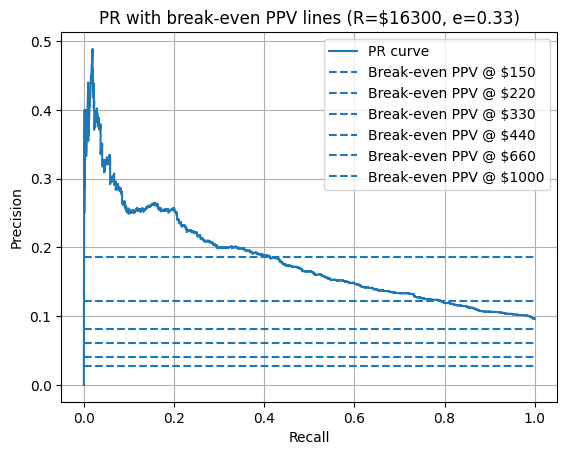

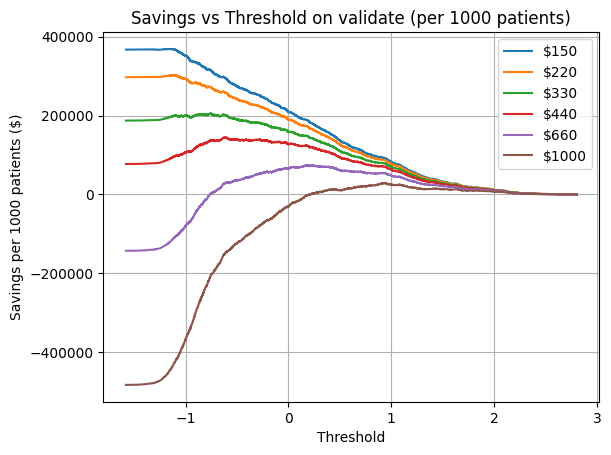

[COST] Chosen threshold: -0.7515 | PPV=0.124  Recall=0.786  FlagRate=0.609  Savings@$330=205.49 per patient
ROC_AUC:     0.6370645377239829
Accuracy:      0.43196121789419967
F1 score:      0.20610959229763462
Precision:     0.11929003852504128
Recall:        0.7572052401746725

Confusion matrix:

TN: 4212, FP: 6401, FN: 278, TP: 867

Classification report:
               precision    recall  f1-score   support

           0       0.94      0.40      0.56     10613
           1       0.12      0.76      0.21      1145

    accuracy                           0.43     11758
   macro avg       0.53      0.58      0.38     11758
weighted avg       0.86      0.43      0.52     11758



In [36]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    svc_pipe.test(
        use_f2_threshold=False,
        show_duration_info=False,
        show_plot=True,
        use_cost_threshold=True,
        R=R,
        e=e,
        c_m_list=m_cost_list,
        prefer_c_m=COST_PREF,
        use_local_model=True,
        C=2.3973382079286494,
        gamma=.001
    )
else:
    svc_pipe.test(
        use_f2_threshold=False,
        show_duration_info=False,
        show_plot=True,
        use_cost_threshold=True,
        R=R,
        e=e,
        c_m_list=m_cost_list,
        prefer_c_m=COST_PREF,
    )

## Extreme Gradient Boosting

XGBoost was chosen after previous studies had found it to be the best performing model of their tested sets.

In [37]:
xgb_pipe = ModelPipeline(
    model='xgb',
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    log=UPDATE_DATABASE,
    plot_y_dist=False,
    create_interactions=False,
    log_transform_cols=np.array([]),
    use_pca=PCA,
    scaler=None,
    one_hot_ordinal=False,
    resample=False # handled by hyperparameters
)

In [38]:
if GET_BASELINE:
    xgb_pipe.run_baseline()

In [39]:
if SHOW_FEAT_IMPORTANCE:
    xgb_pipe.permute_importance()

In [40]:
if not USE_PRE_COMPUTED_HYPERPARAMS:
    param_dist = {
        'model__max_depth': [3,4,5],
        'model__min_child_weight': [1,2,4],
        'model__subsample': [0.6,0.8,1.0],
        'model__colsample_bytree': [0.6,0.8,1.0],
        'model__gamma': [0,1,3],
        'model__learning_rate': [0.02, 0.05, 0.1],
        'model__scale_pos_weight': [1,2,4,6,8,10]
    }

    xgb_pipe.run_hyperparam_search(
        hyperparam_dist=param_dist
    )

In [41]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    xgb_pipe.validate(
        use_local_model=True,
        subsample=0.6,
        scale_pos_weight=4,
        min_child_weight=2,
        max_depth=3,
        learning_rate = 0.1,
        gamma = 0,
        colsample_bytree=0.8
    )
else:
    xgb_pipe.validate()

Held out validation metrics: xgb
ROC_AUC:     0.6617174162186564
Accuracy:      0.8732789393166752
F1 score:      0.20309994655264565
Precision:     0.25675675675675674
Recall:        0.16799292661361626

Confusion matrix:

TN: 10085, FP: 550, FN: 941, TP: 190

Classification report:
               precision    recall  f1-score   support

           0       0.91      0.95      0.93     10635
           1       0.26      0.17      0.20      1131

    accuracy                           0.87     11766
   macro avg       0.59      0.56      0.57     11766
weighted avg       0.85      0.87      0.86     11766



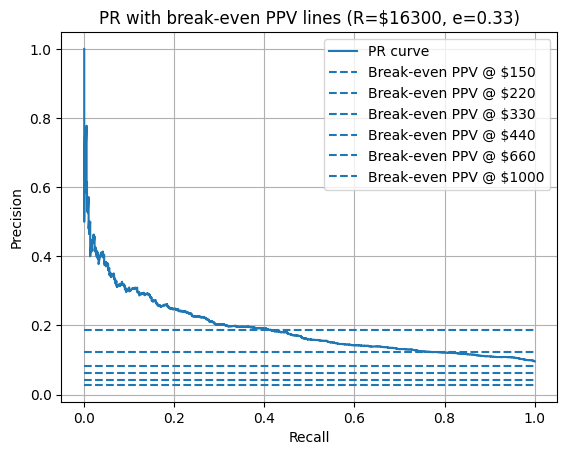

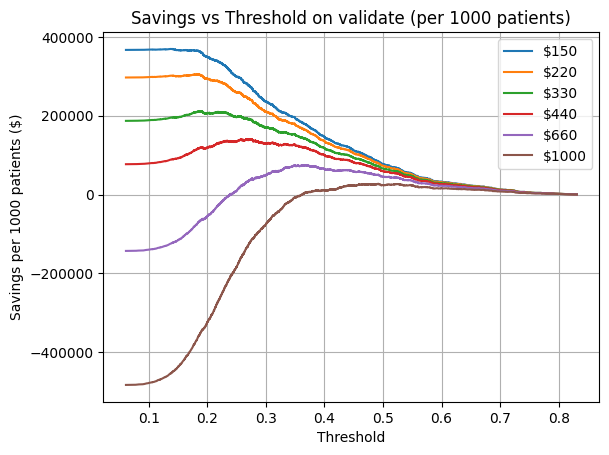

[COST] Chosen threshold: 0.1875 | PPV=0.108  Recall=0.946  FlagRate=0.841  Savings@$330=211.67 per patient
ROC_AUC:     0.650354615765373
Accuracy:      0.24357883993876508
F1 score:      0.19321480406386066
Precision:     0.10780443364713027
Recall:        0.9301310043668122

Confusion matrix:

TN: 1799, FP: 8814, FN: 80, TP: 1065

Classification report:
               precision    recall  f1-score   support

           0       0.96      0.17      0.29     10613
           1       0.11      0.93      0.19      1145

    accuracy                           0.24     11758
   macro avg       0.53      0.55      0.24     11758
weighted avg       0.87      0.24      0.28     11758



In [42]:
if USE_PRE_COMPUTED_HYPERPARAMS:
    xgb_pipe.test(
        use_f2_threshold=False,
        show_duration_info=False,
        show_plot=True,
        use_cost_threshold=True,
        R=R,
        e=e,
        c_m_list=m_cost_list,
        prefer_c_m=COST_PREF,
        use_local_model=True,
        subsample=0.6,
        scale_pos_weight=4,
        min_child_weight=2,
        max_depth=3,
        learning_rate = 0.1,
        gamma = 0,
        colsample_bytree=0.8
    )

else:

    xgb_pipe.test(
        use_f2_threshold=False,
        show_duration_info=False,
        show_plot=True,
        use_local_model=False,
        use_cost_threshold=True,
        R=R,
        e=e,
        c_m_list=m_cost_list,
        prefer_c_m=COST_PREF,
    )

# Results Comparison

Here we compare the metrics between runs.

Data was logged for each run to a database, dumped to a csv and is included in the pip package

In [52]:
import pandas as pd
from shared_util.pd_util import filter_df
from shared_util.dataio import load_csv
# use exported csv not database to get metrics in the collab notebook


metrics_df = load_csv('metrics').reset_index()
#display(metrics_df.head(5))

test_df = filter_df(metrics_df, data=['test'])
most_recent_df = filter_df(metrics_df, run_id=[METRICS_DB_ID])
filter_df(most_recent_df, data='test').head(5)

,id,run_id,model,data,threshold_notes,pipeline_notes,hyperparam_notes,notes,roc_auc,accuracy,precision,recall,f1,tn,tp,fp,fn,est_pp_savings,created_at
77,335,19,xgb,test,cost_opt_R=16300_e=0.33_c=330,under_sample,tuned_best_roc_auc,Remove dummy ref drop,0.650355,0.243579,0.107804,0.930131,0.193215,1799.0,1065.0,8814.0,80.0,211.670066,2025-11-17 18:03:18.704125
100,329,19,rf,test,cost_opt_R=16300_e=0.33_c=330,under_sample,tuned_best_roc_auc,Remove dummy ref drop,0.641919,0.203011,0.103834,0.941485,0.187039,1309.0,1078.0,9304.0,67.0,206.501020,2025-11-17 18:01:57.280120
145,323,19,lr,test,cost_opt_R=16300_e=0.33_c=330,under_sample,tuned_best_roc_auc,Remove dummy ref drop,0.639678,0.303283,0.109844,0.866376,0.194969,2574.0,992.0,8039.0,153.0,208.500765,2025-11-17 18:01:24.965957
149,331,19,sgd,test,cost_opt_R=16300_e=0.33_c=330,under_sample,tuned_best_roc_auc,Remove dummy ref drop,0.639107,0.280830,0.108493,0.884716,0.193284,2289.0,1013.0,8324.0,132.0,208.211882,2025-11-17 18:02:31.052447
156,333,19,svc,test,cost_opt_R=16300_e=0.33_c=330,under_sample,tuned_best_roc_auc,Remove dummy ref drop,0.637065,0.431961,0.119290,0.757205,0.206110,4212.0,867.0,6401.0,278.0,205.491331,2025-11-17 18:03:14.462329


## Comparing Models

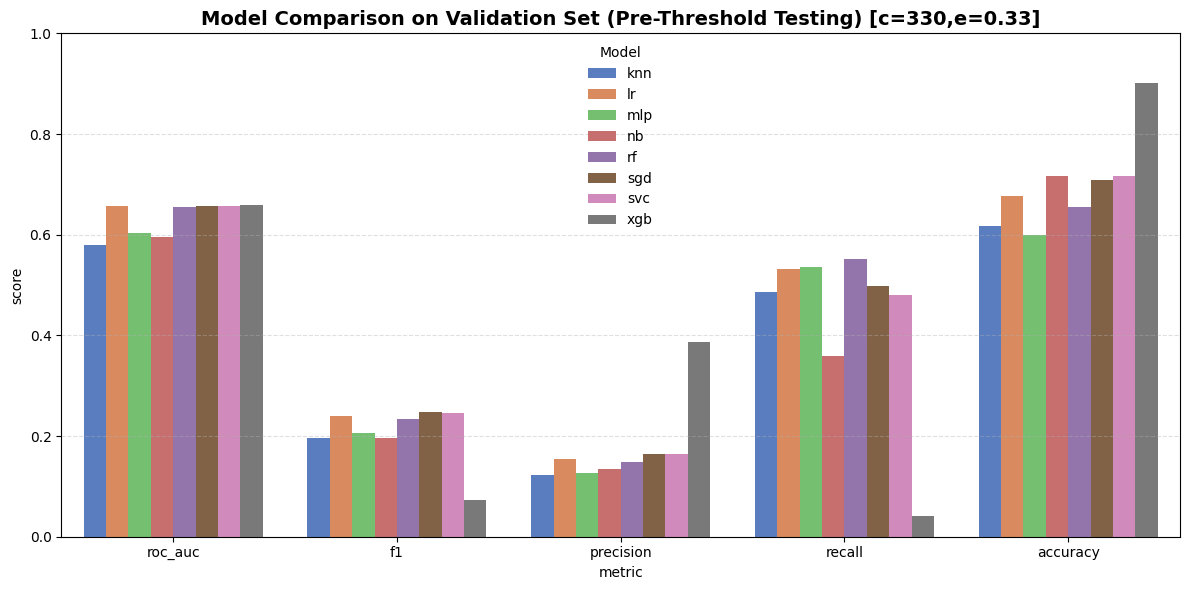

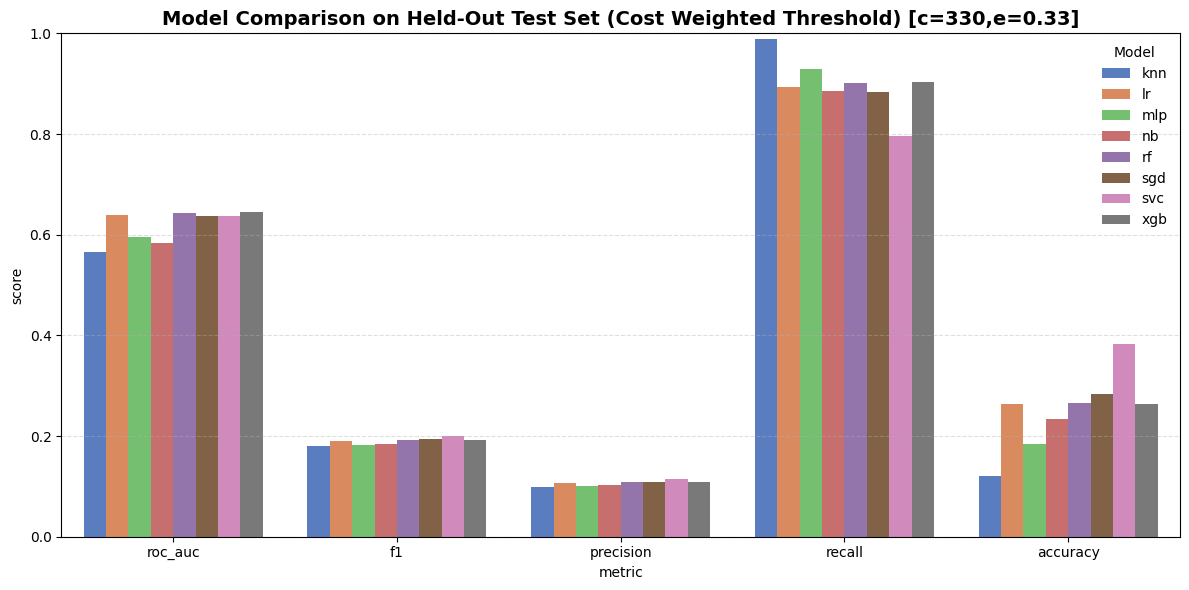

In [65]:
from shared_util.metrics.printing import summary_by
from shared_util.metrics.plotting import plot_metrics

plot_metrics(most_recent_df, METRICS_DB_ID, 'c=330,e=0.33', palette='muted')

In [ ]:
print('--most recent--')


summary_by(most_recent_df, col='roc_auc')
summary_by(most_recent_df, col='recall')
summary_by(most_recent_df, col='precision')
summary_by(most_recent_df, col='est_pp_savings')
summary_by(most_recent_df, col='accuracy')

--most recent--
Models by roc_auc


,model,roc_auc
204,xgb,0.676
198,rf,0.675
202,svc,0.674
208,lr,0.671
200,sgd,0.669
212,mlp,0.606
196,nb,0.606
192,knn,0.600


Models by recall


,model,recall
212,mlp,0.977
196,nb,0.960
198,rf,0.950
204,xgb,0.950
202,svc,0.945
192,knn,0.941
208,lr,0.924
200,sgd,0.920


Models by precision


,model,precision
200,sgd,0.107
202,svc,0.106
208,lr,0.105
204,xgb,0.105
198,rf,0.105
192,knn,0.103
196,nb,0.099
212,mlp,0.099


Models by est_pp_savings


,model,est_pp_savings
200,sgd,231.760
208,lr,230.956
198,rf,226.859
202,svc,226.829
204,xgb,225.353
196,nb,221.460
192,knn,220.373
212,mlp,217.885


Models by accuracy


,model,accuracy
200,sgd,0.244
208,lr,0.231
202,svc,0.217
204,xgb,0.209
198,rf,0.207
192,knn,0.198
196,nb,0.150
212,mlp,0.129


Average ROC_AUC between validate and test splits

In [ ]:
_test_val = filter_df(most_recent_df, data=['test', 'validate']).groupby(by='model', as_index=False)['roc_auc'].mean()

_test_val.sort_values(by='roc_auc', ascending=False) #type: ignore

## Comparing Different Runs

We can compare the metrics precision, f1, accuracy, recall between different runs given that we set the input variabels (c_m and e)

This shows how the predictions change by adjusting the input costs.

In [ ]:
from shared_util.pd_util import filter_df

results_df = filter_df(test_df, model=['xgb', 'svc', 'sgd', 'rf'], run_id=[12, 13, 14,15, 16])

run_notes = pd.DataFrame({
    "run_id": [12, 13, 14, 15, 16],
    "label": ['c=440,e=0.50','c=440,e=0.25','c=330,e=0.25','c=330,e=0.45', 'c=330,e=0.33']
})

df_means = results_df.groupby('run_id', as_index=False).mean(numeric_only=True)

df_label = df_means.merge(run_notes, on='run_id', how='left')



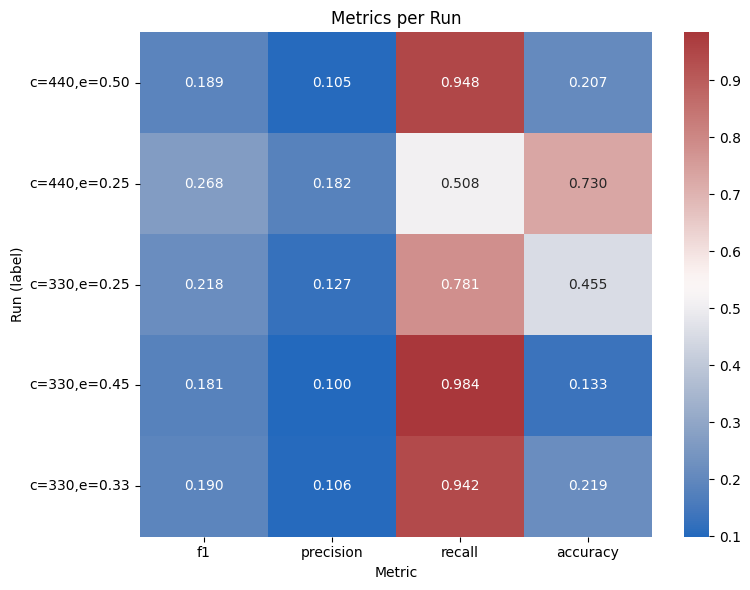

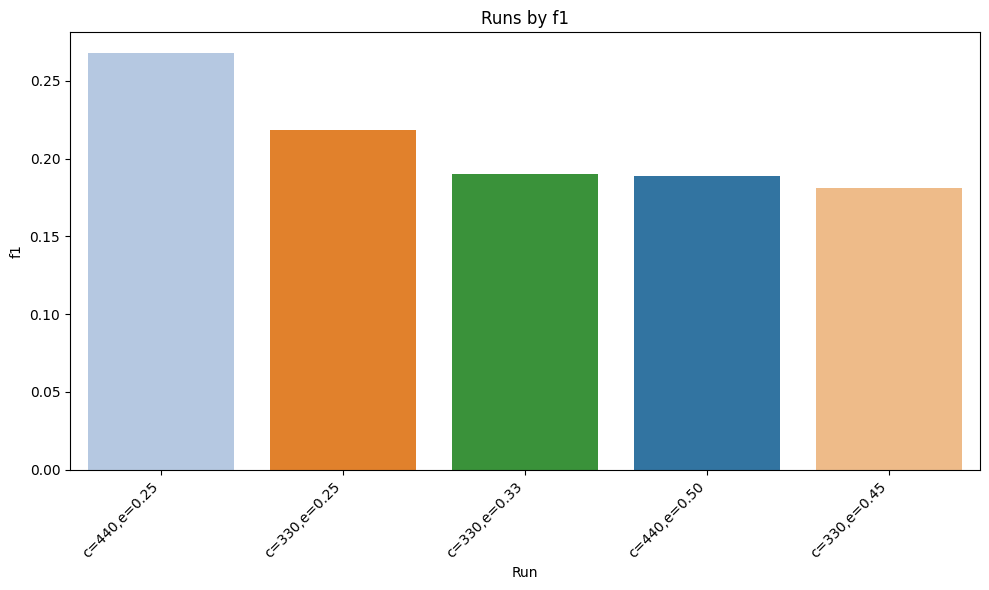

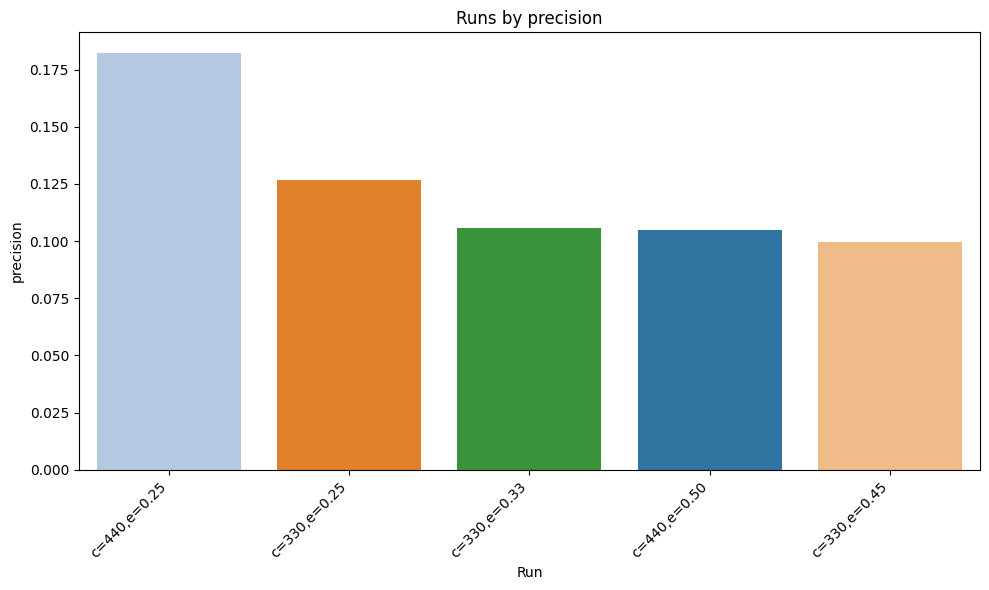

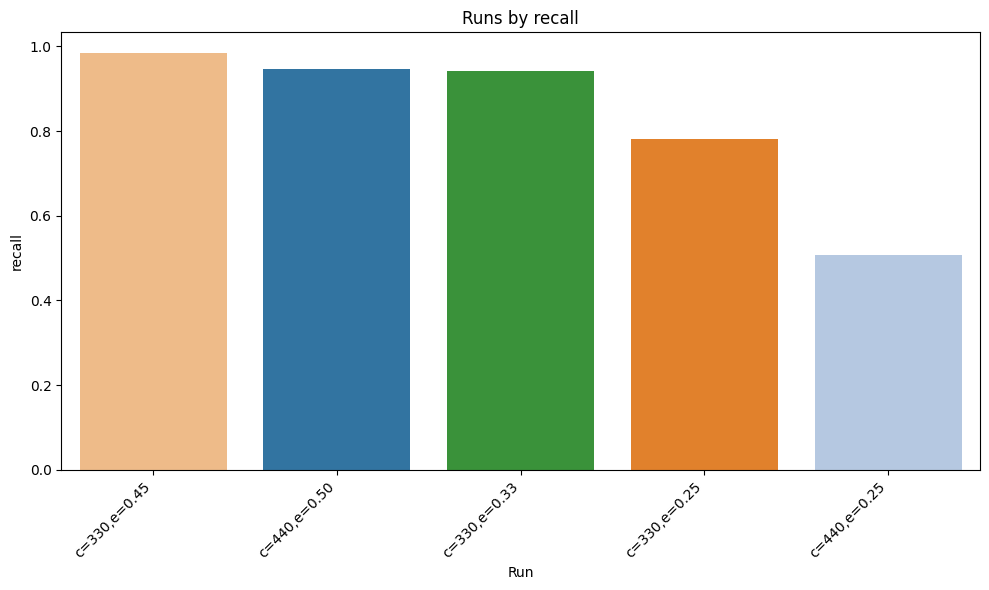

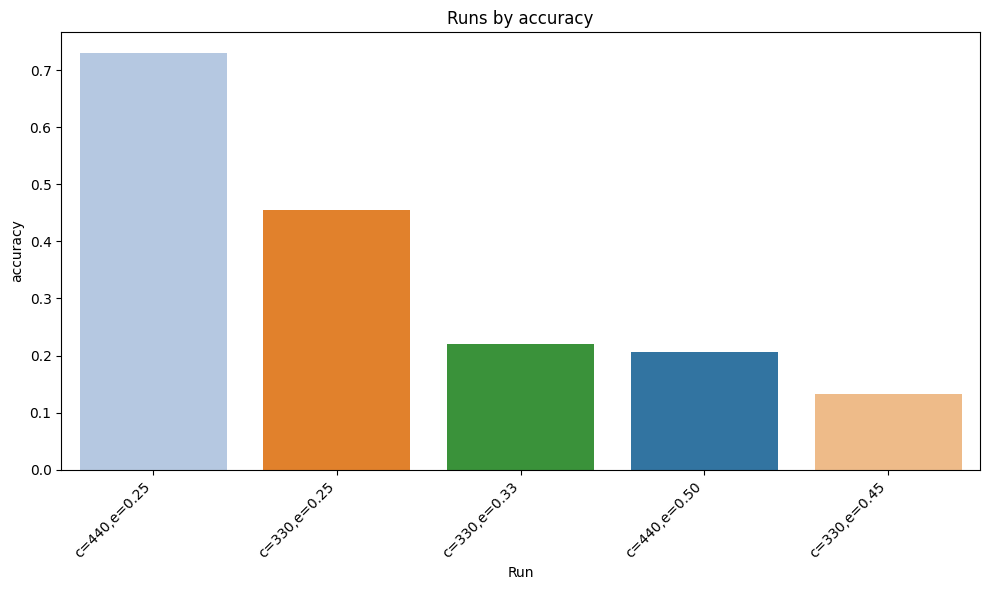

In [ ]:
from shared_util.metrics.compare import plot_compare

plot_compare(
    df=df_label,
    metric_cols=["f1", "precision", "recall", "accuracy"],
    h_cmap='vlag',
    base_palette='tab20'
)

In [ ]:
from shared_util.metrics.compare import print_run_compare

print_run_compare(
    df=df_label,
    metric_cols=["roc_auc", "f1", "precision", "recall", "accuracy"]
)


=== Overall ranking (by rank_sum -> overall_score) ===


,run_id,label,overall_score,rank_sum,roc_auc,f1,precision,recall,accuracy
0,13,"c=440,e=0.25",0.750,9.0,0.673558,0.267766,0.182189,0.508036,0.729728
1,14,"c=330,e=0.25",0.625,11.0,0.673558,0.218237,0.126919,0.780843,0.455317
2,16,"c=330,e=0.33",0.500,13.0,0.673558,0.190005,0.105668,0.941573,0.219444
3,12,"c=440,e=0.50",0.375,15.0,0.673558,0.188653,0.104769,0.947654,0.207028
4,15,"c=330,e=0.45",0.250,17.0,0.673558,0.180886,0.099597,0.984144,0.133352



=== Top 5 by roc_auc ===


,run_id,label,roc_auc
0,13,"c=440,e=0.25",0.673558
1,14,"c=330,e=0.25",0.673558
2,16,"c=330,e=0.33",0.673558
3,12,"c=440,e=0.50",0.673558
4,15,"c=330,e=0.45",0.673558



=== Top 5 by f1 ===


...

,run_id,label,precision
0,13,"c=440,e=0.25",0.182189
1,14,"c=330,e=0.25",0.126919
2,16,"c=330,e=0.33",0.105668
3,12,"c=440,e=0.50",0.104769
4,15,"c=330,e=0.45",0.099597



=== Top 5 by recall ===


,run_id,label,recall
4,15,"c=330,e=0.45",0.984144
3,12,"c=440,e=0.50",0.947654
2,16,"c=330,e=0.33",0.941573
1,14,"c=330,e=0.25",0.780843
0,13,"c=440,e=0.25",0.508036



=== Top 5 by accuracy ===


,run_id,label,accuracy
0,13,"c=440,e=0.25",0.729728
1,14,"c=330,e=0.25",0.455317
2,16,"c=330,e=0.33",0.219444
3,12,"c=440,e=0.50",0.207028
4,15,"c=330,e=0.45",0.133352



=== Overall ranking (by rank_sum -> overall_score) ===


,run_id,label,overall_score,rank_sum,roc_auc,f1,precision,recall,accuracy
0,18,weight-encoded,0.6,7.0,0.618341,0.189463,0.106017,0.897707,0.249373
1,17,weight dropped,0.4,8.0,0.647218,0.186801,0.103652,0.946025,0.198317



=== Top 2 by roc_auc ===


,run_id,label,roc_auc
1,17,weight dropped,0.647218
0,18,weight-encoded,0.618341



=== Top 2 by f1 ===


...

,run_id,label,precision
0,18,weight-encoded,0.106017
1,17,weight dropped,0.103652



=== Top 2 by recall ===


,run_id,label,recall
1,17,weight dropped,0.946025
0,18,weight-encoded,0.897707



=== Top 2 by accuracy ===


,run_id,label,accuracy
0,18,weight-encoded,0.249373
1,17,weight dropped,0.198317


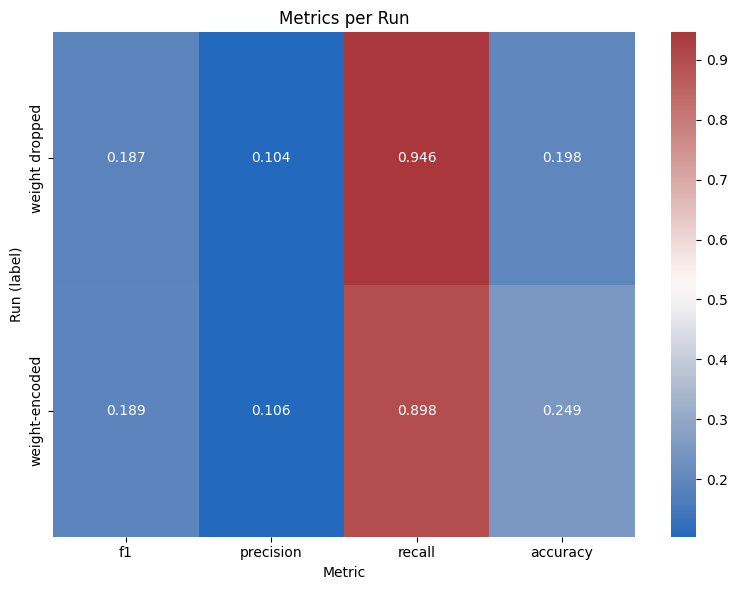

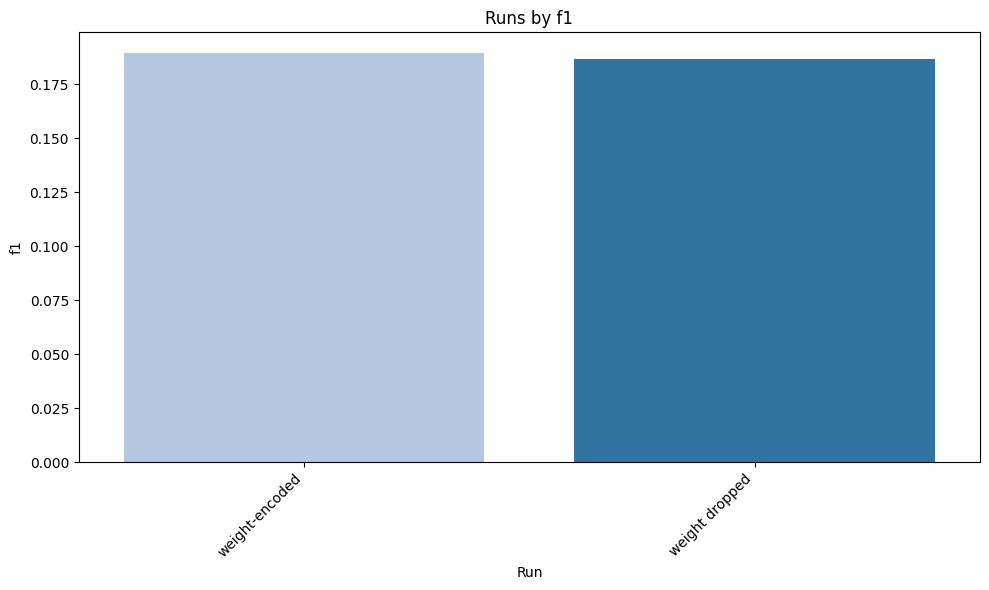

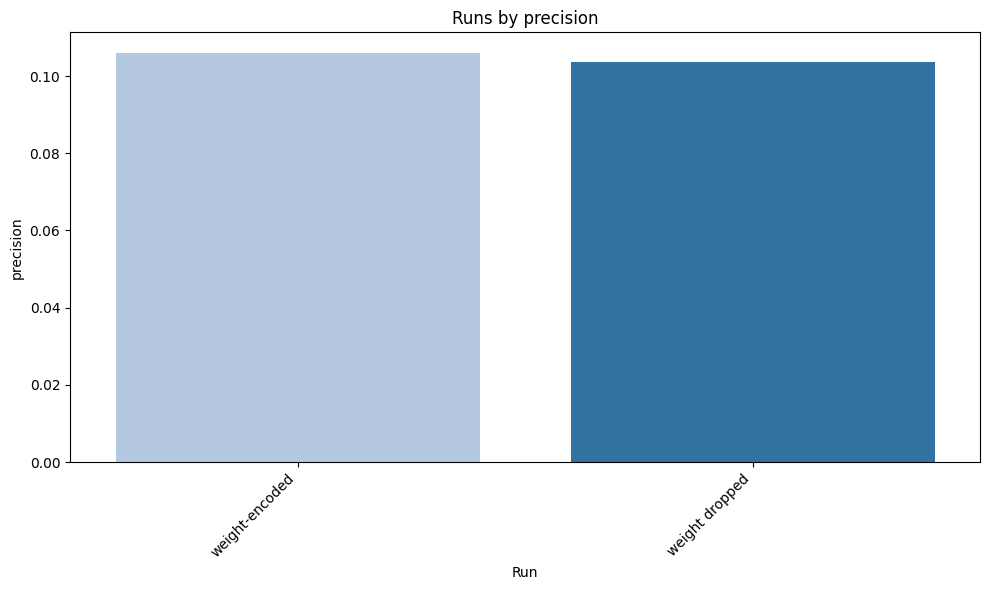

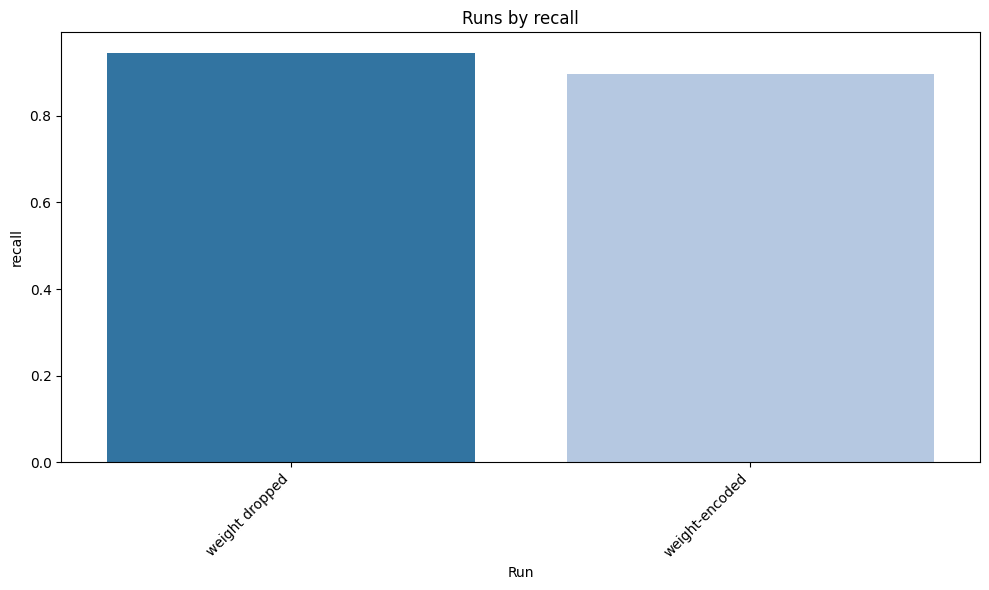

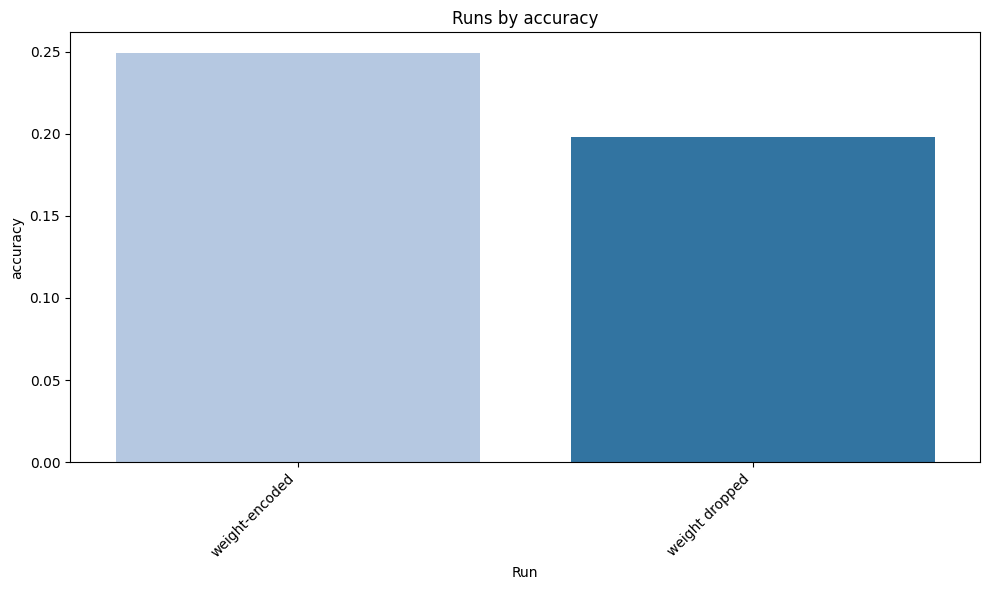

In [67]:
from shared_util.pd_util import filter_df

weight_test = filter_df(test_df, run_id=[17,18])

run_notes = pd.DataFrame({
    "run_id": [17,18],
    "label": ['weight dropped','weight-encoded']
})

df_means_w = weight_test.groupby('run_id', as_index=False).mean(numeric_only=True)

df_label_w = df_means_w.merge(run_notes, on='run_id', how='left')

from shared_util.metrics.compare import print_run_compare

print_run_compare(
    df= df_label_w,
    metric_cols=["roc_auc", "f1", "precision", "recall", "accuracy"]
)
from shared_util.metrics.compare import plot_compare

plot_compare(
    df=df_label_w,
    metric_cols=["f1", "precision", "recall", "accuracy"],
    h_cmap='vlag',
    base_palette='tab20'
)

### Compare runs manually

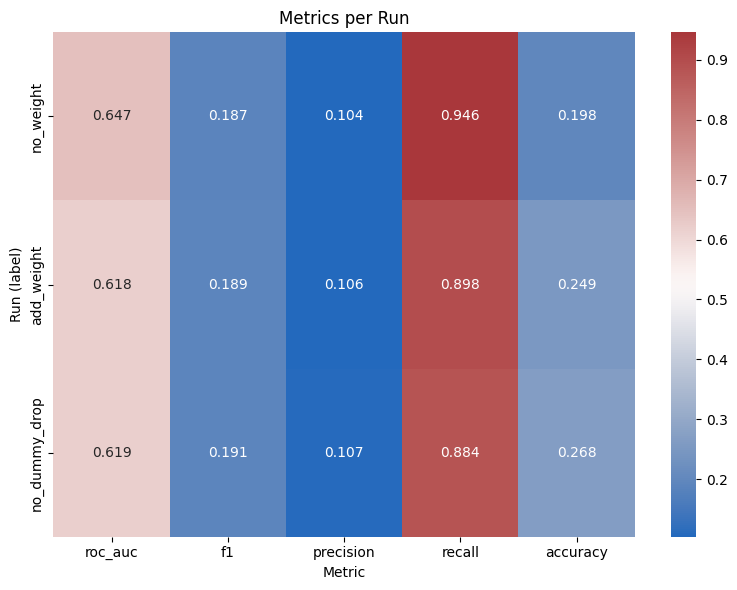

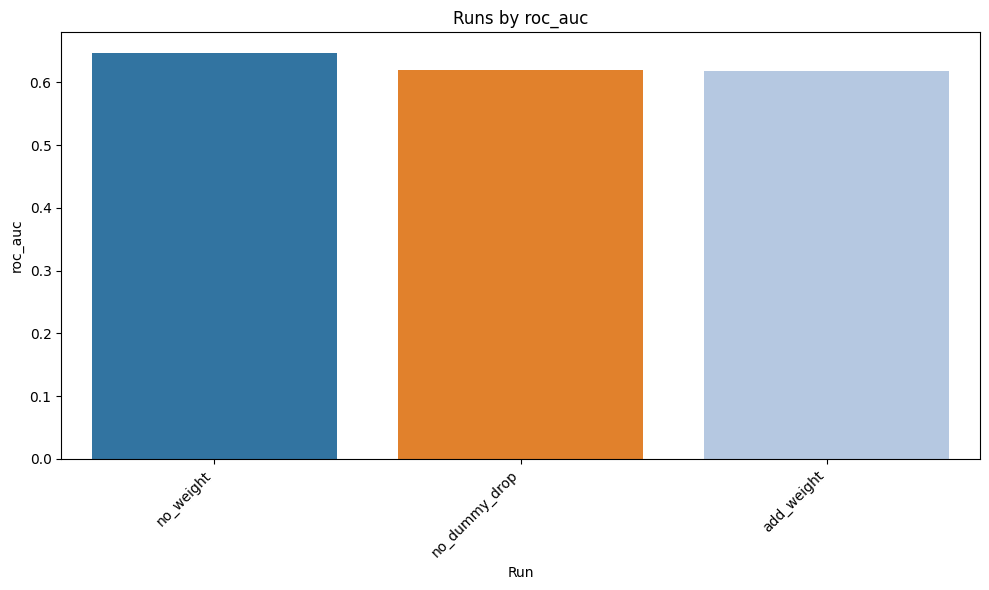

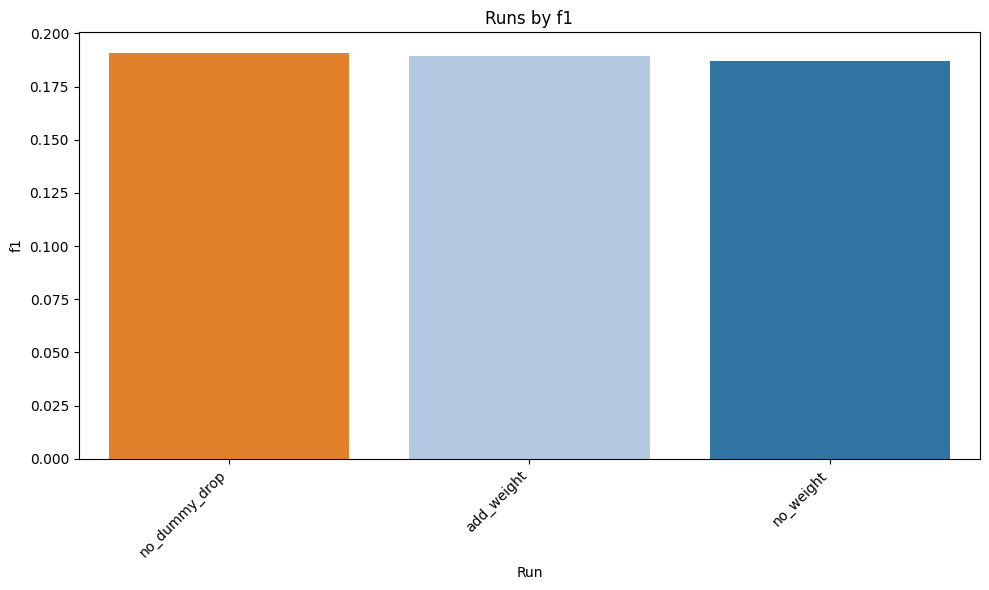

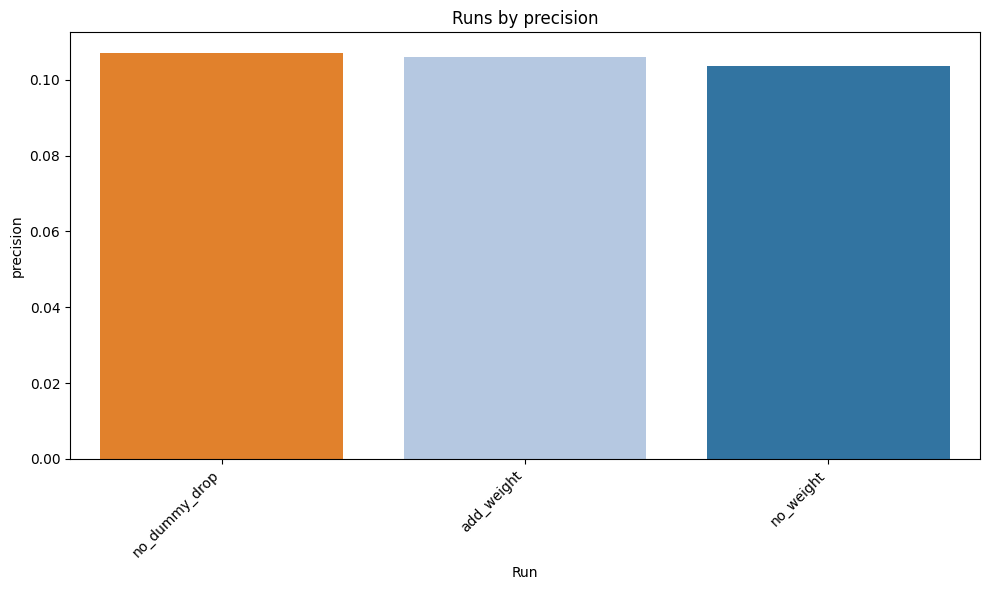

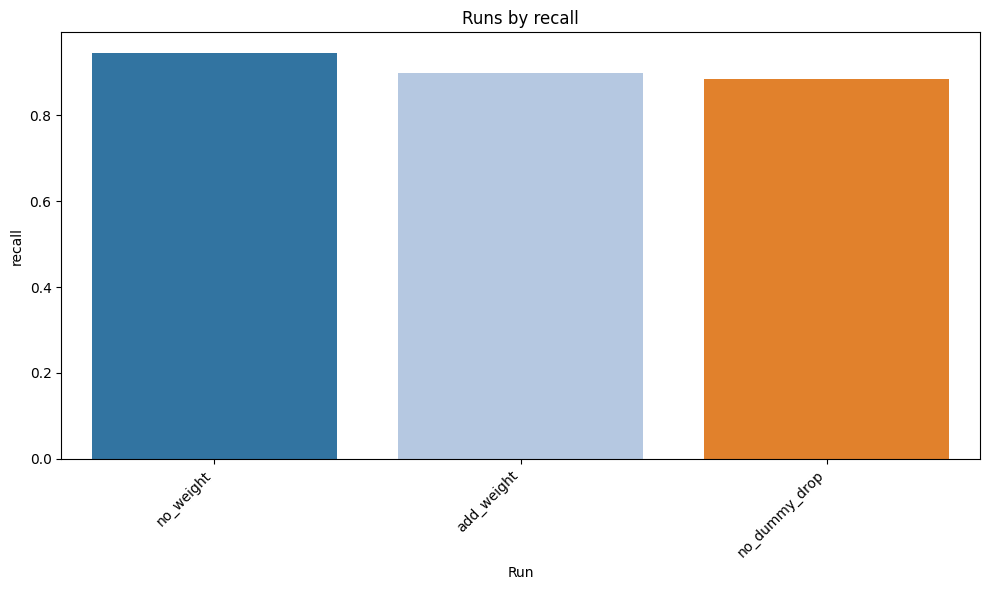

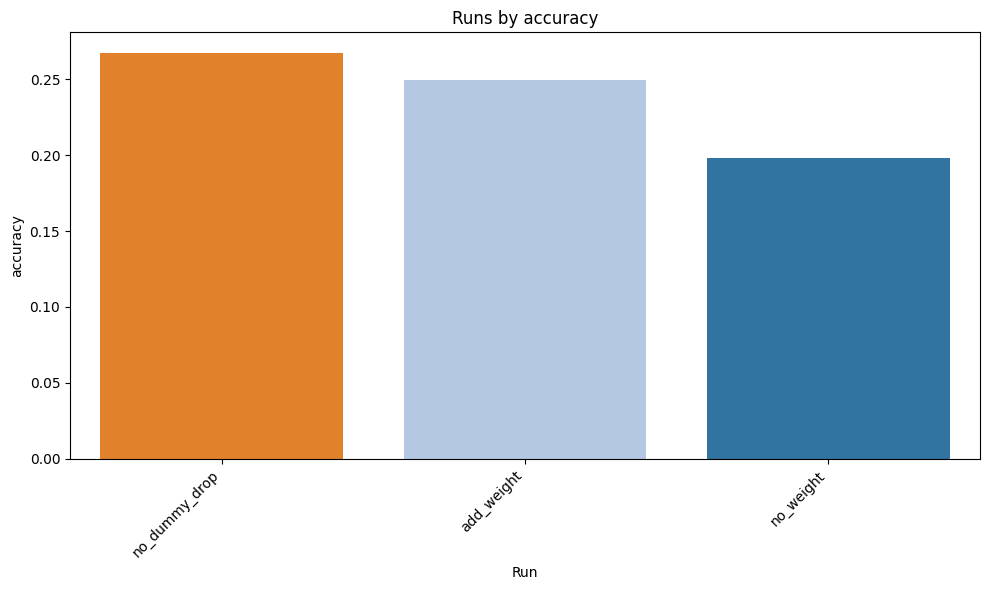

In [55]:
from shared_util.pd_util import filter_df

results_df2 = filter_df(test_df, run_id=[17,18,19])

run_notes2 = pd.DataFrame({
    "run_id": [17,18,19],
    "label": ['no_weight', 'add_weight', 'no_dummy_drop']
})

df_means2 = results_df2.groupby('run_id', as_index=False).mean(numeric_only=True)

df_label2 = df_means2.merge(run_notes2, on='run_id', how='left')

from shared_util.metrics.compare import plot_compare

plot_compare(
    df=df_label2,
    metric_cols=['roc_auc', "f1", "precision", "recall", "accuracy"],
    h_cmap='vlag',
    base_palette='tab20'
)

# Code Reference

### Modeling Pipeline


In [ ]:
import numpy as np
import pandas as pd
from typing import Dict, List, Any
import time
MODELS = ['rf', 'svc', 'sgd', 'xgb', 'nb', 'knn', 'lr', 'mlp']

class ModelPipeline:
    """
    Represents a pipeline to test a model

    Contains setup in a constructor including reading data in and splitting test,val,train sets

    Contains class methods for the following:
        Perumation Importance of Features + graphing
        Baseline testing SMOTE vs Random Undersampling
        Hyperparameter sweeping with desired parameter distribution
        Validation using best estimator from sweep, with optional f2 score calculation
        Test using held out test data using either base threshold of f2 weighted score

        Printing metrics of each step ROC_AUC, prec, acc, recall, confusion matrics, classification report

        Baseline is tested in 5 fold cross validation

        Hyperparam tuning is done using RandomizedSearch with 5 folds

        All data is grouped by patient_nbr to handle duplicate patient encounters
    """



    class PreprocessorSettings:
        """
        Holds information about preprocessor settings for this pipeline

        Contains factory() to create a new preprocesser with the set settings as needed
        """
        create_interactions: bool = True
        log_transform_cols: np.ndarray | None
        one_hot_ordinal: bool = True

        def __init__(self,
                     create_interactions=True,
                     log_transform_cols=None,
                     one_hot_ordinal=True
                     ) -> None:
            self.create_interactions = create_interactions
            self.log_transform_cols = log_transform_cols
            self.one_hot_ordinal = one_hot_ordinal


        def factory(self):
            from shared_util.pipelines.cleaning import CleaningPipeline
            return CleaningPipeline(
                create_interactions=self.create_interactions,
                log_transform_cols=self.log_transform_cols
                )


    LOG: bool = False
    METRICS_DB_ID: int = 0
    METRIC_NOTES: str = "None"
    data_path: str = "cleaned"
    X_train: Any = None
    X_validate: Any | None = None
    X_test: Any | None = None
    y_train: Any | None = None
    y_validate: Any | None = None
    y_test: Any | None = None
    preprocessor_settings: PreprocessorSettings
    model:str = ""
    random_state: int = 42
    scaler: Any | None = None
    hyperparam_dist: Dict[str, Any]
    tuned: bool = False
    validated: bool = False
    param_scoring:str='roc_auc'
    use_pca: bool = False
    resample: bool = True





    def __init__(self,
                 *
                 ,
                 log: bool = False,
                 metrics_db_id: int = 0,
                 metrics_notes: str = "None",
                 data_path: str = "cleaned",
                 plot_y_dist: bool = True,
                 random_state: int = 42,
                 create_interactions: bool = True,
                 log_transform_cols: np.ndarray | None = None,
                 model: str = 'rf',
                 scaler: str | None = None, # standard, power
                 group_by_col='patient_nbr',
                 use_pca: bool = False,
                 one_hot_ordinal: bool = True,
                 resample: bool = True
                 ) -> None:
        """
        Create a new pipeline
        """
        # Persist runtime configuration so we can trace every experiment.
        self.LOG = log
        self.METRIC_NOTES = metrics_notes
        self.data_path = data_path
        self.METRICS_DB_ID = metrics_db_id
        self.random_state = random_state
        self.group_by_col = group_by_col
        self.use_pca = use_pca
        self.resample = resample
        # Lazily attach a scaler because only some models benefit from it.
        if scaler == 'standard':
            from sklearn.preprocessing import StandardScaler
            self.scaler = StandardScaler()
        if scaler == 'power':
            from sklearn.preprocessing import PowerTransformer
            self.scaler = PowerTransformer(method='yeo-johnson', standardize=True)

        # Load the requested dataset and perform the grouped train/validate/test split.
        from shared_util.dataio import load_csv
        from shared_util.split import group_split
        _df = load_csv(data_path)

        self.X_train, self.X_validate, self.X_test, self.y_train, self.y_validate, self.y_test = group_split(_df)


        if plot_y_dist:
            # Quick sanity check: make sure the target distribution is stable across splits.
            from shared_util.metrics.plotting import check_y_dist
            check_y_dist(
                self.y_train,
                self.y_validate,
                self.y_test
            )

        # Freeze preprocessing options inside a helper so we can rebuild identical cleaners on demand.
        self.preprocessor_settings = self.PreprocessorSettings(
            create_interactions=create_interactions,
            log_transform_cols=log_transform_cols,
            one_hot_ordinal=one_hot_ordinal
        )


        self.model = model

    def permute_importance(self, print_num=15, plot=True,show_duration_info:bool = True,):
        from sklearn.inspection import permutation_importance
        t0 = time.perf_counter()

        print(f"----------Running Feature Importance for model: {self.model}----------")

        def plot_feature_importance(df, col1, col2, size, title):
            import matplotlib.pyplot as plt
            plt.figure(figsize=(10,6))
            plt.barh(df[col1][:size][::-1], df[col2][:size][::-1])
            plt.title(title)
            plt.xlabel("Importance")
            plt.tight_layout()
            plt.show()

        def _transform_through_inference_steps(pipe, X, model_step='model'):
            """
            Apply only transform-capable steps in a fitted imblearn Pipeline.
            Skip any sampler (fit_resample-only). Stop before the final estimator.
            """
            Xt = X
            for name, step in pipe.steps:
                if name == model_step:
                    break
                # Skip samplers (no transform)
                if hasattr(step, "fit_resample"):
                    continue
                if hasattr(step, "transform"):
                    Xt = step.transform(Xt)
                else:
                    pass
            return Xt


        def cv_permutation_importance(
            pipe_factory, X, y, cv, groups=None,
            scoring="roc_auc", n_repeats=10, n_jobs=-1, random_state=42,
            model_step='model', prep_step='preprocessor'
        ):
            # Compute permutation importance fold by fold so samplers respect the group structure.
            perm_means = []
            feat_names = None

            for tr_idx, va_idx in cv.split(X, y, groups):
                X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
                X_va, y_va = X.iloc[va_idx], y.iloc[va_idx]

                # Rebuild a fresh pipeline each iteration to avoid cross-fold leakage.
                pipe = pipe_factory(self.model)
                pipe.fit(X_tr, y_tr)

                # Transform validation through inference-capable steps
                Xt_va = _transform_through_inference_steps(pipe, X_va, model_step=model_step)

                # Get names from the preprocessor if available; otherwise fallback
                preproc = pipe.named_steps.get(prep_step)
                if hasattr(preproc, "get_feature_names_out"):
                    feat_names_fold = np.asarray(preproc.get_feature_names_out(), dtype=object)
                else:
                    feat_names_fold = np.array([f"x{i}" for i in range(Xt_va.shape[1])], dtype=object)

                if feat_names is None:
                    feat_names = feat_names_fold
                else:
                    if len(feat_names) != len(feat_names_fold):
                        raise RuntimeError("Transformed feature count changed across folds; pipeline not schema-stable.")

                model = pipe.named_steps[model_step]

                # Measure how sensitive the fitted model is to each feature on this fold.
                r = permutation_importance(
                    model, Xt_va, y_va,
                    scoring=scoring, n_repeats=n_repeats,
                    n_jobs=n_jobs, random_state=random_state
                )
                perm_means.append(r.importances_mean) #type: ignore

            arr = np.vstack(perm_means)
            df = pd.DataFrame({
                "feature": feat_names,
                "importance_mean": arr.mean(axis=0),
                "importance_std": arr.std(axis=0)
            }).sort_values("importance_mean", ascending=False)
            return df

        # Aggregate the per-fold importances into a single ranked table.
        _perm_imp = cv_permutation_importance(
            pipe_factory=self._pipe_factory,
            X=self.X_train,
            y=self.y_train,
            cv=self._make_group_cv(),
            groups=self.X_train[self.group_by_col]
        )

        from IPython.display import display

        display(_perm_imp.head(print_num))

        if plot:
            plot_feature_importance(
                _perm_imp,
                'feature',
                'importance_mean',
                print_num,
                f'Permutation Importance ({self.model})')

        if show_duration_info:
            self._print_dur(t0)

    def test(self,
         use_f2_threshold=False,
         use_cost_threshold=True,
         R: float = 16300.0,
         e: float = 0.33,
         c_m_list=(500.0, 1000.0, 1500.0),
         prefer_c_m: float | None = 330.0,
         show_plot=True,
         show_duration_info: bool = False,
         use_local_model=False,
         **kwargs):
        """
        New: use_cost_threshold selects threshold maximizing $ savings on the validate set.
        - Overlays: PR curve with break-even PPV lines, and savings vs threshold per c_m.
        - If both use_f2_threshold and use_cost_threshold are True, cost wins. Because money.
        """
        if (not self.validated or not self.tuned) and not use_local_model:
            raise EnvironmentError("Must validate before test")

        import time
        import numpy as np
        from shared_util.metrics.scoring import (
            get_scores,
            cost_curves_from_scores, best_threshold_by_cost
        )
        from shared_util.metrics.plotting import plot_pr_with_break_even, plot_savings_vs_threshold
        from shared_util.metrics.printing import print_metrics

        # Fit or load model
        if use_local_model:
            _model = self._pipe_factory(
                model=self.model,
                random_state=self.random_state,
                sampler='under',
                **kwargs
            )
            _model.fit(self.X_train, self.y_train)
        else:
            _model = self.randomized_search.best_estimator_

        t0 = time.perf_counter()

        # 1) Scores on validate for threshold selection
        _val_scores = get_scores(_model, self.X_validate)

        threshold_notes = 'baseline'
        chosen_thresh = None
        est_pp_savings = 0.0

        # Build cost curves on validate
        curves = cost_curves_from_scores(
            y_true=self.y_validate,
            y_scores=_val_scores,
            R=R, e=e, c_m_list=c_m_list
        )
        choice = best_threshold_by_cost(curves, prefer_c_m=prefer_c_m)

        chosen_thresh = choice["threshold"]
        threshold_notes = f'cost_opt_R={int(R)}_e={e:.2f}_c={("avg" if choice["chosen_c_m"] is None else int(choice["chosen_c_m"]))}'

        if choice["chosen_c_m"] is None:
            # maximizing average across c_m_list
            est_pp_savings = float(np.mean(list(choice["savings_at_c"].values())))
        else:
            # using a specific c_m
            est_pp_savings = float(choice["savings_at_c"][choice["chosen_c_m"]])

        # Optional overlays
        if show_plot:
            title = f"PR with break-even PPV lines (R=${int(R)}, e={e:.2f})"
            plot_pr_with_break_even(curves, R=R, e=e, c_m_list=c_m_list, title=title)

            title2 = f"Savings vs Threshold on validate (per 1000 patients)"
            plot_savings_vs_threshold(curves, c_m_list=c_m_list, per_1000=True, title=title2)


        print(
            f"[COST] Chosen threshold: {chosen_thresh:.4f} | "
            f"PPV={choice['precision']:.3f}  Recall={choice['recall']:.3f}  "
            f"FlagRate={choice['flag_rate']:.3f}  "
            f"Savings@{('avg' if choice['chosen_c_m'] is None else '$'+str(int(choice['chosen_c_m'])))}="
            f"{est_pp_savings:.2f} per patient"
        )



        # 2) Apply chosen threshold to test
        _test_scores = get_scores(_model, self.X_test)
        if chosen_thresh is not None:
            y_pred = (_test_scores >= chosen_thresh).astype(int)
        else:
            y_pred = _model.predict(self.X_test)  # type: ignore

        # 3) Print/log test metrics
        from shared_util.metrics.printing import print_metrics
        print_metrics(
            y_true=self.y_test,
            y_pred=y_pred,
            y_proba=_test_scores,
            run_id=self.METRICS_DB_ID,
            metrics_notes=self.METRIC_NOTES,
            data='test',
            threshold_notes=threshold_notes,
            model=self.model,
            hyperparam_notes='tuned_best_roc_auc',
            pipeline_notes='under_sample',
            est_pp_savings=est_pp_savings,
            log=self.LOG
        )

        if show_duration_info:
            self._print_dur(t0)

    def run_full_suite(self,
                        run_baseline: bool = True,
                        run_hyperparam_search: bool = True,
                        baseline_undersample: bool = True,
                        baseline_smote: bool = True,
                        feature_importance: bool = True,
                        show_duration_info:bool = True,
                        feat_num: int = 15,
                        hyperparam_dist: Dict[str, Any] = {},
                        n_iter: int = 30,
                        n_jobs: int = -1,
                        refit: bool = True,
                        verbose: int = 1,
                        prefer_c_m: float | None = 330.0,
                        R: float = 16300.0,
                        e: float = 0.33,
                        c_m_list=(500.0, 1000.0, 1500.0),
                        **kwargs
                       ):

        if run_baseline:
            self.run_baseline(
                run_undersampler=baseline_undersample,
                run_smote=baseline_smote,
                show_duration_info=show_duration_info
            )

        if feature_importance:
            self.permute_importance(
                print_num=feat_num,
                plot=True,
                show_duration_info=show_duration_info
            )

        if run_hyperparam_search:
            self.run_hyperparam_search(
                hyperparam_dist=hyperparam_dist,
                n_iter=n_iter,
                n_jobs=n_jobs,
                refit=refit,
                show_duration_info=show_duration_info,
                verbose=verbose
            )
        self.validate(
            use_local_model=not run_hyperparam_search,
            show_duration_info=show_duration_info,
            **kwargs
        )

        self.test(
            prefer_c_m=prefer_c_m,
            R=R,
            e=e,
            c_m_list=c_m_list,
            use_local_model=not run_hyperparam_search,
            show_duration_info=show_duration_info,
            **kwargs
        )


    def validate(self,
                 show_duration_info:bool = False,
                 use_local_model=False,
                 **kwargs
                 ):
        if not self.tuned and not use_local_model:
            raise EnvironmentError("Must run hyperparam search first")

        from shared_util.metrics.scoring import get_scores
        t0 = time.perf_counter()

        if use_local_model:
            _model = self._pipe_factory(
                model=self.model,
                random_state=self.random_state,
                sampler='under',
                **kwargs
                )
            _model.fit(self.X_train, self.y_train)
        else:
            _model = self.randomized_search.best_estimator_


        y_proba = get_scores(_model, self.X_validate)
        y_pred = _model.predict(self.X_validate) #type: ignore

        print(f"Held out validation metrics: {(self.model)}")

        from shared_util.metrics.printing import print_metrics

        print_metrics(
            y_true=self.y_validate,
            y_pred=y_pred,
            y_proba=y_proba,
            metrics_notes=self.METRIC_NOTES,
            run_id=self.METRICS_DB_ID,
            model=self.model,
            data='validate',
            hyperparam_notes=f'tuned best {(self.param_scoring)}',
            pipeline_notes='under_sample',
            log=self.LOG,

        )

        self.validated = True

        if show_duration_info:
            self._print_dur(t0)

    def run_hyperparam_search(self,
                 hyperparam_dist = {},
                 param_scoring='roc_auc',
                 n_iter = 30,
                 n_jobs = -1,
                 refit=True,
                 show_duration_info=True,
                 verbose=1
                              ):
        t0 = time.perf_counter()
        from sklearn.model_selection import RandomizedSearchCV
        print(f"----------Running hyperparameter search for model: {self.model}----------")
        # Build a full pipeline so tuning evaluates preprocessing, sampling, and the estimator together.
        rs = RandomizedSearchCV(
            estimator=self._pipe_factory(self.model, random_state=self.random_state),
            param_distributions=hyperparam_dist,
            n_iter=n_iter,
            refit=refit,
            random_state=self.random_state,
            n_jobs=n_jobs,
            scoring=param_scoring,
            cv=self._make_group_cv(),
            verbose=verbose
        )

        # Group-aware fit ensures we never leak a patient's encounters across folds.
        rs.fit(
            self.X_train,
            self.y_train,
            groups=self.X_train[self.group_by_col]
        )


        print("Best ROC_AUC (cv):", rs.best_score_)
        print("Best params:", rs.best_params_)

        # Summarize top results
        res_df = pd.DataFrame(rs.cv_results_).sort_values('rank_test_score').reset_index(drop=True)
        res_df[['rank_test_score','mean_test_score','std_test_score','params']].head(10)

        # Persist tuning artifacts so downstream steps (validate/test) can reuse the best estimator.
        self.randomized_search = rs
        self.rs_df = res_df
        self.param_scoring = param_scoring
        self.tuned = True

        if self.LOG:
            from shared_util.log import log_hyperparameters
            log_hyperparameters(
                run_id=self.METRICS_DB_ID,
                model=self.model,
                hyperparam_text=str(rs.best_params_)
            )


        if show_duration_info:
            self._print_dur(t0)


    def run_baseline(self,
                 run_undersampler: bool = True,
                 run_smote: bool = True,
                 show_duration_info:bool = True,
                 ):

        t0 = time.perf_counter()



        def _run_model(pipeline_notes, sampler):
            # Local helper so each sampler shares the same preprocessing + logging logic.
            from shared_util.baseline import get_baseline_score

            # Build a single estimator that each sampling strategy will pair with.
            _pipe = self._pipe_factory(self.model, self.random_state, sampler=sampler)

            _roc_auc = get_baseline_score(
                pipe=_pipe,
                X_train=self.X_train,
                y_train=self.y_train,
                cv=self._make_group_cv()
            )

            if self.LOG:
                from shared_util.log import log_metric
                log_metric(
                    run_id=self.METRICS_DB_ID,
                    model=self.model,
                    threshold_notes='base',
                    data='train',
                    pipeline_notes=pipeline_notes,
                    notes=self.METRIC_NOTES,
                    roc_auc=_roc_auc
                )

        if run_smote:
            print('--------SMOTE Baseline--------')
            _run_model('smote', 'smote')

        if run_undersampler:
            print('-----Undersample Baseline-----')
            _run_model('under_sample', 'under')


        if show_duration_info:
            self._print_dur(t0)

    def _make_group_cv(self, n_splits=5):
        from sklearn.model_selection import StratifiedGroupKFold
        return StratifiedGroupKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=self.random_state
        )

    def _print_dur(self, t0 = 0.0):

        def _fmt_time(dur):
            total_seconds_int = int(dur)

            minutes, seconds = divmod(total_seconds_int, 60)
            hours, minutes = divmod(minutes, 60)

            fractional_seconds = dur - total_seconds_int
            seconds += fractional_seconds

            return f'{hours} hrs, {minutes} mins, {seconds:.1f} secs'



        print(f'Duration: {_fmt_time(time.perf_counter() - t0)}')

    def _model_factory(self, model:str,random_state=42, **kwargs):

        match model:
            case 'mlp':
                from sklearn.neural_network import MLPClassifier
                return MLPClassifier(random_state=random_state, **kwargs)
            case 'lr':
                from sklearn.linear_model import LogisticRegression
                return LogisticRegression(random_state=random_state, **kwargs)
            case 'nb':
                from sklearn.naive_bayes import GaussianNB
                return GaussianNB(**kwargs)
            case 'knn':
                from sklearn.neighbors import KNeighborsClassifier
                return KNeighborsClassifier(**kwargs)
            case 'rf':
                from sklearn.ensemble import RandomForestClassifier
                return RandomForestClassifier(random_state=random_state, **kwargs)
            case 'sgd':
                from sklearn.linear_model import SGDClassifier
                return SGDClassifier(random_state=random_state, **kwargs)
            case 'svc':
                from sklearn.svm import SVC
                return SVC(kernel='rbf', random_state=random_state, **kwargs)
            case 'xgb':
                from xgboost import XGBClassifier
                return XGBClassifier(objective='binary:logistic',
                                     tree_method='hist',
                                     eval_metric='aucpr',
                                     device='cuda',
                                     random_state=random_state,
                                     **kwargs)
            case _:
                raise ValueError(f"Unknown model '{model}'")

    def _pipe_factory(self, model:str, random_state=42, sampler='under', **kwargs):
        from imblearn.pipeline import Pipeline
        from typing import Tuple

        _pre = self.preprocessor_settings.factory()
        steps:List[Tuple[str, Any]] = [("preprocessor", _pre)]

        if self.resample:
            if sampler == 'under':
                from imblearn.under_sampling import RandomUnderSampler
                _sampler = RandomUnderSampler(random_state=random_state)

            elif sampler == 'smote':
                from imblearn.over_sampling import SMOTE
                _sampler = SMOTE(random_state=random_state)

            steps.append(("sampler", _sampler)) #type: ignore


        if self.scaler is not None:
            steps.append(("scaler", self.scaler))

        if self.use_pca:
            from sklearn.decomposition import PCA
            pca = PCA(n_components=0.95)
            steps.append(('PCA', pca))

        _model = self._model_factory(model=model, random_state=random_state, **kwargs)

        steps.append(("model", _model))

        return Pipeline(steps=steps)


### Cleaning Pipeline

In [ ]:
import numpy as np
import pandas as pd
import re
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array
from typing import List




class CleaningPipeline(BaseEstimator, TransformerMixin):
    """
    Represents an sklearn compatible pipeline to prepocess the dataset.
    Handles Categorical binning, one hot encoding, log transformations, and interaction term creation
    """

    X: pd.DataFrame


    def __init__(self,
                 create_interactions=True,
                 log_transform_cols:None | np.ndarray=None,
                 one_hot_ordinal:bool = True
                 ) -> None:
        self.create_interactions = create_interactions
        self.log_transform_cols = log_transform_cols
        self.one_hot_ordinal = one_hot_ordinal

    # wrapper for all steps
    def run_pipe(self):
        self.bin_categories()
        self.drop_previous_category_cols()
        self.one_hot_cats()
        self.handle_drug_cols()

        if self.create_interactions:
            self.create_numerical_interactions()
            self.add_dummy_interactions()

        if self.log_transform_cols is not None and len(self.log_transform_cols) > 0:
            self.log_transform_continous_features()

        if not self.one_hot_ordinal:
            # transform binned ordinal categories into numeric encodings for tree models
            mapping = {
                'none': 0,
                'one': 1,
                'few': 3,
                'several': 6,
                'frequent': 10
            }

            ordinal_cols = ['v_outpatient_group', 'v_emergency_group']

            for col in ordinal_cols:
                num_col = f"{col}_num"
                self.X[num_col] = self.X[col].map(mapping).astype('Int64')

            self.X.drop(columns=ordinal_cols, inplace=True)


    # fit to supplied data, saves data as class field for manipulation
    def fit(self, X, y=None):
        X = self._ensure_dataframe(X)
        self.feature_names_in_ = np.array(X.columns, dtype=object)
        self.n_features_in_ = X.shape[1]
        self.X = X.copy()

        self.run_pipe() # transform


        self._ref_dummies_ = self._choose_ref_dummies(self.X)


        self.X = self.X.drop(columns=list(self._ref_dummies_.values()), errors="ignore")


        self._safe_drop_non_features()

        # Freeze final schema
        self.feature_names_out_ = np.array(self.X.columns, dtype=object)
        self._out_dtypes_ = self.X.dtypes.to_dict()

        return self


    def log_transform_continous_features(self):
        self.X[self.log_transform_cols] = np.log1p(self.X[self.log_transform_cols])

    def transform(self, X):
        from sklearn.utils.validation import check_is_fitted
        check_is_fitted(self, ["feature_names_out_", "_out_dtypes_"])
        Xw = self._ensure_dataframe(X, like=self.feature_names_in_).copy()
        X_prev = getattr(self, "X", None)
        try:
            self.X = Xw

            self.run_pipe()

            # Drop the same refs chosen at fit, if they exist in this X
            if hasattr(self, "_ref_dummies_"):
                self.X = self.X.drop(columns=list(self._ref_dummies_.values()), errors="ignore")

            self._safe_drop_non_features()

            Xw = self.X
        finally:
            if X_prev is not None:
                self.X = X_prev

        # align to training schema
        for col in self.feature_names_out_:
            if col not in Xw.columns:
                Xw[col] = 0
        Xw = Xw.loc[:, self.feature_names_out_]

        for c, dt in self._out_dtypes_.items():
            if c in Xw.columns:
                try: Xw[c] = Xw[c].astype(dt, copy=False)
                except: pass

        return Xw

    def _safe_drop_non_features(self):
        # Raw strings we never want in model space
        base_drop = ['diabetesMed', 'change', 'patient_nbr', 'encounter_id']

        drug_cols = [
            'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
            'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
            'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
            'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
            'glipizide-metformin', 'glimepiride-pioglitazone',
            'metformin-rosiglitazone', 'metformin-pioglitazone'
        ]

        # Drop drug strings and all flags EXCEPT keep metformin_flag and insulin_flag
        drop_flags = [f"{c}_flag" for c in drug_cols if c not in ('metformin', 'insulin')]

        to_drop = [c for c in (base_drop + drug_cols + drop_flags) if c in self.X.columns]
        if to_drop:
            self.X = self.X.drop(columns=to_drop, errors="ignore")


    # sklearn api
    def get_feature_names_out(self, input_features=None):
        from sklearn.utils.validation import check_is_fitted
        check_is_fitted(self, "feature_names_out_")
        return self.feature_names_out_


    def _ensure_dataframe(self, X, like: np.ndarray | None = None) -> pd.DataFrame:
        """
        Accept pandas or numpy; if numpy, wrap in a DataFrame with either the
        original training column names (when available) or generic names.
        """
        if isinstance(X, pd.DataFrame):
            return X
        X_arr = check_array(X, accept_sparse=False, dtype=None, force_all_finite="allow-nan")
        if like is not None:
            cols = list(like)
        else:
            cols = [f"x{i}" for i in range(X_arr.shape[1])]
        return pd.DataFrame(X_arr, columns=cols)

    # creates interaction terms
    def add_dummy_interactions(self):
        def add_dummy_interactions(df, left_cols, right_cols, prefix='i_'):
            out = df.copy()
            L = [c for c in left_cols  if c in out.columns]
            R = [c for c in right_cols if c in out.columns]
            count = 0
            for lc in L:
                for rc in R:
                    col_name = f'{prefix}{lc}__{rc}'
                    out[col_name] = out[lc] * out[rc]
                    count += 1



            return out

        # setup column lists
        specialty_cols = self.X.filter(regex=r'^specialty_cat_').columns.to_list()
        age_cols = self.X.filter(regex=r'^age_group_').columns.to_list()
        diag_cols = self.X.filter(regex=r'^diag1_group_').columns.to_list()
        race_cols = self.X.filter(regex=r'^race_cat_').columns.to_list()
        discharge_cols = self.X.filter(regex=r'^discharge_loc_').columns.to_list()


        self.X = add_dummy_interactions(
            self.X,
            left_cols=specialty_cols,
            right_cols=age_cols
        )

        # discharge dispo x race
        self.X = add_dummy_interactions(
            self.X,
            left_cols= discharge_cols,
            right_cols=race_cols
        )

        # discharge x specialty

        self.X = add_dummy_interactions(
            self.X,
            left_cols=discharge_cols,
            right_cols=specialty_cols
        )

    def create_numerical_interactions(self):
        for col in self.X.filter(like='diag1_group_'):
            self.X[f'i_hosp_time__{col}'] = self.X[col] * self.X['time_in_hospital']

        # medical specialty of admitting physician x time in hospital
        for col in self.X.filter(like='specialty_cat_'):
            self.X[f'i_hosp_time__{col}'] = self.X[col] * self.X['time_in_hospital']

        # Discharge Disposition x time in hospital
        for col in self.X.filter(regex=r'^discharge_loc_'):
            self.X[f'i_hosp_time__{col}'] = self.X[col] * self.X['time_in_hospital']


    def _choose_ref_dummies(self, X: pd.DataFrame) -> dict[str, str]:
        # Map each dummy family to a regex
        families = {
            'diag1_group_':       r'^diag1_group_',
            'diag2_group_':       r'^diag2_group_',
            'diag3_group_':       r'^diag3_group_',
            'admission_source_':  r'^admission_source_',
            'discharge_loc_':     r'^discharge_loc_',
            'specialty_cat_':     r'^specialty_cat_',
            'race_cat_':          r'^race_cat_',
            'age_group_':         r'^age_group_',
            'gender_':            r'^gender_',
            'a1c_group_':         r'^a1c_group_',
            'glucose_group_':     r'^glucose_group_',
            'admit_type_group_':  r'^admit_type_group_',
        }

        if self.one_hot_ordinal:
            families['v_outpatient_group'] = r'^v_outpatient_group'
            families['v_emergency_group'] = r'^v_emergency_group'

        refs = {}
        for fam, pat in families.items():
            cols = X.filter(regex=pat).columns
            if len(cols) >= 2:
                # Choose the most frequent level as reference (sum of one-hot = count)
                counts = X[cols].sum(axis=0)
                ref_col = counts.idxmax()
                refs[fam] = ref_col
        return refs

    def handle_drug_cols(self):
        # swap to binary flags
        self.X['diabetesMed_flag'] = (self.X['diabetesMed'].str.lower() == 'yes').astype(int)
        self.X['change_flag'] = (self.X['change'].str.lower() == 'ch').astype(int)

        drug_cols = [
            'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
            'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
            'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
            'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
            'glipizide-metformin', 'glimepiride-pioglitazone',
            'metformin-rosiglitazone', 'metformin-pioglitazone'
        ]

        for col in drug_cols:
            self.X[f'{col}_flag'] = (self.X[col].str.lower() != 'no').astype(int)

        # sum across medicine for amount of medicine prescribed
        self.X['num_drugs'] = self.X[[f'{c}_flag' for c in drug_cols]].sum(axis=1)

    def one_hot_cats(self):
        columns = [ 'diag1_group',
                    'diag2_group',
                    'diag3_group',
                    'admission_source',
                    'discharge_loc',
                    'specialty_cat',
                    'race_cat',
                    'age_group',
                    'gender',
                    'a1c_group',
                    'glucose_group',
                    'admit_type_group',
                ]

        if self.one_hot_ordinal:
            columns.append('v_outpatient_group')
            columns.append('v_emergency_group')




        # one hot categorical columns
        self.X = pd.get_dummies(self.X, columns=columns, dtype=int)

        self.X = self.X.rename(columns={'gender_Female' : 'gender_female', 'gender_Male' : 'gender_male'})

    def drop_previous_category_cols(self):
        columns=['diag_1',
                'diag_2',
                'diag_3',
                'admission_source_id',
                'discharge_disposition_id',
                'medical_specialty',
                'race',
                'age',
                'A1Cresult',
                'max_glu_serum',
                'admission_type_id',
                'number_outpatient',
                'number_emergency'
                ]


        self.X = self.X.drop(columns=columns)

    def bin_categories(self):
        # bin diagnoses into groups
        _icd_num_re = re.compile(r'^(\d{3})(?:\.\d+)?$')   # e.g., '250.13' -> '250'

        def _parse_icd9(code):
            """
            Returns (prefix, num) where:
            - prefix is 'E', 'V', or '' for numeric codes
            - num is an integer 3-digit number if numeric; else None
            """
            if code is None or (isinstance(code, float) and np.isnan(code)):
                return '', None
            s = str(code).strip()
            if not s:
                return '', None
            first = s[0].upper()
            if first in ('E', 'V'):
                return first, None
            m = _icd_num_re.match(s)
            if m:
                return '', int(m.group(1))
            # Try float -> int of floor integer part
            try:
                return '', int(float(s))
            except Exception:
                return '', None

        def icd9_to_group(code):
            """
            Map a single ICD-9 code to the study's diagnosis group.
            """
            prefix, num = _parse_icd9(code)

            # External causes (E or V)
            if prefix in ('E', 'V'):
                return 'other'

            if num is None:
                return 'other'

            # Special case: Diabetes 250.xx
            if 250 <= num <= 250:
                return 'diabetes'

            # Primary named groups
            if (390 <= num <= 459) or (num == 785):
                return 'circulatory'
            if (460 <= num <= 519) or (num == 786):
                return 'respiratory'
            if (520 <= num <= 579) or (num == 787):
                return 'digestive'
            if 800 <= num <= 999:
                return 'injury'
            if 710 <= num <= 739:
                return 'musculoskeletal'
            if (580 <= num <= 629) or (num == 788):
                return 'genitourinary'
            if 140 <= num <= 239:
                return 'neoplasms'

            return 'other'

        # Admission source -> 3 bins
        def bin_admit_source(id: int) -> str:
            if id == 7:
                return 'emergency'
            if id == 1 or id == 2:
                return 'refer'
            return 'other'

        # Medical Specialty of admitting physician -> 6 bins including missing
        def bin_medical_specialty(value: str) -> str:
            if pd.isna(value) or value in ("Missing", "Unknown", "PhysicianNotFound", "OutreachServices", "DCPTEAM"):
                return "missing"
            val = str(value).strip().lower()

            if "internal" in val:
                return "internal_medicine"

            if "cardio" in val:
                return "cardiology"

            if "surg" in val or "orthopedic" in val or "urology" in val or "gyneco" in val or "neuro" in val or "vascular" in val or "thoracic" in val:
                return "surgery"
            if "family" in val or "general" in val or "gp" in val or "obstetric" in val or "pediatr" in val:
                return "pcp"
            return "other"


        def bin_discharge(id: int) -> str:
            if id in [1, 6, 8, 13]:
                return 'home'
            if id in [2, 3, 4, 5, 15, 22, 23, 24, 27, 28, 29, 30]:
                raise ValueError('Inpatient-fransferred patient detected')
            if id in [16, 17, 12]:
                return 'outpatient_followup'
            if id == 7:
                return 'left_ama'
            if id in [18, 25, 26]:
                return 'unknown'
            return 'unknown'

        # bin race -> Hispanic/Asian -> other since they have few values
        def bin_race(race: str) -> str:
            if (pd.isna(race)):
                return "other"
            race = race.strip().lower()
            if race == "caucasian":
                return "caucasian"
            if race == "africanamerican":
                return "african_american"
            return "other"


        # bin age -> 3 groups
        def bin_age(age: str) -> str:
            # grabs [0-10], [10-20], [20-30]
            if ('10' in age or '20' in age):
                return 'under_30'
            # grabs (30-40), (40-50), (50-60)
            if ('40' in age or '50' in age):
                return '30-60'
            return 'over_60'
        # bin a1c results
        def bin_a1c(val: str) -> str:
            if pd.isna(val):
                return 'no_test'
            if val in ('>7', '>8'):
                return 'high'
            if val.lower().startswith('norm'):
                return 'normal'
            return 'no_test'
        def bin_glucose(val: str) -> str:
            if pd.isna(val):
                return 'no_test'
            if val in ('>200', '>300'):
                return 'high'
            if val.lower().startswith('norm'):
                return 'normal'
            return 'no_test'

        # bin admission type id
        def bin_admit_type(id: int) -> str:
            if id in [5, 6, 8]: # Not Available, NULL, Not mapped
                return 'na'
            if id in [1,7]: # Emergency, Trauma Center
                return 'emergency'
            if id == 2:
                return 'urgent'
            if id == 3:
                return 'elective'
            return 'other'

        # bin number outpatient
        def bin_procedure_cols(num: int) -> str:
            if num == 0:
                return 'none'
            if num == 1:
                return 'one'
            if num in [2,3]:
                return 'few'
            if num < 8:
                return 'several'
            return 'frequent'



        self.X['diag1_group'] = self.X['diag_1'].apply(icd9_to_group)
        self.X['diag2_group'] = self.X['diag_2'].apply(icd9_to_group)
        self.X['diag3_group'] = self.X['diag_3'].apply(icd9_to_group)
        self.X['admission_source'] = self.X['admission_source_id'].apply(bin_admit_source)
        self.X['discharge_loc'] = self.X['discharge_disposition_id'].apply(bin_discharge)
        self.X['specialty_cat'] = self.X['medical_specialty'].apply(bin_medical_specialty)
        self.X['race_cat'] = self.X['race'].apply(bin_race)
        self.X['age_group'] = self.X['age'].apply(bin_age)
        self.X['a1c_group'] = self.X['A1Cresult'].apply(bin_a1c)
        self.X['glucose_group'] = self.X['max_glu_serum'].apply(bin_glucose)
        self.X['admit_type_group'] = self.X['admission_type_id'].apply(bin_admit_type)
        self.X['v_outpatient_group'] = self.X['number_outpatient'].apply(bin_procedure_cols)
        self.X['v_emergency_group'] = self.X['number_emergency'].apply(bin_procedure_cols)

### Plotting Helpers

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from typing import Iterable, Any

DEFAULT_METRIC_COLS = ["roc_auc", "f1", "precision", "recall", "accuracy"]

def plot_pr_with_break_even(curves, R=16300.0, e=0.50, c_m_list=(500.0, 1000.0, 1500.0), title=None):
    # PR: x=recall, y=precision
    plt.figure()
    plt.plot(curves["recall"], curves["precision"], label="PR curve")
    # horizontal break-even precision lines: PPV_break_even = c_m / (e * R)
    for c in c_m_list:
        y_be = c / (e * R)
        plt.hlines(y_be, xmin=0, xmax=1, linestyles="--", label=f"Break-even PPV @ ${int(c)}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    if title: plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_savings_vs_threshold(curves, c_m_list=(500.0, 1000.0, 1500.0), per_1000=True, title=None):
    scale = 1000.0 if per_1000 else 1.0
    plt.figure()
    for c in c_m_list:
        plt.plot(curves["thresholds"], scale * curves["savings"][c], label=f"${int(c)}")
    plt.xlabel("Threshold")
    plt.ylabel(("Savings per 1000 patients ($)" if per_1000 else "Savings per patient ($)"))
    if title: plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_y_dist(y, ax=None, title='Target Variable Distribution'):
    ax = ax or plt.gca()
    sns.countplot(x=y, hue=y, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Readmitted')
    ax.set_ylabel('count')

def check_y_dist(y_train, y_validate, y_test):

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

    plot_y_dist(y_train, ax=axes[0], title='Train')
    plot_y_dist(y_validate, ax=axes[1], title='Validate')
    plot_y_dist(y_test, ax=axes[2], title='Test')

    plt.tight_layout()
    plt.show()


def plot_metrics(df, plot_id, title_suff = "", metrics = DEFAULT_METRIC_COLS, palette: str | Any = "Set1"):
    import seaborn as sns
    import matplotlib.pyplot as plt
    from shared_util.metrics.util import filter_duplicates_by_id
    df_filtered = filter_duplicates_by_id(df, keep_id=plot_id)

    # ensure model column sorted nicely for consistent colors
    df_filtered["model"] = df_filtered["model"].astype("category")
    model_order = sorted(df_filtered["model"].unique())
    palette = sns.color_palette(palette, len(model_order))

    # melt for plotting
    melted = df_filtered.melt(
        id_vars=["model", "data"],
        value_vars=metrics,
        var_name="metric",
        value_name="score"
    )

    # --- Plot 1: Validation (pre-threshold) ---
    validate_df = melted[melted["data"] == "validate"]
    _plot_metrics(validate_df,
                f"Model Comparison on Validation Set (Pre-Threshold Testing) [{title_suff}]", palette)

    # --- Plot 2: Test
    test_df = melted[melted["data"] == "test"]
    _plot_metrics(test_df,
                f"Model Comparison on Held-Out Test Set (Cost Weighted Threshold) [{title_suff}]", palette)

# helper to make consistent chart layout
def _plot_metrics(subset, title, palette):
    plt.figure(figsize=(12,6))
    sns.barplot(
        data=subset,
        x="metric", y="score",
        hue="model",
        palette=palette,
        errorbar=None
    )
    plt.ylim(0, 1)
    plt.title(title, fontsize=14, weight="bold")
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.legend(title="Model", frameon=False)
    plt.tight_layout()
    plt.show()

# Plotting helpers for comparing runs
def plot_metric_heatmap(df: pd.DataFrame, metric_cols: Iterable[str] = DEFAULT_METRIC_COLS, title: str = "Metrics per Run", cmap='YlGnBu'):
    data = df[["label"] + list(metric_cols)].set_index("label")
    plt.figure(figsize=(max(8, len(metric_cols)*1.2), max(6, len(data)*0.4 + 2)))#type: ignore
    sns.heatmap(data, annot=True, fmt=".3f", cmap=cmap, cbar=True)
    plt.title(title)
    plt.xlabel("Metric")
    plt.ylabel("Run (label)")
    plt.tight_layout()


def plot_bar_for_metric(
    df: pd.DataFrame,
    metric: str,
    title_prefix: str = "",
    figsize=(10, 6),
    palette: str | Any ="tab20"
):
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=figsize)

    # Sort bars by the current metric but keep colors tied to label
    order = (
        df.sort_values(metric, ascending=False)["label"]
        .astype(str)
        .drop_duplicates()
        .tolist()
    )

    use_hue = "label" if isinstance(palette, dict) else None
    kwargs = {"hue": use_hue, "palette": palette, "dodge": False} if use_hue else {"palette": palette}

    ax = sns.barplot(
        data=df,
        x="label",
        y=metric,
        order=order,
        **kwargs #type: ignore
    )

    # Keep colors consistent but avoid duplicate legend spam
    if hasattr(ax, "legend_") and ax.legend_ is not None:
        ax.legend_.remove()

    plt.xticks(rotation=45, ha="right")
    plt.title(f"{title_prefix}{metric}")
    plt.xlabel("Run")
    plt.ylabel(metric)
    plt.tight_layout()

### Run Comparison

In [ ]:
from __future__ import annotations

import math
import pathlib
from typing import Iterable, Optional


import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from shared_util.metrics.printing import print_leaderboards
from shared_util.metrics.plotting import DEFAULT_METRIC_COLS, plot_bar_for_metric, plot_metric_heatmap


def rank_runs(
    df: pd.DataFrame,
    metric_cols=("roc_auc", "f1", "precision", "recall", "accuracy"),
    greater_is_better: dict[str, bool] | None = None,
) -> pd.DataFrame:
    """
    Ranks each run by averaging ranks across metrics (no weights).
    """
    metric_cols = list(metric_cols)
    if greater_is_better is None:
        greater_is_better = {m: True for m in metric_cols}

    out = df[["run_id", "label"] + metric_cols].copy()

    # Rank each metric: best rank = 1
    for m in metric_cols:
        asc = not greater_is_better.get(m, True)
        if out[m].notna().any():
            out[f"rank_{m}"] = out[m].rank(ascending=asc, method="min")
        else:
            out[f"rank_{m}"] = np.nan

    rank_cols = [f"rank_{m}" for m in metric_cols]

    # Unweighted rank sum (ignores NaNs)
    out["rank_sum"] = out[rank_cols].sum(axis=1, min_count=1)

    # Compute best and worst possible sums given available ranks
    best_sum = len(metric_cols) * 1.0
    worst_sum = sum(out[rank_cols].max(skipna=True))

    denom = float(worst_sum - best_sum)
    if denom <= 0 or not np.isfinite(denom):
        out["overall_score"] = 1.0
    else:
        out["overall_score"] = 1.0 - (out["rank_sum"] - best_sum) / denom

    # Sort: overall score desc, then precision, accuracy as tie-breakers
    return out.sort_values(
        ["overall_score", "precision", "accuracy", "f1", "roc_auc"],
        ascending=[False, False, False, False, False]
    ).reset_index(drop=True)



# public api

def print_run_compare(df: pd.DataFrame,
    metric_cols: Iterable[str] = DEFAULT_METRIC_COLS):

    ranked = rank_runs(df, metric_cols=metric_cols)

    # Print leaderboards
    print_leaderboards(ranked, metric_cols=metric_cols, top_n=min(10, len(ranked)))


# public entry point
def plot_compare(
    df: pd.DataFrame,
    metric_cols: Iterable[str] = DEFAULT_METRIC_COLS,
    title_suffix: str = "",
    h_cmap='YlGnBu',
    figsize=(10,6),
    base_palette='viridis'
):



    # Heatmap of metrics
    plot_metric_heatmap(
        df,
        metric_cols=metric_cols,
        title=f"Metrics per Run {title_suffix}".strip(),
        cmap=h_cmap
    )

    def make_label_palette(df: pd.DataFrame, base_palette: str = base_palette):
        import seaborn as sns
        labels = pd.Index(df["label"].astype(str).unique())
        colors = sns.color_palette(base_palette, n_colors=len(labels))
        return dict(zip(labels, colors))

    label_palette = make_label_palette(df, base_palette=base_palette)

    for m in metric_cols:
        plot_bar_for_metric(
            df,
            m,
            title_prefix="Runs by ",
            figsize=figsize,
            palette=label_palette,
        )


    plt.show()


### Data IO

In [ ]:
from __future__ import annotations
from importlib.resources import files
from pathlib import Path
import pandas as pd

_PKG = "shared_util"

def data_path(name: str) -> Path:
    return Path(files(f"{_PKG}.data") / name) #type: ignore

def load_csv(name: str, **read_csv_kwargs) -> pd.DataFrame:
    return pd.read_csv(data_path(f'{name}.csv'), index_col=0, **read_csv_kwargs)

def list_data() -> list[str]:
    p = files(f"{_PKG}.data")
    return sorted([entry.name for entry in p.iterdir() if entry.name.endswith(".csv")])


### Baseline Testing

In [ ]:
from imblearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedGroupKFold
from shared_util.pipelines.cleaning import CleaningPipeline


def get_baseline_score(
        pipe,
        X_train,
        y_train,
        scorer='roc_auc',
        patient_col='patient_nbr',
        cv = None
        ) -> float:
    """
    Calculates a baseline score using the designated scorer function, default roc_auc

    Creates a 5 fold CV and uses cross_val_score to calculate a score for each fold.

    Returns the mean score between folds
    """

    if cv is None:
        raise ValueError('missing cross validation')

    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        groups=X_train[patient_col],
        cv = cv,
        n_jobs=-1,
        scoring=scorer,
        error_score="raise"
    )

    import numpy as np

    print(f'{scorer} score per fold: ', np.round(scores, 3))
    print(f'mean {scorer} score: , {scores.mean():.3f}')
    return scores.mean()

### Database Fetching

In [ ]:
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import os
import pandas as pd

load_dotenv()

DB_URI = os.getenv('DB_URI')



if not DB_URI:
    raise ValueError("No DB_URI found in environment variables (DB_URI).")

engine = create_engine(DB_URI, pool_pre_ping=True, pool_recycle=1800)


def fetch_metric(run_id: int) -> pd.DataFrame:
    """
    Retrieve all metric records for a given run identifier.

    Parameters
    ----------
    run_id: int
        Unique identifier used when logging metrics (metrics.run_id).

    Returns
    -------
    pandas.DataFrame
        DataFrame containing any matching rows ordered by newest first. An empty
        DataFrame is returned when no metrics exist for the requested run.
    """
    query = text(
        """
        SELECT
            id,
            run_id,
            model,
            data,
            threshold_notes,
            pipeline_notes,
            hyperparam_notes,
            notes,
            roc_auc,
            accuracy,
            precision,
            recall,
            f1,
            tn,
            tp,
            fp,
            fn,
            est_pp_savings,
            created_at
        FROM metrics
        WHERE run_id = :run_id
        ORDER BY created_at DESC
        """
    )

    return _connect_and_get(query, run_id=run_id).sort_values(by='roc_auc', ascending=False)

def fetch_all_metrics() -> pd.DataFrame:
    query = text(
        """
        SELECT
            id,
            run_id,
            model,
            data,
            threshold_notes,
            pipeline_notes,
            hyperparam_notes,
            notes,
            roc_auc,
            accuracy,
            precision,
            recall,
            f1,
            tn,
            tp,
            fp,
            fn,
            est_pp_savings,
            created_at
        FROM metrics
        ORDER BY created_at DESC
        """
    )

    return _connect_and_get(query).sort_values(by='roc_auc', ascending=False)

def fetch_all_params() -> pd.DataFrame:
    query=text("""
    SELECT
    model,
    hyperparam_text
    FROM hyperparameters
    ORDER BY created_at DESC
    """)

    return _connect_and_get(query)

def fetch_params_by_id(run_id:int) -> pd.DataFrame:
    query=text("""
    SELECT
    model,
    hyperparam_text
    FROM hyperparameters
    WHERE run_id = :run_id
    ORDER BY created_at DESC
    """)

    return _connect_and_get(query, run_id=run_id)


def _connect_and_get(query, run_id:int = -1):

    with engine.connect() as conn:
        if run_id == -1:
            result = conn.execute(query)
        else:
            result = conn.execute(query, ({"run_id": run_id}))
        rows = result.fetchall()
        columns = result.keys()

    if not rows:
        return pd.DataFrame()

    return pd.DataFrame(rows, columns=columns) #type: ignore

### Database Logging

In [ ]:
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import os
import pandas as pd
from typing import Any


METRICS_SQL = """
INSERT INTO metrics (
    run_id,
    model,
    data,
    threshold_notes,
    pipeline_notes,
    hyperparam_notes,
    notes,
    roc_auc,
    accuracy,
    precision,
    recall,
    f1,
    TN,
    TP,
    FP,
    FN,
    est_pp_savings
) VALUES (
    :run_id,
    :model,
    :data,
    :threshold_notes,
    :pipeline_notes,
    :hyperparam_notes,
    :notes,
    :roc_auc,
    :accuracy,
    :precision,
    :recall,
    :f1,
    :TN,
    :TP,
    :FP,
    :FN,
    :est_pp_savings
)
ON CONFLICT (run_id, model, data, threshold_notes, pipeline_notes)
DO UPDATE SET
    hyperparam_notes = EXCLUDED.hyperparam_notes,
    notes = EXCLUDED.notes,
    roc_auc = EXCLUDED.roc_auc,
    accuracy = EXCLUDED.accuracy,
    precision = EXCLUDED.precision,
    recall = EXCLUDED.recall,
    f1 = EXCLUDED.f1,
    TN = EXCLUDED.TN,
    TP = EXCLUDED.TP,
    FP = EXCLUDED.FP,
    FN = EXCLUDED.FN,
    est_pp_savings = EXCLUDED.est_pp_savings,
    created_at = CURRENT_TIMESTAMP;
"""


HYPERPARAM_SQL = """
INSERT INTO hyperparameters (
    run_id,
    model,
    hyperparam_text
) VALUES (
    :run_id,
    :model,
    :hyperparam_text
)
ON CONFLICT (run_id, model) DO UPDATE
SET
    hyperparam_text = EXCLUDED.hyperparam_text,
    created_at = CURRENT_TIMESTAMP;
"""



load_dotenv()

DB_URI = os.getenv('DB_URI')



if not DB_URI:
    raise ValueError("No DB_URI found in environment variables (DB_URI).")

engine = create_engine(DB_URI, pool_pre_ping=True, pool_recycle=1800)

print('connected to database')

def _to_float(x):
    return None if x is None or (hasattr(x, "__float__") and pd.isna(x)) else float(x)

def _to_int(x):
    return None if x is None or (hasattr(x, "__int__") and pd.isna(x)) else int(x)

def log_hyperparameters(
    run_id: int,
    model: str,
    hyperparam_text: str = "None"
) -> pd.DataFrame:
    params = {
        "run_id": _to_int(run_id),
        "model": str(model),
        "hyperparam_text": str(hyperparam_text),
    }

    with engine.begin() as conn:
        conn.execute(text(HYPERPARAM_SQL), params)


    print('logged hyperparameters')
    return pd.DataFrame([params])


def log_metric(
    run_id: int,
    model: str,
    notes: str = "None",
    pipeline_notes: str = "None",
    hyperparam_notes: str = "None",
    data: str = "test",
    threshold_notes: str = "base",
    roc_auc: float | None = None,
    accuracy: float | None = None,
    precision: float | None = None,
    recall: float | None = None,
    f1: float | None = None,
    TN: int | None = None,
    TP: int | None = None,
    FN: int | None = None,
    FP: int | None = None,
    est_pp_savings: float = 0.0,
    write: bool = True,
) -> pd.DataFrame:

    params = {
        "run_id": _to_int(run_id),
        "model": str(model),
        "data": str(data),
        "threshold_notes": str(threshold_notes) if threshold_notes is not None else None,
        "pipeline_notes": str(pipeline_notes) if pipeline_notes is not None else None,
        "hyperparam_notes": str(hyperparam_notes) if hyperparam_notes is not None else None,
        "notes": str(notes) if notes is not None else None,
        "roc_auc": _to_float(roc_auc),
        "accuracy": _to_float(accuracy),
        "precision": _to_float(precision),
        "recall": _to_float(recall),
        "f1": _to_float(f1),
        "TN": _to_int(TN),
        "TP": _to_int(TP),
        "FP": _to_int(FP),
        "FN": _to_int(FN),
        "est_pp_savings": _to_float(est_pp_savings)
    }

    if not write:
        return pd.DataFrame([params])

    with engine.begin() as conn:
        conn.execute(text(METRICS_SQL), params)

    return pd.DataFrame([params])

### Random Utils

In [ ]:
from __future__ import annotations
from sklearn.model_selection import train_test_split
import math
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

def filter_df(df, **filters):
    mask = pd.Series(True, index=df.index)
    for col, val in filters.items():
        if isinstance(val, (list, tuple, set)):
            mask &= df[col].isin(val)
        else:
            mask &= df[col] == val
    return df[mask]

def group_split(
    df: pd.DataFrame,
    *,
    target_col: str = "target",
    group_col: str = "patient_nbr",
    train_size: float = 0.70,
    val_size: float = 0.15,
    test_size: float = 0.15,
    random_state: int = 42,
    balance_tolerance: float = 0.01,
    max_tries: int = 50,
):
    """
    Group-aware split (no patient leakage) into train/val/test.
    Uses two GroupShuffleSplits: (train vs rest), then (val vs test) on the rest.
    Attempts to keep class prevalence close to overall within `balance_tolerance`.
    """

    if not math.isclose(train_size + val_size + test_size, 1.0, rel_tol=1e-9):
        raise ValueError("train_size + val_size + test_size must equal 1.0")

    if group_col not in df.columns:
        raise KeyError(f"Expected group column '{group_col}' in df")

    if target_col not in df.columns:
        raise KeyError(f"Expected target column '{target_col}' in df")

    rng = np.random.RandomState(random_state)
    overall_rate = df[target_col].mean()

    def _ok_rate(d: pd.DataFrame) -> bool:
        if d.empty:
            return False
        return abs(d[target_col].mean() - overall_rate) <= balance_tolerance

    # 1) Train vs rest
    tries = 0
    while True:
        gss = GroupShuffleSplit(n_splits=1, train_size=train_size, random_state=rng.randint(0, 10**9))
        tr_idx, rest_idx = next(gss.split(df, df[target_col], groups=df[group_col]))
        train_df = df.iloc[tr_idx].copy()
        rest_df  = df.iloc[rest_idx].copy()
        if _ok_rate(train_df) and _ok_rate(rest_df):
            break
        tries += 1
        if tries >= max_tries:
            break

    # 2) Val vs Test on the remaining groups
    rel_val = val_size / (val_size + test_size)
    tries = 0
    while True:
        gss2 = GroupShuffleSplit(n_splits=1, train_size=rel_val, random_state=rng.randint(0, 10**9))
        val_idx_rel, test_idx_rel = next(gss2.split(rest_df, rest_df[target_col], groups=rest_df[group_col]))
        val_df  = rest_df.iloc[val_idx_rel].copy()
        test_df = rest_df.iloc[test_idx_rel].copy()
        if _ok_rate(val_df) and _ok_rate(test_df):
            break
        tries += 1
        if tries >= max_tries:
            break

    # leak test: no patient overlap
    tr_pat, va_pat, te_pat = set(train_df[group_col]), set(val_df[group_col]), set(test_df[group_col])
    assert tr_pat.isdisjoint(va_pat) and tr_pat.isdisjoint(te_pat) and va_pat.isdisjoint(te_pat), \
        "Patient overlap detected across splits."

    # return X/y splits
    def _xy(d: pd.DataFrame):
        X = d.drop(columns=[target_col])
        y = d[target_col].copy()
        return X, y

    X_train, y_train = _xy(train_df)
    X_val,   y_val   = _xy(val_df)
    X_test,  y_test  = _xy(test_df)

    return X_train, X_val, X_test, y_train, y_val, y_test


def train_val_test_split(df, target_col = 'target', train_size = 0.7):

    X_train, X_, y_train, y_ = train_test_split(
        df.drop(columns=[target_col]),
        df[target_col],
        test_size=1-train_size,
        stratify=df[target_col],
        random_state=42
        )

    X_validate, X_test, y_validate, y_test = train_test_split(X_, y_, test_size=0.5, stratify=y_, random_state=42)

    return X_train, X_validate, X_test, y_train, y_validate, y_test



### Model Scoring

In [ ]:
import numpy as np
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
from typing import Tuple
from sklearn.metrics import make_scorer, fbeta_score

def cost_curves_from_scores(
    y_true, y_scores,
    R=16300.0, e=0.50, c_m_list=(500.0, 1000.0, 1500.0)
):
    """
    Returns PR arrays, thresholds, prevalence, flag_rate, and per-patient savings
    curves for each c_m in c_m_list.
    """
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    precision, recall = precision[:-1], recall[:-1]  # align with thresholds
    p = float(np.mean(y_true))

    # flag_rate = P(flag) = (p * recall) / precision
    with np.errstate(divide='ignore', invalid='ignore'):
        flag_rate = np.where(precision > 0, (p * recall) / precision, 0.0)

    savings = {}
    for c_m in c_m_list:
        per_patient = flag_rate * (precision * e * R - c_m)
        savings[c_m] = per_patient

    return {
        "precision": precision,
        "recall": recall,
        "thresholds": thresholds,
        "prevalence": p,
        "flag_rate": flag_rate,
        "savings": savings,
    }

def best_threshold_by_cost(curves, prefer_c_m=None):
    """
    Pick the threshold that maximizes per-patient savings.
    If prefer_c_m is provided, optimize for that single cost.
    Otherwise, pick the argmax over the average savings across c_m_list.
    """
    c_ms = sorted(curves["savings"].keys())
    mat = np.column_stack([curves["savings"][c] for c in c_ms])

    if prefer_c_m is None:
        # maximize mean savings across the cost scenarios
        agg = np.nanmean(mat, axis=1)
        j = int(np.nanargmax(agg))
        chosen_c_m = None
    else:
        # pick threshold optimal for the chosen cost
        idx = c_ms.index(prefer_c_m)
        j = int(np.nanargmax(mat[:, idx]))
        chosen_c_m = prefer_c_m

    return {
        "idx": j,
        "threshold": float(curves["thresholds"][j]),
        "precision": float(curves["precision"][j]),
        "recall": float(curves["recall"][j]),
        "flag_rate": float(curves["flag_rate"][j]),
        "savings_at_c": {c: float(curves["savings"][c][j]) for c in c_ms},
        "chosen_c_m": chosen_c_m,
        "c_m_list": c_ms,
    }

def cost_savings_by_threshold(y_true, y_scores, R=16300, c_m=1000, e=0.50):
    # PR curve returns precision and recall for descending thresholds
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    # Align lengths
    precision, recall = precision[:-1], recall[:-1]
    thresholds = thresholds

    y_true = np.asarray(y_true)
    p = y_true.mean()

    # flag_rate = (p * recall) / precision
    # Guard division by zero
    with np.errstate(divide='ignore', invalid='ignore'):
        flag_rate = np.where(precision > 0, (p * recall) / precision, 0.0)

    # Expected net savings per patient at each threshold
    per_patient_savings = flag_rate * (precision * e * R - c_m)

    # Package results
    return {
        "thresholds": thresholds,
        "precision": precision,
        "recall": recall,
        "flag_rate": flag_rate,
        "per_patient_savings": per_patient_savings,
        "best_idx": int(np.nanargmax(per_patient_savings)),
    }


def get_scores(estimator, X):
    # Try probabilities first
    if hasattr(estimator, "predict_proba"):
        proba = estimator.predict_proba(X)
        # positive class is column 1
        return proba[:, 1]
    # Fall back to decision_function
    if hasattr(estimator, "decision_function"):
        return estimator.decision_function(X)
    return estimator.predict(X).astype(float)

def plot_scoring(curve_info: Tuple):

    thr, P, R, F, idx = curve_info
    plt.figure(figsize=(8,5))
    plt.plot(thr, R, label="Recall")
    plt.plot(thr, P, label="Precision")
    plt.plot(thr, F, label="F2")
    plt.axvline(thr[idx], linestyle="--", label=f"Best thr={thr[idx]:.3f}")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title("Threshold vs Precision/Recall/F2")
    plt.legend()
    plt.grid(True)
    plt.show()




### Metrics Printing

In [ ]:
from sklearn.metrics import (
    accuracy_score, f1_score,
    precision_score, recall_score, confusion_matrix,
    classification_report, roc_auc_score
)
import numpy as np
import pandas as pd
from typing import Iterable

# make a summary data frame of the sepcified metric type
def summary_by(df, col):
    from IPython.display import display
    df_collapse = df.sort_values(by=col, ascending=False)
    df_collapse = df_collapse = df_collapse[df_collapse['data'] == 'test']
    df_collapse[col] = np.round(df_collapse[col], 3)

    print(f'Models by {col}')
    display(df_collapse.head(10)[['model', col]])


# print a nice summary of all model metrics
def print_metrics(y_true,
                  y_pred,
                  y_proba,
                  run_id,
                  metrics_notes,
                  data,
                  threshold_notes='base',
                  log=True,
                  model=None,
                  pipeline_notes=None,
                  hyperparam_notes=None,
                  est_pp_savings=0.0,
                  ):
    cnf = confusion_matrix(y_true, y_pred).ravel()

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    p = precision_score(y_true, y_pred)
    r = recall_score(y_true, y_pred)
    tn, fp, fn, tp = cnf[0], cnf[1], cnf[2], cnf[3]
    _roc_auc=float(roc_auc_score(y_true, y_proba))


    print(f"ROC_AUC:     {_roc_auc}")
    print("Accuracy:     ", acc)
    print("F1 score:     ", f1)
    print("Precision:    ", p)
    print("Recall:       ", r)
    print("\nConfusion matrix:\n")
    print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
    print("\nClassification report:\n", classification_report(y_true, y_pred))

    if log:
        from shared_util.log import log_metric
        log_metric(
            run_id=run_id,
            notes=metrics_notes,
            model=model or "",
            data=data,
            threshold_notes=threshold_notes,
            hyperparam_notes=hyperparam_notes or "",
            pipeline_notes=pipeline_notes or "",
            accuracy=float(acc),
            f1=float(f1),
            precision=float(p),
            recall=float(r),
            TN=tn,
            TP=tp,
            FN=fn,
            FP=fp,
            roc_auc=_roc_auc,
            est_pp_savings=est_pp_savings
            )

# Leaderboards
def print_leaderboards(df_ranked: pd.DataFrame, metric_cols: Iterable[str] = ["roc_auc", "f1", "precision", "recall", "accuracy"], top_n: int = 10):
    metric_cols = list(metric_cols)

    from IPython.display import display

    print("\n=== Overall ranking (by rank_sum -> overall_score) ===")
    cols = ["run_id","label","overall_score","rank_sum"] + metric_cols
    display(df_ranked[cols].head(top_n))

    for m in metric_cols:
        print(f"\n=== Top {top_n} by {m} ===")
        display(
            df_ranked.sort_values(m, ascending=False)[["run_id","label",m]]
            .head(top_n)
        )